# Symptom Triage: Heart, Lung, Kidney or Other? (Layer 1 Router)

## Project Overview
This notebook builds the **first layer** of the disease-risk system: a router that hears a patient's symptoms and decides which organ modules should look at them next — **heart**, **lung**, **kidney**, or none of them (**other**). A patient routed to an organ is then scored by that organ's tabular risk model and, if they have a scan or printout, by its image model (ECG for the heart, chest X-ray for the lungs, CT for the kidneys).

It follows the same end-to-end workflow as the heart, kidney and lung notebooks (model benchmark, one-standard-error selection, isotonic calibration, a cost-based threshold, bootstrapped confidence intervals, SHAP, unsupervised analysis, anomaly detection and a two-stage cascade) with one structural difference: the router has **three binary heads, one per organ**, because a patient can need more than one organ checked (pneumonia with heart failure, kidney failure with heart failure).

**Dataset:** `TRIAGE_NHAMCS.csv`, built from thirteen public CDC NHAMCS emergency-department surveys (2010–2022): **184,629 adult visits** where the patient gave at least one symptom as a reason for coming. The inputs are what a patient can tell: age, sex, up to three symptoms from a list of 128, diabetes, whether the problem is an injury, and vital signs if known. The labels are the emergency physician's diagnoses (the first three ICD-9 / ICD-10 codes of the visit) grouped into **heart (4.3 %)**, **lung (9.2 %)** and **kidney (3.9 %)**; 83.8 % of visits are in none of them. The data dictionary and the diagnosis code ranges are in `data/README.md`, and `data/build_triage_nhamcs.py` rebuilds the file from the CDC servers.

## Key Highlights
* **Real patients, patient-level inputs:** the symptoms are the patients' own reasons for the visit (NCHS reason-for-visit codes, grouped into 128 plain-language names) and every label is a physician's diagnosis.
* **Three calibrated heads, one routing rule:** each organ has its own tuned model, isotonic calibration and cost-optimal threshold. A patient is routed to every organ whose threshold they reach, and to "other" if they reach none.
* **Built for patients without measurements:** emergency-department records have vital signs, patients at home usually don't. Half of the training visits have their vital signs removed (**vital-sign dropout**), so each head stays accurate and calibrated with or without them, and every test metric is reported both ways.
* **9 classifiers per head**, tuned on 5-fold cross-validated PR-AUC and selected by the one-standard-error rule; thresholds are chosen on out-of-fold training predictions, never on the test set.
* **Routing metrics** for the router as a whole, **bootstrapped 95 % confidence intervals**, SHAP and permutation importance, unsupervised learning, anomaly detection and a two-stage cascade with an explanation for every routing decision.

# Import Libraries

In [1]:
import os
import sys
import re
import time
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import psutil

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, precision_recall_curve,
    roc_curve, average_precision_score, roc_auc_score, brier_score_loss
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

RANDOM_STATE = 42

# Each parallel worker holds ~0.6 GB of RAM (147,000 training visits); keep ~2 GB for this kernel and the OS.
# The N_JOBS environment variable overrides the automatic choice
available_gb = psutil.virtual_memory().available / 1024**3
N_JOBS = int(os.environ.get('N_JOBS', max(1, min(8, (os.cpu_count() or 2) - 2, int((available_gb - 2.0) // 0.6)))))

def keep_workers_light():
    # scikit-learn copies the warning filters into every parallel worker. torch and lightning register filters for their
    # own warning classes, so each worker would import torch + CUDA (~1.5 GB of RAM). Keep only light libraries' filters.
    light_libraries = ('builtins', 'warnings', 'numpy', 'scipy', 'pandas', 'sklearn')
    warnings.filters[:] = [f for f in warnings.filters if f[2].__module__.split('.')[0] in light_libraries]

keep_workers_light()
print(f"CPU workers: {N_JOBS} | RAM available: {available_gb:.1f} GB")

CPU workers: 8 | RAM available: 7.4 GB


# Database Load & Analysis

In [2]:
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    project_dir = "/content/drive/MyDrive/AI Projects/Symptom Triage/"
else:
    project_dir = os.path.abspath("..")          # triage/tabular/ — this notebook lives in notebooks/

data_folder = os.path.join(project_dir, "data")
images_dir = os.path.join(project_dir, "images")
results_dir = os.path.join(project_dir, "results")
models_dir = os.path.join(project_dir, "models")
cache_dir = os.path.join(project_dir, "notebooks", "cv_cache")     # grid-search results, so a stopped run can resume
for folder in (images_dir, results_dir, models_dir, cache_dir):
    os.makedirs(folder, exist_ok=True)

def save_figure(filename):
    # Keep a copy of the key plots in images/ for the README
    plt.savefig(os.path.join(images_dir, filename), dpi=110, bbox_inches='tight')

In [3]:
csv_filename = "TRIAGE_NHAMCS.csv"

if os.path.exists(data_folder):
    print(f"Files located in '{data_folder}':")
    print(os.listdir(data_folder))
    print("=" * 60)
else:
    print(f"⚠️ Directory not found: {data_folder}")

try:
    triage_data = pd.read_csv(os.path.join(data_folder, csv_filename))
    vocabulary = pd.read_csv(os.path.join(data_folder, "symptom_vocabulary.csv"))
    diagnosis_groups = pd.read_csv(os.path.join(data_folder, "diagnosis_groups.csv"))

    print("\n DATASET PREVIEW (First 5 Rows):")
    display(triage_data.head())

    print("\n DATASET STRUCTURE:")
    triage_data.info()

    print("\n STATISTICAL SUMMARY (Transposed):")
    display(triage_data.describe().T)

    print(f"\n SYMPTOM VOCABULARY: {len(vocabulary)} names in {vocabulary['body_system'].nunique()} body systems")
    display(vocabulary.head(10))

except FileNotFoundError:
    print(f"\n❌ ERROR: Could not find '{csv_filename}' or its companion files.")
    print("Rebuild them from CDC NHAMCS with: python data/build_triage_nhamcs.py (run from triage/tabular/)")

Files located in 'E:\Disease-Risk-Prediction\triage\tabular\data':
['build_triage_nhamcs.py', 'diagnosis_groups.csv', 'raw', 'README.md', 'symptom_vocabulary.csv', 'TRIAGE_NHAMCS.csv', '__pycache__']



 DATASET PREVIEW (First 5 Rows):


,visit_id,survey_year,age,sex,symptom_1,symptom_2,symptom_3,injury_reason,diabetes,temperature_f,...,oxygen_saturation,pain_score,icd_version,diagnosis_1,diagnosis_2,diagnosis_3,heart,lung,kidney,primary_organ
0,1,2010,43.0,Female,Foot or toe pain or swelling,NaN,NaN,No,No,99.0,...,99.0,7.0,9,782.3,782.0,825.25,0,0,0,other
1,2,2010,86.0,Male,Blood in urine,NaN,NaN,Yes,No,NaN,...,NaN,0.0,9,996.76,NaN,NaN,0,0,0,other
2,3,2010,34.0,Female,Shortness of breath,NaN,NaN,No,No,101.0,...,92.0,0.0,9,493.92,NaN,NaN,0,1,0,lung
3,4,2010,58.0,Female,General weakness,Back pain,Other respiratory symptom,No,No,97.0,...,93.0,8.0,9,311,781.99,780.39,0,0,0,other
4,5,2010,80.0,Female,Swelling (edema),"Pain, site not specified",NaN,No,No,99.0,...,100.0,8.0,9,913.4,695.9,682.9,0,0,0,other



 DATASET STRUCTURE:
<class 'pandas.DataFrame'>
RangeIndex: 184629 entries, 0 to 184628
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   visit_id           184629 non-null  int64  
 1   survey_year        184629 non-null  int64  
 2   age                184629 non-null  float64
 3   sex                184629 non-null  str    
 4   symptom_1          184629 non-null  str    
 5   symptom_2          94124 non-null   str    
 6   symptom_3          38653 non-null   str    
 7   injury_reason      184629 non-null  str    
 8   diabetes           179535 non-null  str    
 9   temperature_f      175356 non-null  float64
 10  heart_rate         174642 non-null  float64
 11  respiratory_rate   177333 non-null  float64
 12  systolic_bp        179267 non-null  float64
 13  diastolic_bp       179035 non-null  float64
 14  oxygen_saturation  172001 non-null  float64
 15  pain_score         135139 non-null  float

,count,mean,std,min,25%,50%,75%,max
visit_id,184629.0,92315.000000,53297.945762,1.0,46158.0,92315.0,138472.0,184629.0
survey_year,184629.0,2015.126074,3.770922,2010.0,2012.0,2015.0,2018.0,2022.0
age,184629.0,46.993338,19.794431,18.0,30.0,45.0,61.0,100.0
temperature_f,175356.0,98.166318,0.886522,85.6,97.7,98.1,98.5,109.9
heart_rate,174642.0,86.476827,17.539518,20.0,74.0,85.0,97.0,236.0
respiratory_rate,177333.0,18.372232,3.569148,4.0,16.0,18.0,20.0,80.0
systolic_bp,179267.0,136.934031,23.410506,50.0,121.0,134.0,150.0,290.0
diastolic_bp,179035.0,79.942905,14.556462,21.0,70.0,79.0,89.0,190.0
oxygen_saturation,172001.0,97.437945,3.360004,50.0,97.0,98.0,99.0,100.0
pain_score,135139.0,5.249728,3.640087,0.0,1.0,6.0,8.0,10.0



 SYMPTOM VOCABULARY: 128 names in 10 body systems


,symptom,body_system,visits,rfv_codes,rfv_labels
0,Chest pain,general,16137,1050.0 1050.1,Chest pain and related symptoms | Chest pain
1,Fever,general,5907,1010.0,Fever
2,Flank (side) or kidney pain,general,5197,1055.2 1670.1,"Side pain, flank pain | Kidney pain"
3,General weakness,general,5103,1020.0,General weakness
4,"Pain, site not specified",general,4766,1060.0 1060.1,"Pain and related symptoms, generalize... | Pai..."
5,Fainting,general,2776,1030.0,Fainting (syncope)
6,Chest pressure or tightness,general,2100,1050.2,"Chest discomfort, pressure, tightness"
7,Swelling (edema),general,1974,1035.1,Edema
8,Chills,general,1721,1005.0,Chills
9,Tiredness or exhaustion,general,1714,1015.0,"Tiredness, exhaustion"


### Organ Groups (Targets)
Each visit has three 0/1 targets, one per organ head. A visit is positive for an organ when any of its first three diagnoses falls in that organ's ICD code ranges (listed in `data/README.md`); a visit in none of them is **other**. `primary_organ` is the group of the first organ diagnosis listed, used later to check where the router sends each patient first.

Visits in each organ group (a visit can be in several):
  heart  :   7,979 (4.32%)
  lung   :  16,956 (9.18%)
  kidney :   7,114 (3.85%)
  other  : 154,686 (83.78%)

Visits in two or more groups: 2,038 (6.8% of the visits in any group)

Organ-group combinations:
Other                    154686
Lung                      15445
Heart                      6302
Kidney                     6158
Heart + Lung               1082
Heart + Kidney              527
Lung + Kidney               361
Heart + Lung + Kidney        68


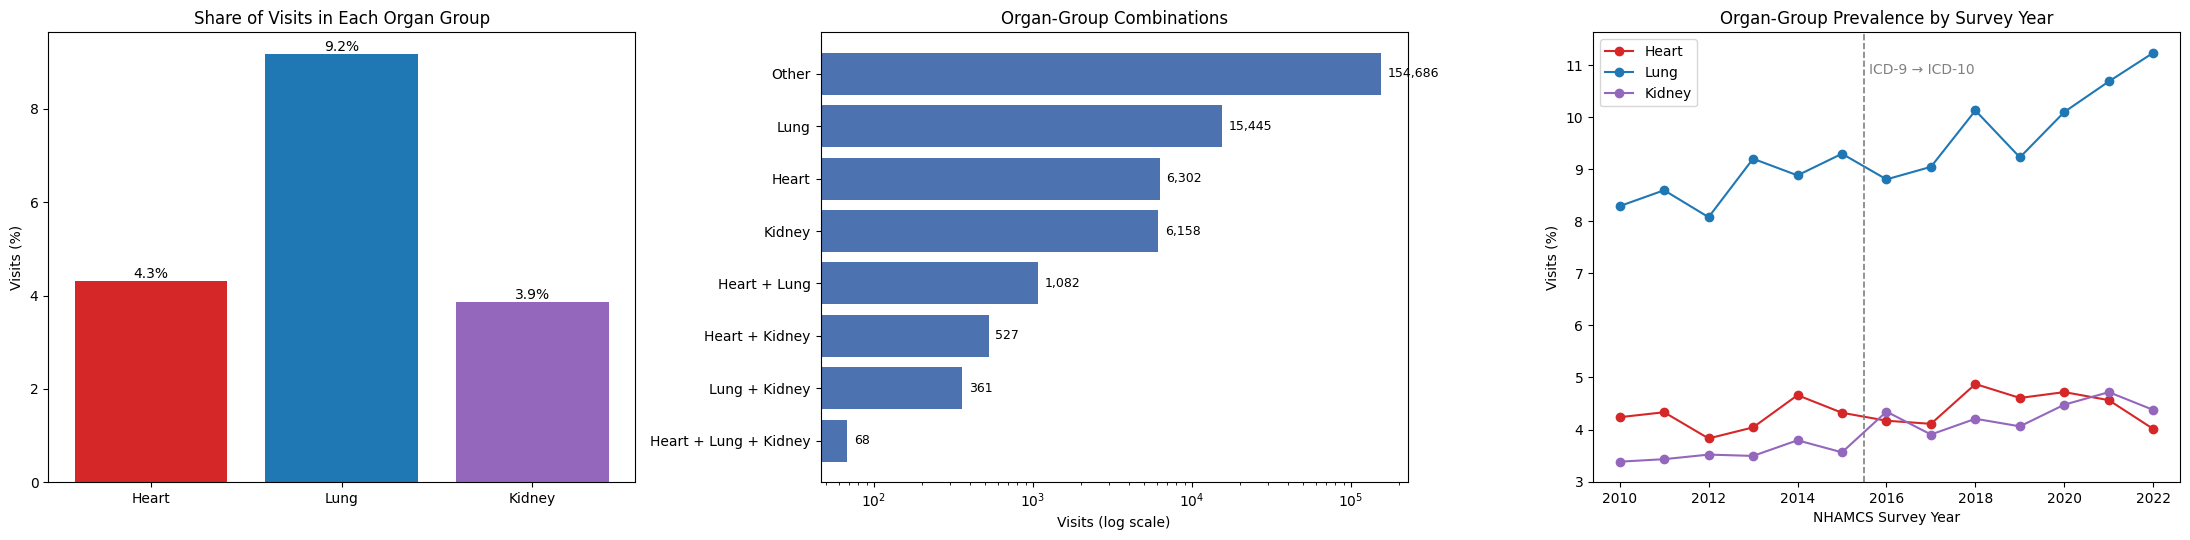


Prevalence by coding era (%):


,heart,lung,kidney
ICD-10 (2016-2022),4.45,9.86,4.29
ICD-9 (2010-2015),4.22,8.67,3.52


In [4]:
ORGANS = ['heart', 'lung', 'kidney']
ORGAN_LABELS = {'heart': 'Heart', 'lung': 'Lung', 'kidney': 'Kidney', 'other': 'Other'}
ORGAN_COLORS = {'heart': '#d62728', 'lung': '#1f77b4', 'kidney': '#9467bd', 'other': '#7f7f7f'}
ROUTES = ORGANS + ['other']

n_groups = triage_data[ORGANS].sum(axis=1)
print("Visits in each organ group (a visit can be in several):")
for organ in ORGANS:
    print(f"  {organ:7s}: {triage_data[organ].sum():7,} ({triage_data[organ].mean():.2%})")
print(f"  other  : {(n_groups == 0).sum():7,} ({(n_groups == 0).mean():.2%})")
print(f"\nVisits in two or more groups: {(n_groups >= 2).sum():,} "
      f"({(n_groups >= 2).sum() / (n_groups >= 1).sum():.1%} of the visits in any group)")

combination = pd.Series(np.where(n_groups == 0, 'Other', ''), index=triage_data.index)
for organ in ORGANS:
    has = triage_data[organ] == 1
    combination[has] = combination[has].where(combination[has] == '', combination[has] + ' + ') + ORGAN_LABELS[organ]
combo_counts = combination.value_counts()
print("\nOrgan-group combinations:")
print(combo_counts.to_string())

fig, axes = plt.subplots(1, 3, figsize=(22, 5.5))

prevalence = triage_data[ORGANS].mean() * 100
axes[0].bar([ORGAN_LABELS[o] for o in ORGANS], prevalence.values, color=[ORGAN_COLORS[o] for o in ORGANS])
axes[0].bar_label(axes[0].containers[0], fmt='%.1f%%')
axes[0].set_ylabel("Visits (%)")
axes[0].set_title("Share of Visits in Each Organ Group")

axes[1].barh(combo_counts.index[::-1], combo_counts.values[::-1], color='#4c72b0')
axes[1].set_xscale('log')
for y_pos, value in enumerate(combo_counts.values[::-1]):
    axes[1].text(value * 1.1, y_pos, f"{value:,}", va='center', fontsize=9)
axes[1].set_xlabel("Visits (log scale)")
axes[1].set_title("Organ-Group Combinations")

# Label-drift check: the diagnosis coding switched from ICD-9 to ICD-10 in 2016
by_year = triage_data.groupby('survey_year')[ORGANS].mean() * 100
for organ in ORGANS:
    axes[2].plot(by_year.index, by_year[organ], marker='o', color=ORGAN_COLORS[organ], label=ORGAN_LABELS[organ])
axes[2].axvline(2015.5, color='gray', linestyle='--', lw=1.2)
axes[2].text(2015.6, axes[2].get_ylim()[1] * 0.95, 'ICD-9 → ICD-10', color='gray', va='top')
axes[2].set_xlabel("NHAMCS Survey Year")
axes[2].set_ylabel("Visits (%)")
axes[2].set_title("Organ-Group Prevalence by Survey Year")
axes[2].legend()

plt.tight_layout()
save_figure("target_distribution.png")
plt.show()

print("\nPrevalence by coding era (%):")
era = np.where(triage_data['survey_year'] >= 2016, 'ICD-10 (2016-2022)', 'ICD-9 (2010-2015)')
display((triage_data.groupby(era)[ORGANS].mean() * 100).round(2))

* **16.2 % of visits are in at least one organ group:** 7,979 heart (4.3 %), 16,956 lung (9.2 %) and 7,114 kidney (3.9 %). The other 154,686 visits (83.8 %) are *other*. A router that sent everyone to "other" would be 84 % accurate and useless, so the heads are judged on PR-AUC and recall, not accuracy.
* **Multi-organ visits are few but real:** 2,038 visits (6.8 % of the organ visits) have diagnoses in two or three groups. The most common pairs are heart + lung (1,082: heart failure with pneumonia or COPD) and heart + kidney (527). This is why the router has three independent heads instead of one four-way classifier.
* **Label drift is modest:** the ICD-10 years have slightly higher prevalence (heart 4.45 vs 4.22 %, lung 9.86 vs 8.67 %, kidney 4.29 vs 3.52 %). Lung climbs from 2020 with COVID-19, and kidney steps up in 2016 with the new renal-colic and kidney-infection codes. The random split puts every year in both the training and the test set.

### Label Audit: What Each Organ Group Contains
`data/diagnosis_groups.csv` lists every diagnosis code that put a visit in an organ group. The most frequent codes show what each head actually learns to recognise.

In [5]:
ICD_TITLES = {
    # heart
    '428.0': 'Congestive heart failure', 'I50.9': 'Heart failure, unspecified', '427.31': 'Atrial fibrillation',
    'I48.9': 'Atrial fibrillation / flutter', 'I48.91': 'Atrial fibrillation', '411.1': 'Unstable angina',
    'I20.0': 'Unstable angina', 'I25.1': 'Coronary atherosclerosis', '414.00': 'Coronary atherosclerosis',
    '414.01': 'Coronary atherosclerosis', '427.89': 'Other arrhythmia (e.g. bradycardia)', 'I49.9': 'Arrhythmia, unspecified',
    '410.71': 'NSTEMI (subendocardial infarction)', 'I21.4': 'NSTEMI', '413.9': 'Angina pectoris', 'I20.9': 'Angina, unspecified',
    '427.0': 'Supraventricular tachycardia', 'I47.1': 'Supraventricular tachycardia', 'I11.0': 'Hypertensive heart disease with heart failure',
    '402.91': 'Hypertensive heart disease with heart failure', '427.9': 'Arrhythmia, unspecified', 'I50.3': 'Diastolic heart failure',
    'I50.2': 'Systolic heart failure', 'I21.9': 'Myocardial infarction, unspecified', 'I48.0': 'Paroxysmal atrial fibrillation',
    # lung
    '486': 'Pneumonia, organism unspecified', 'J18.9': 'Pneumonia, unspecified organism', '490': 'Bronchitis, not acute or chronic',
    'J40': 'Bronchitis, not acute or chronic', '466.0': 'Acute bronchitis', 'J20.9': 'Acute bronchitis', '493.90': 'Asthma',
    'J45.9': 'Asthma', '493.92': 'Asthma with exacerbation', 'J45.901': 'Asthma with exacerbation', '491.21': 'COPD with exacerbation',
    'J44.1': 'COPD with exacerbation', '496': 'Chronic airway obstruction (COPD)', 'J44.9': 'COPD, unspecified', 'U07.1': 'COVID-19',
    'J12.8': 'Other viral pneumonia (incl. COVID-19)', '487.1': 'Influenza', 'J11.1': 'Influenza', 'J10.1': 'Influenza',
    '518.81': 'Acute respiratory failure', 'J96.0': 'Acute respiratory failure', 'J96.9': 'Respiratory failure, unspecified',
    '511.9': 'Pleural effusion', 'J90': 'Pleural effusion', 'J44.0': 'COPD with acute lower respiratory infection', 'J18.1': 'Lobar pneumonia',
    # kidney
    '592.0': 'Kidney stone', 'N20.0': 'Kidney stone', '592.1': 'Ureter stone', 'N20.1': 'Ureter stone', '788.0': 'Renal colic',
    'N23': 'Renal colic', '590.80': 'Pyelonephritis', '590.10': 'Acute pyelonephritis', 'N10': 'Acute pyelonephritis',
    '584.9': 'Acute kidney failure', 'N17.9': 'Acute kidney failure', '593.9': 'Kidney / ureter disorder, unspecified',
    'N28.9': 'Kidney disorder, unspecified', '585.6': 'End-stage renal disease', 'N18.6': 'End-stage renal disease',
    '585.9': 'Chronic kidney disease, unspecified', 'N18.9': 'Chronic kidney disease, unspecified', 'N15.9': 'Tubulo-interstitial disease (pyelonephritis NOS)',
    'N13.3': 'Hydronephrosis', 'N13.9': 'Obstructive uropathy', '591': 'Hydronephrosis', 'I12.9': 'Hypertensive chronic kidney disease',
    '403.91': 'Hypertensive chronic kidney disease', 'E11.2': 'Type 2 diabetes with kidney complications', 'Z99.2': 'Dependence on dialysis',
    'V45.11': 'Renal dialysis status', 'N18.3': 'Chronic kidney disease, stage 3', 'N18.4': 'Chronic kidney disease, stage 4',
}

for organ in ORGANS:
    codes = diagnosis_groups[diagnosis_groups['organ'] == organ]
    top = codes.head(12).copy()
    top['title'] = top['code'].map(ICD_TITLES).fillna('')
    top['share of the group (%)'] = (top['visits'] / triage_data[organ].sum() * 100).round(1)
    print(f"--- {ORGAN_LABELS[organ]}: {len(codes)} distinct codes; the 12 most frequent ---")
    display(top[['icd_version', 'code', 'title', 'visits', 'share of the group (%)']].set_index('code'))

first_listed = triage_data['primary_organ'].value_counts()
print("Primary organ (the first organ diagnosis listed) — visits:")
print(first_listed.reindex(ROUTES).to_string())

--- Heart: 210 distinct codes; the 12 most frequent ---


,icd_version,title,visits,share of the group (%)
code,,,,
428.0,9,Congestive heart failure,1133,14.2
427.31,9,Atrial fibrillation,841,10.5
I50.9,10,"Heart failure, unspecified",786,9.9
I48.9,10,Atrial fibrillation / flutter,651,8.2
411.1,9,Unstable angina,437,5.5
I25.1,10,Coronary atherosclerosis,373,4.7
427.89,9,Other arrhythmia (e.g. bradycardia),355,4.4
414.00,9,Coronary atherosclerosis,294,3.7
I21.4,10,NSTEMI,229,2.9


--- Lung: 188 distinct codes; the 12 most frequent ---


,icd_version,title,visits,share of the group (%)
code,,,,
486,9,"Pneumonia, organism unspecified",1787,10.5
490,9,"Bronchitis, not acute or chronic",1300,7.7
U07.1,10,COVID-19,1247,7.4
466.0,9,Acute bronchitis,1217,7.2
493.90,9,Asthma,1187,7.0
J45.9,10,Asthma,1180,7.0
J18.9,10,"Pneumonia, unspecified organism",1140,6.7
491.21,9,COPD with exacerbation,763,4.5
J44.1,10,COPD with exacerbation,739,4.4


--- Kidney: 123 distinct codes; the 12 most frequent ---


,icd_version,title,visits,share of the group (%)
code,,,,
592.0,9,Kidney stone,823,11.6
N17.9,10,Acute kidney failure,738,10.4
N20.0,10,Kidney stone,612,8.6
592.1,9,Ureter stone,485,6.8
788.0,9,Renal colic,430,6.0
590.80,9,Pyelonephritis,396,5.6
584.9,9,Acute kidney failure,365,5.1
593.9,9,"Kidney / ureter disorder, unspecified",319,4.5
N20.1,10,Ureter stone,314,4.4


Primary organ (the first organ diagnosis listed) — visits:
primary_organ
heart       7212
lung       16314
kidney      6417
other     154686


* **Heart is mostly heart failure and atrial fibrillation:** congestive heart failure (428.0 / I50.9) is 24 % of the group and atrial fibrillation (427.31 / I48.9) 19 %. Unstable angina, coronary atherosclerosis and myocardial infarction (410.91 is an acute MI; I21.4 an NSTEMI) follow. These are the conditions the ECG model sees (arrhythmia, infarction) and the heart risk model assesses.
* **Lung is infections and airway disease:** pneumonia (486 / J18.9) is 17 % of the group, bronchitis (490, 466.0, J20.9) 19 %, asthma (493.90, J45.9, 493.92) 18 %, COPD exacerbations (491.21, J44.1, 496) 13 % and COVID-19 (U07.1) 7 %. This matches the chest X-ray model's classes (pneumonia, COVID-19, emphysema, tuberculosis) and the COPD risk model.
* **Kidney is mostly acute:** kidney and ureter stones and renal colic (592.0, 592.1, N20.0, N20.1, 788.0) are 37 % of the group, acute kidney failure (N17.9 / 584.9) 16 % and pyelonephritis 6 %. Chronic kidney disease and end-stage disease (N18.x / 585.x) are at least 11 %. The stones fit the kidney CT model (stone, cyst, tumor); the chronic part is what the CKD risk model predicts.

### Missing Values
The CSV holds only real values or genuine unknowns: blank and "unknown" survey codes, Doppler pulses and palpated diastolic pressures are already `NaN`. `symptom_2` and `symptom_3` are empty when the patient gave fewer symptoms, which is not missing data.

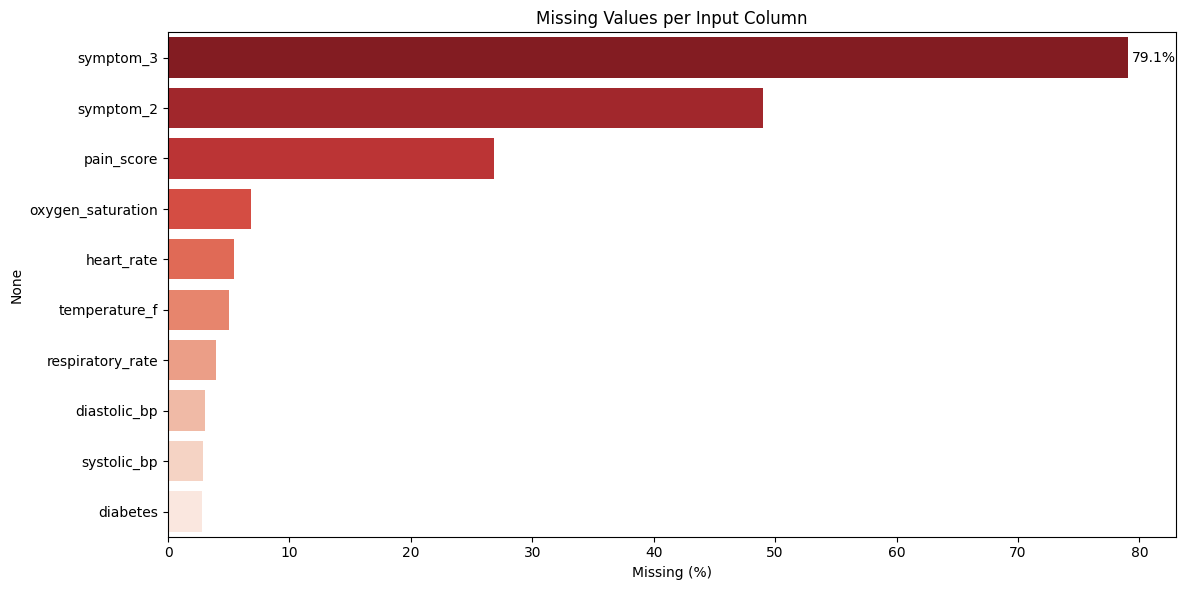

Symptoms given per visit:


1    49.0 %
2    30.0 %
3    20.9 %

Visits with no vital sign at all: 3,758 (2.04%)
Visits without a pain score: 26.8%


In [6]:
INPUT_COLUMNS = ['age', 'sex', 'symptom_1', 'symptom_2', 'symptom_3', 'injury_reason', 'diabetes', 'temperature_f',
                 'heart_rate', 'respiratory_rate', 'systolic_bp', 'diastolic_bp', 'oxygen_saturation', 'pain_score']
VITAL_SIGNS = ['temperature_f', 'heart_rate', 'respiratory_rate', 'systolic_bp', 'diastolic_bp', 'oxygen_saturation', 'pain_score']

missing = (triage_data[INPUT_COLUMNS].isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=missing.values, y=missing.index, palette="Reds_r")
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
plt.xlabel("Missing (%)")
plt.title("Missing Values per Input Column")
plt.tight_layout()
save_figure("missing_values.png")
plt.show()

symptom_counts = triage_data[['symptom_1', 'symptom_2', 'symptom_3']].notna().sum(axis=1)
print("Symptoms given per visit:")
print((symptom_counts.value_counts(normalize=True).sort_index() * 100).round(1).astype(str).add(' %').to_string())
no_vitals = triage_data[VITAL_SIGNS[:-1]].isna().all(axis=1)
print(f"\nVisits with no vital sign at all: {no_vitals.sum():,} ({no_vitals.mean():.2%})")
print(f"Visits without a pain score: {triage_data['pain_score'].isna().mean():.1%}")

* **Half the patients give one symptom:** 49.0 % give one, 30.0 % two and 20.9 % three. An empty `symptom_2` or `symptom_3` is by design, not missing data.
* **Vital signs are nearly complete in the ED.** Temperature, heart rate, breathing rate and blood pressure are missing in 3–5 % of visits, and oxygen saturation in 6.8 % (including the impossible readings removed at build time). Only 2.0 % of visits have no vital sign at all. The pain score is the exception (26.8 % missing).
* **This is the opposite of the router's real use:** a patient at home usually has no measurement at all, which is why the vital-sign dropout below matters more than the imputation method.

### Symptoms
How often each symptom is given, and how often a visit with that symptom ends in a heart, lung or kidney diagnosis. The heat map shows the 30 most frequent symptoms; the lists below it show, for each organ, the symptoms (given in at least 300 visits) with the highest rate of that organ's diagnoses.

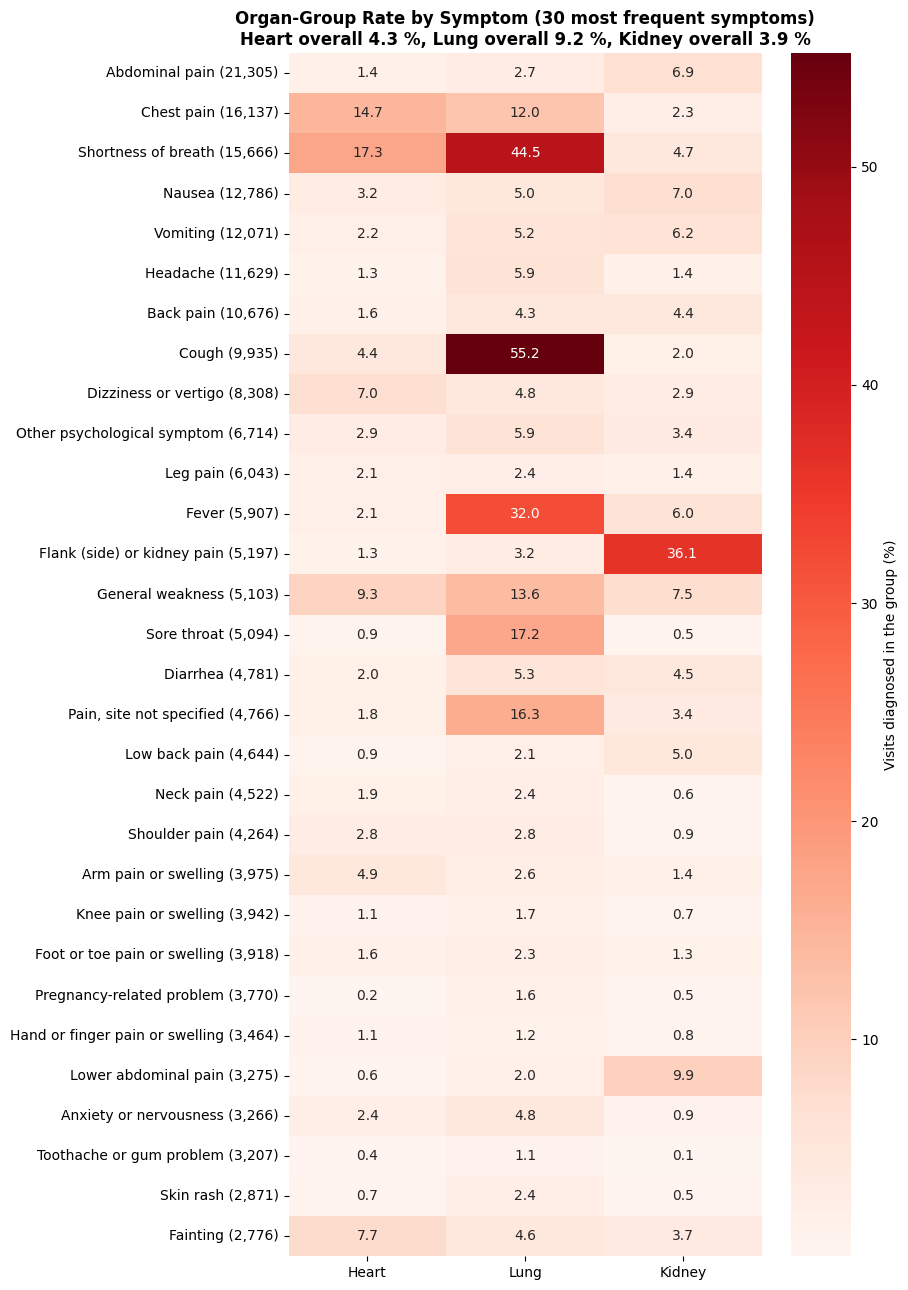


Heart (overall 4.3 %) — highest-rate symptoms:
  Irregular heartbeat                         40.2 %  ( 9.3x, 752 visits)
  Fast heartbeat                              38.0 %  ( 8.8x, 713 visits)
  Palpitations                                30.2 %  ( 7.0x, 1,535 visits)
  Other circulation and lymph symptom         22.2 %  ( 5.1x, 589 visits)
  Chest pressure or tightness                 18.2 %  ( 4.2x, 2,100 visits)
  Shortness of breath                         17.3 %  ( 4.0x, 15,666 visits)
  Excessive sweating                          14.8 %  ( 3.4x, 560 visits)
  Chest pain                                  14.7 %  ( 3.4x, 16,137 visits)

Lung (overall 9.2 %) — highest-rate symptoms:
  Wheezing                                    83.9 %  ( 9.1x, 1,039 visits)
  Coughing up phlegm                          64.6 %  ( 7.0x, 794 visits)
  Chest congestion                            59.8 %  ( 6.5x, 445 visits)
  Cough                                       55.2 %  ( 6.0x, 9,935 visits)
  F

In [7]:
SYMPTOM_COLUMNS = ['symptom_1', 'symptom_2', 'symptom_3']
long = triage_data[SYMPTOM_COLUMNS + ORGANS].melt(id_vars=ORGANS, value_name='symptom').dropna(subset=['symptom'])
symptom_visits = long['symptom'].value_counts()
organ_rates = long.groupby('symptom')[ORGANS].mean() * 100
base_rates = triage_data[ORGANS].mean() * 100

top30 = symptom_visits.head(30).index
heat = organ_rates.loc[top30].rename(columns=ORGAN_LABELS)
heat.index = [f"{s} ({symptom_visits[s]:,})" for s in top30]

fig, ax = plt.subplots(figsize=(9, 13))
sns.heatmap(heat, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': 'Visits diagnosed in the group (%)'}, ax=ax)
ax.set_title("Organ-Group Rate by Symptom (30 most frequent symptoms)\n"
             + ", ".join(f"{ORGAN_LABELS[o]} overall {base_rates[o]:.1f} %" for o in ORGANS), fontweight='bold')
ax.set_xlabel("")
plt.tight_layout()
save_figure("symptom_organ_heatmap.png")
plt.show()

frequent = symptom_visits[symptom_visits >= 300].index
for organ in ORGANS:
    ranked = organ_rates.loc[frequent, organ].sort_values(ascending=False).head(8)
    print(f"\n{ORGAN_LABELS[organ]} (overall {base_rates[organ]:.1f} %) — highest-rate symptoms:")
    for symptom, rate in ranked.items():
        print(f"  {symptom:42s} {rate:5.1f} %  ({rate / base_rates[organ]:4.1f}x, {symptom_visits[symptom]:,} visits)")

* **A few symptoms are strongly organ-specific:**
    * Lung: wheezing ends in a lung diagnosis in 83.9 % of visits (9.1× the base rate), coughing up phlegm in 64.6 % and cough in 55.2 %.
    * Heart: an irregular or fast heartbeat ends in a heart diagnosis in 40.2 % and 38.0 % (9.3× and 8.8×).
    * Kidney: flank or kidney pain ends in a kidney diagnosis in 36.1 % (9.4×), blood in the urine in 19.2 %.
* **The most common complaints are ambiguous.** Chest pain (16,137 visits) leads to a heart diagnosis in 14.7 % and a lung diagnosis in 12.0 %; shortness of breath (15,666) to 17.3 % heart and 44.5 % lung. Abdominal pain, the most frequent symptom (21,305 visits), rarely points to any of the three organs (kidney 6.9 %).
* **Heart disease has no strong complaint besides palpitations.** Chest pressure or tightness reaches 18.2 % and chest pain 14.7 %. Most emergency chest pain turns out not to be heart disease once worked up, and the labels reflect that.

### Age, Sex and Vital Signs by Organ Group
Grouped by the primary organ (the first organ diagnosis listed). Outliers are hidden to keep the boxes readable.

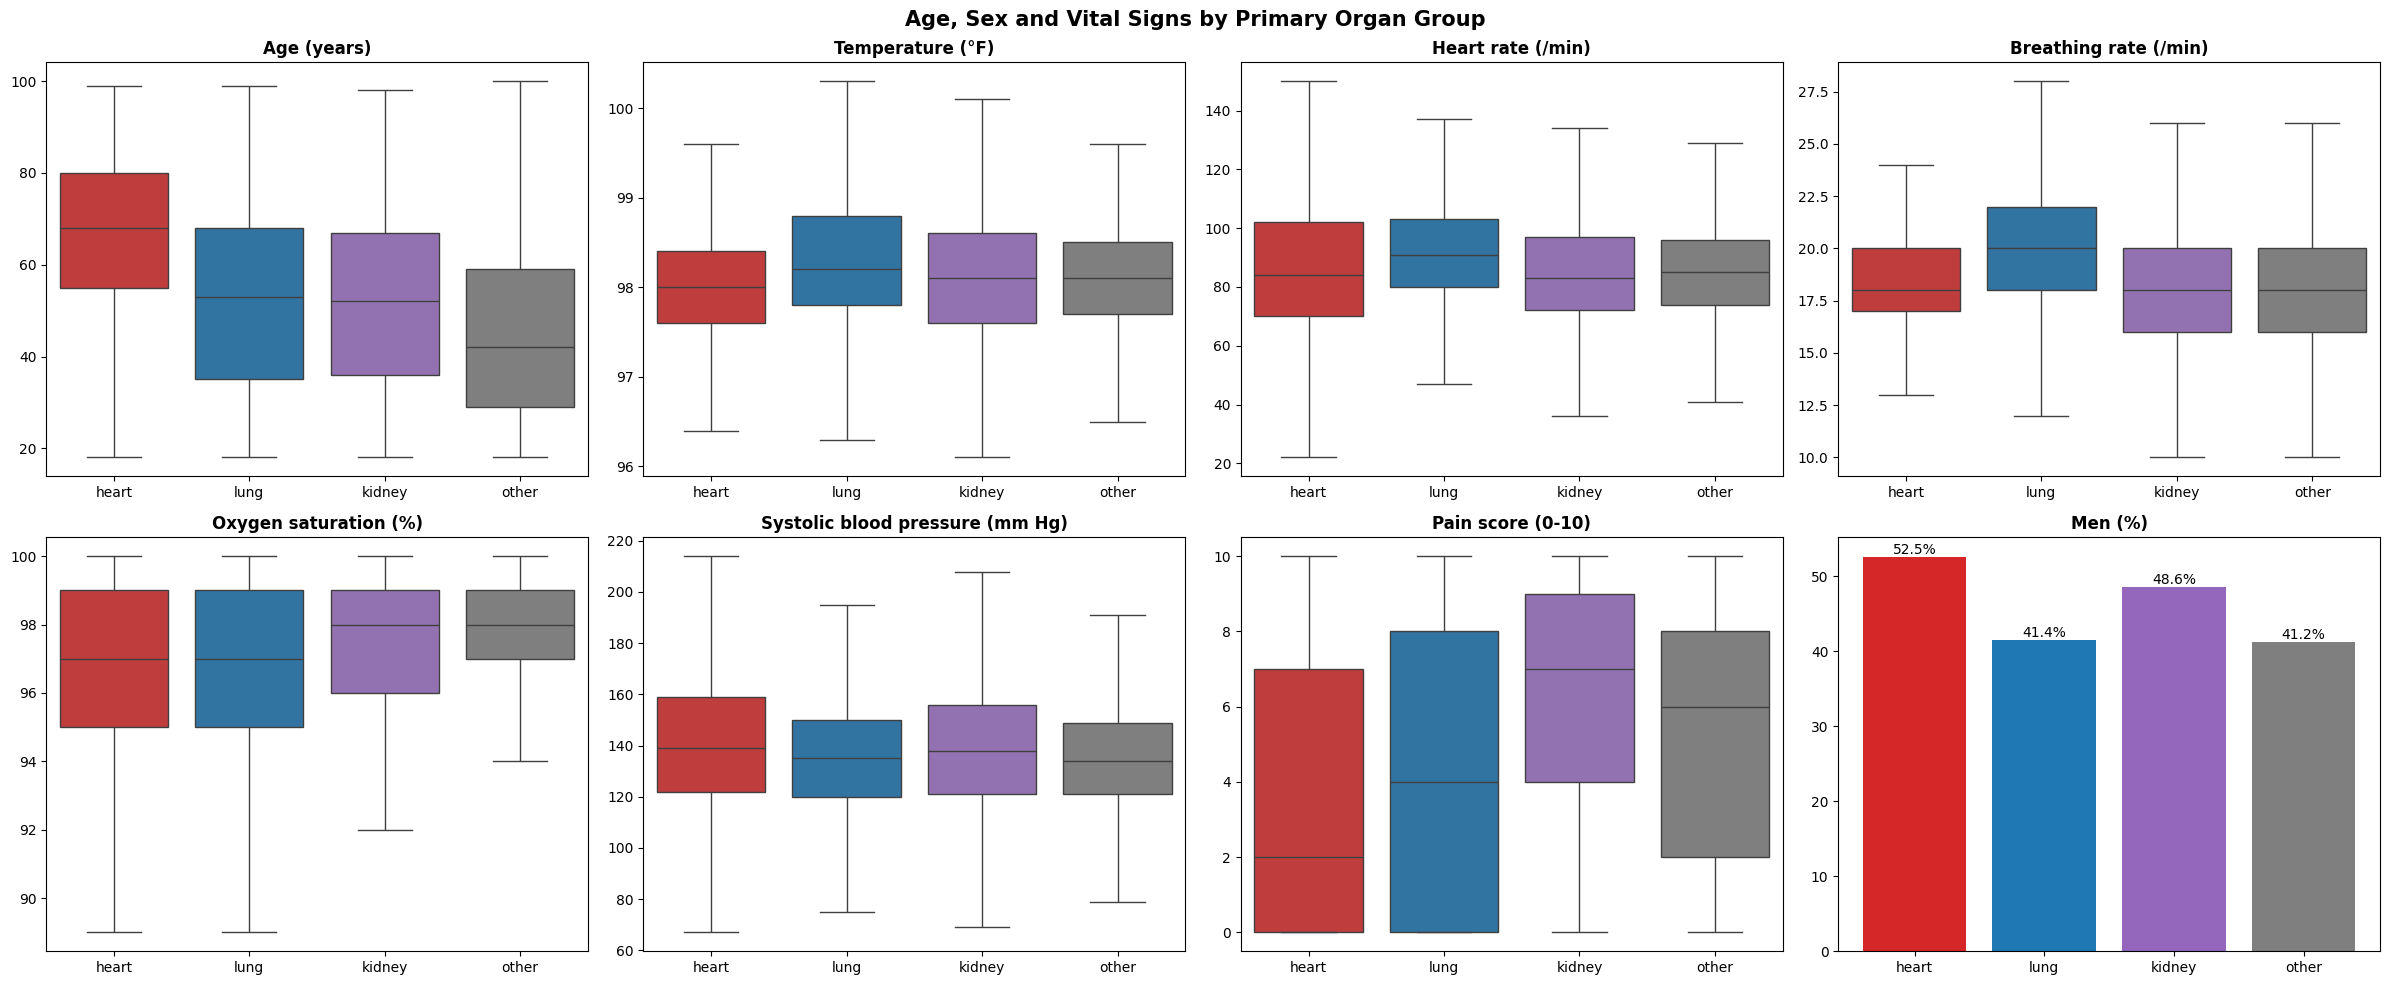

Medians by primary organ group:


,age,temperature_f,heart_rate,respiratory_rate,oxygen_saturation,systolic_bp,pain_score
primary_organ,,,,,,,
heart,68.0,98.0,84.0,18.0,97.0,139.0,2.0
lung,53.0,98.2,91.0,20.0,97.0,135.0,4.0
kidney,52.0,98.1,83.0,18.0,98.0,138.0,7.0
other,42.0,98.1,85.0,18.0,98.0,134.0,6.0


Diabetes (%): {'heart': 28.9, 'lung': 16.3, 'kidney': 23.1, 'other': 12.3}


In [8]:
panels = ['age', 'temperature_f', 'heart_rate', 'respiratory_rate', 'oxygen_saturation', 'systolic_bp', 'pain_score']
titles = ['Age (years)', 'Temperature (°F)', 'Heart rate (/min)', 'Breathing rate (/min)', 'Oxygen saturation (%)',
          'Systolic blood pressure (mm Hg)', 'Pain score (0-10)']

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
for ax, column, title in zip(axes.flat, panels, titles):
    sns.boxplot(data=triage_data, x='primary_organ', y=column, order=ROUTES, palette=ORGAN_COLORS, showfliers=False, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
male_share = (triage_data['sex'] == 'Male').groupby(triage_data['primary_organ']).mean().reindex(ROUTES) * 100
axes.flat[-1].bar(ROUTES, male_share.values, color=[ORGAN_COLORS[r] for r in ROUTES])
axes.flat[-1].bar_label(axes.flat[-1].containers[0], fmt='%.1f%%')
axes.flat[-1].set_title('Men (%)', fontweight='bold')
plt.suptitle('Age, Sex and Vital Signs by Primary Organ Group', fontsize=15, fontweight='bold')
plt.tight_layout()
save_figure("vitals_by_organ.png")
plt.show()

print("Medians by primary organ group:")
display(triage_data.groupby('primary_organ')[panels].median().reindex(ROUTES).round(1))
print("Diabetes (%):", (triage_data['diabetes'] == 'Yes').groupby(triage_data['primary_organ']).mean().reindex(ROUTES).mul(100).round(1).to_dict())

* **Heart patients are the oldest (median 68) and report the least pain (median 2 of 10)**, against 42 and 6 for other visits. 52.5 % are men, against 41.2 % of other visits. Diabetes is more than twice as common in heart (28.9 %) and nearly twice as common in kidney (23.1 %) visits as in other visits (12.3 %).
* **Lung patients have faster breathing and pulses** (medians 20 and 91 /min against 18 and 85) and slightly lower oxygen saturation (97 vs 98 %).
* **Kidney patients report the most pain (median 7):** stones and renal colic dominate the group.
* The medians differ by small amounts; the tails carry the signal. Fever, low oxygen and fast breathing are 4–5× more common in lung visits than in other visits (see the feature-engineering table below).

### Correlation Analysis

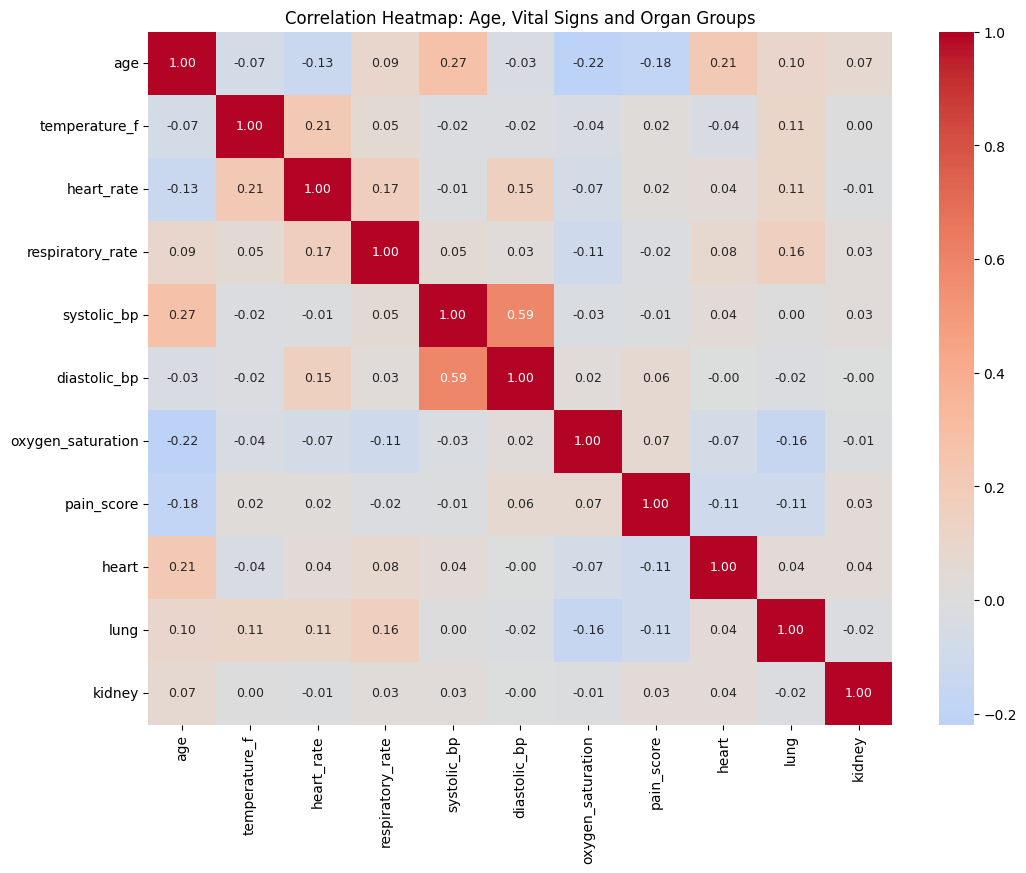

In [9]:
# Survey metadata and diagnosis codes describe the survey and the outcome, not the patient's inputs
numeric_view = triage_data[['age'] + VITAL_SIGNS + ORGANS]

plt.figure(figsize=(12, 9))
sns.heatmap(numeric_view.corr(), annot=True, cmap="coolwarm", fmt=".2f", annot_kws={'size': 9}, center=0)
plt.title("Correlation Heatmap: Age, Vital Signs and Organ Groups")
save_figure("correlation_heatmap.png")
plt.show()

In [10]:
threshold = 0.85

# The targets are excluded: a feature that tracks a label is signal, not redundancy
corr_matrix = triage_data[['age'] + VITAL_SIGNS].corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
flagged = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]

print(f"Inputs correlated above {threshold}: {flagged if flagged else 'none'}")
strongest = upper_triangle.stack().dropna().sort_values(ascending=False).head(3)
for (a, b), r in strongest.items():
    print(f"  {a} ~ {b}: r = {r:.3f}")

Inputs correlated above 0.85: none
  systolic_bp ~ diastolic_bp: r = 0.590
  age ~ systolic_bp: r = 0.270
  age ~ oxygen_saturation: r = 0.219


* **No input pair is redundant:** the strongest correlation is systolic with diastolic pressure (r = 0.59), so nothing is dropped.
* **Single inputs are weak predictors on their own.** Age correlates best with the heart label (r = 0.21), and breathing rate (0.16) and oxygen saturation (−0.16) with the lung label. Nothing correlates with the kidney label above 0.07. The heads rely on symptoms and their combinations, not on one measurement.

# Dataset Pre-processing

### Feature Engineering
The three symptom columns become one 0/1 column per symptom name (128 columns). The encoding ignores order, so "cough, fever" and "fever, cough" are the same visit, and a symptom given second counts as much as one given first. Seven more features come from the vital signs. The function is row-wise and stateless (it learns nothing from the data), so it is safe to run on any split. Inside the model it runs as the first pipeline step.

| Feature | Formula | Why |
|---|---|---|
| `symptom_<name>` × 128 | 1 if the patient gave that symptom | The patient's own complaint, the main input of a router. |
| `symptom_count` | number of symptoms given (1–3) | More complaints go with sicker, more complex visits. |
| `pulse_pressure` | systolic − diastolic BP | Wide in stiff arteries and some heart conditions. |
| `shock_index` | heart rate ÷ systolic BP | A standard triage marker of circulatory strain; above ~0.9 is abnormal. |
| `fever` | temperature ≥ 100.4 °F | The usual clinical cut-off, easy for a linear model to use. |
| `low_oxygen` | oxygen saturation < 94 % | Hypoxaemia points to the lungs (or the heart). |
| `fast_heart_rate` | heart rate > 100 /min | Tachycardia: arrhythmia, fever, dehydration, heart failure. |
| `fast_breathing` | breathing rate > 20 /min | Tachypnoea: lung disease or heart failure. |

The four flags are unknown (and later imputed) when their vital sign is unknown.

In [11]:
SYMPTOMS = vocabulary['symptom'].tolist()

def symptom_feature(name):
    # 'Flank (side) or kidney pain' -> 'symptom_flank_side_or_kidney_pain' (a safe column name for every model)
    return "symptom_" + re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")

SYMPTOM_FEATURES = [symptom_feature(s) for s in SYMPTOMS]
SYMPTOM_LABELS = dict(zip(SYMPTOM_FEATURES, SYMPTOMS))
assert len(set(SYMPTOM_FEATURES)) == len(SYMPTOMS), "two symptom names map to the same column"

def add_custom_features(X_df):
    X_new = X_df.copy()
    listed = X_new[SYMPTOM_COLUMNS]

    # One 0/1 column per symptom name; names outside the vocabulary get no column
    codes = pd.Categorical(listed.to_numpy(dtype=object).ravel(), categories=SYMPTOMS).codes.reshape(listed.shape)
    multi_hot = np.zeros((len(listed), len(SYMPTOMS)))
    rows, slots = np.nonzero(codes >= 0)
    multi_hot[rows, codes[rows, slots]] = 1.0

    temperature, heart_rate = X_new['temperature_f'], X_new['heart_rate']
    breathing, oxygen = X_new['respiratory_rate'], X_new['oxygen_saturation']
    engineered = pd.DataFrame({
        'symptom_count': (codes >= 0).sum(axis=1).astype(float),
        # Pulse pressure and the shock index; systolic floored at 40 mm Hg so the ratio stays finite
        'pulse_pressure': X_new['systolic_bp'] - X_new['diastolic_bp'],
        'shock_index': heart_rate / X_new['systolic_bp'].clip(lower=40),
        # Standard triage cut-offs; unknown when the vital sign is unknown
        'fever': (temperature >= 100.4).astype(float).where(temperature.notna()),
        'low_oxygen': (oxygen < 94).astype(float).where(oxygen.notna()),
        'fast_heart_rate': (heart_rate > 100).astype(float).where(heart_rate.notna()),
        'fast_breathing': (breathing > 20).astype(float).where(breathing.notna()),
    }, index=X_new.index)
    symptoms = pd.DataFrame(multi_hot, columns=SYMPTOM_FEATURES, index=X_new.index)
    return pd.concat([X_new, engineered, symptoms], axis=1)

feature_engineering = FunctionTransformer(add_custom_features)

# Sanity check on the full table (the pipeline recomputes this inside every CV fold)
engineered_preview = add_custom_features(triage_data[INPUT_COLUMNS])
engineered_cols = ['symptom_count', 'pulse_pressure', 'shock_index', 'fever', 'low_oxygen', 'fast_heart_rate', 'fast_breathing']
print(f"Engineered matrix: {engineered_preview.shape[1] - len(INPUT_COLUMNS)} new columns "
      f"({len(SYMPTOM_FEATURES)} symptoms + {len(engineered_cols)} vital-sign features)")
print("Mean of each engineered feature by primary organ group (flags as rates):")
display(engineered_preview[engineered_cols].groupby(triage_data['primary_organ']).mean().reindex(ROUTES).round(3))

Engineered matrix: 135 new columns (128 symptoms + 7 vital-sign features)
Mean of each engineered feature by primary organ group (flags as rates):


,symptom_count,pulse_pressure,shock_index,fever,low_oxygen,fast_heart_rate,fast_breathing
primary_organ,,,,,,,
heart,1.745,61.471,0.659,0.012,0.128,0.261,0.209
lung,1.948,57.984,0.694,0.078,0.174,0.299,0.265
kidney,1.834,59.869,0.637,0.043,0.058,0.187,0.116
other,1.689,56.584,0.644,0.016,0.039,0.173,0.067


### Preprocessing
The pipeline is simpler than in the organ notebooks, on purpose:

1. **Median imputation, then robust scaling, for numbers; no missing-value indicators.** In the emergency department a missing vital sign is rare and says something about the visit (the patient left early, or was too sick to wait). A patient using the router usually has *no* vital signs, and that must not look like a warning sign. Imputing the typical value scores an unknown measurement as unremarkable. The organ notebooks' KNN imputation is also left out: 147,000 training visits make every neighbour search slow, and the vital-sign dropout below makes most gaps deliberate.
2. **Most-frequent imputation and one-hot encoding** for sex, diabetes and the injury question.
3. **The 128 symptom columns pass through unchanged** (they are already 0/1).
4. **No SMOTE.** Each head has thousands of positive training visits (about 5,700 for the kidney, 6,400 for the heart and 13,600 for the lungs), and the heart, kidney and lung grid searches switched oversampling off for every model anyway. The imbalance is handled by the cost-based threshold.

The train/test split happens before anything is fitted. It is stratified on the combination of the three labels, so rare combinations (heart + kidney) are in both parts. Every fitted step lives inside the pipeline and is re-fitted on each CV training fold only.

In [12]:
ONE_HOT_FEATURES = ['sex', 'injury_reason', 'diabetes']
RAW_NUMERICAL_FEATURES = ['age'] + VITAL_SIGNS
NUMERICAL_FEATURES = RAW_NUMERICAL_FEATURES + engineered_cols
RAW_INPUT_COLUMNS = INPUT_COLUMNS

X = triage_data[RAW_INPUT_COLUMNS]
Y = triage_data[ORGANS].astype(int)

def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('numeric', Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', RobustScaler()),
            ]), NUMERICAL_FEATURES),
            ('categorical', Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
            ]), ONE_HOT_FEATURES),
            ('symptoms', 'passthrough', SYMPTOM_FEATURES),
        ],
        verbose_feature_names_out=False,
    )

def build_pipeline(classifier):
    # feature engineering -> impute + scale / one-hot / symptoms -> classifier (one organ head)
    return Pipeline(steps=[
        ('engineering', clone(feature_engineering)),
        ('preprocess', build_preprocessor()),
        ('classifier', clone(classifier)),
    ])

strata = Y.astype(str).agg(''.join, axis=1)          # e.g. '010' = lung only
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=RANDOM_STATE, stratify=strata)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)  # Cross-Validation

print(f"Numerical features ({len(NUMERICAL_FEATURES)}): {NUMERICAL_FEATURES}")
print(f"One-hot features ({len(ONE_HOT_FEATURES)}): {ONE_HOT_FEATURES}")
print(f"Symptom features: {len(SYMPTOM_FEATURES)}")
print(f"\nX_train shape: {X_train.shape} | X_test shape: {X_test.shape}")
for organ in ORGANS:
    print(f"  {organ:7s} train {Y_train[organ].sum():6,} ({Y_train[organ].mean():.2%}) | test {Y_test[organ].sum():5,} ({Y_test[organ].mean():.2%})")

Numerical features (15): ['age', 'temperature_f', 'heart_rate', 'respiratory_rate', 'systolic_bp', 'diastolic_bp', 'oxygen_saturation', 'pain_score', 'symptom_count', 'pulse_pressure', 'shock_index', 'fever', 'low_oxygen', 'fast_heart_rate', 'fast_breathing']
One-hot features (3): ['sex', 'injury_reason', 'diabetes']
Symptom features: 128

X_train shape: (147703, 14) | X_test shape: (36926, 14)
  heart   train  6,383 (4.32%) | test 1,596 (4.32%)
  lung    train 13,565 (9.18%) | test 3,391 (9.18%)
  kidney  train  5,691 (3.85%) | test 1,423 (3.85%)


### Vital-Sign Dropout
Almost every emergency-department visit has vital signs; a patient describing symptoms at home usually has none. A model trained only on complete records meets those patients with every vital sign imputed as "typical", which it has rarely seen, and it underestimates their risk.

The fix is to train on both situations: in a copy of the **training** set, all vital signs and the pain score are removed from a random half of the visits. The test set is never altered; it is scored twice, as recorded and with every vital sign removed. The check below uses one LightGBM head per organ with fixed settings and compares three ways of training it.

In [13]:
VITAL_DROPOUT = 0.5

def drop_vital_signs(X_df, fraction=VITAL_DROPOUT, random_state=RANDOM_STATE):
    # A copy with every vital sign and the pain score blanked for a random `fraction` of the visits
    X_new = X_df.copy()
    blank = np.random.default_rng(random_state).random(len(X_new)) < fraction
    X_new.loc[blank, VITAL_SIGNS] = np.nan
    return X_new

X_train_aug = drop_vital_signs(X_train)
X_test_no_vitals = X_test.copy()
X_test_no_vitals[VITAL_SIGNS] = np.nan
X_train_no_vitals = X_train.copy()
X_train_no_vitals[VITAL_SIGNS] = np.nan
removed = np.random.default_rng(RANDOM_STATE).random(len(X_train)) < VITAL_DROPOUT     # the same draw as drop_vital_signs
print(f"Training visits with every vital sign removed: {removed.sum():,} of {len(X_train):,} ({removed.mean():.1%}); "
      f"heart rate missing {X_train['heart_rate'].isna().mean():.1%} -> {X_train_aug['heart_rate'].isna().mean():.1%}")

reference_clf = LGBMClassifier(n_estimators=300, learning_rate=0.03, num_leaves=15, min_child_samples=50,
                               random_state=RANDOM_STATE, verbose=-1, n_jobs=max(1, N_JOBS))
training_sets = {'recorded vital signs': X_train, 'no vital signs': X_train_no_vitals, 'vital-sign dropout': X_train_aug}
test_sets = {'with vital signs': X_test, 'without vital signs': X_test_no_vitals}

dropout_rows = []
for organ in ORGANS:
    for trained_on, X_fit in training_sets.items():
        model = build_pipeline(reference_clf).fit(X_fit, Y_train[organ])
        for scored_on, X_score in test_sets.items():
            if trained_on == 'no vital signs' and scored_on == 'with vital signs':
                continue                                   # it never sees vital signs
            p = model.predict_proba(X_score)[:, 1]
            dropout_rows.append({'Head': organ, 'Trained on': trained_on, 'Test inputs': scored_on,
                                 'PR-AUC': average_precision_score(Y_test[organ], p),
                                 'ROC-AUC': roc_auc_score(Y_test[organ], p),
                                 'Brier': brier_score_loss(Y_test[organ], p),
                                 'Mean predicted (%)': p.mean() * 100, 'Prevalence (%)': Y_test[organ].mean() * 100})
df_dropout = pd.DataFrame(dropout_rows).set_index(['Head', 'Test inputs', 'Trained on']).sort_index()
display(df_dropout.style.format('{:.4f}').format({'Mean predicted (%)': '{:.2f}', 'Prevalence (%)': '{:.2f}'}))

Training visits with every vital sign removed: 73,724 of 147,703 (49.9%); heart rate missing 5.4% -> 52.7%


* **A model trained on complete ED records underestimates patients without vital signs.** Scored without them, its mean predicted probability falls below the true rate:
    * heart: 10 % below (3.90 vs 4.32 %)
    * lung: 13 % below (8.00 vs 9.18 %)
    * kidney: 24 % below (2.92 vs 3.85 %)

  Its PR-AUC also drops below that of a model that never saw vital signs.
* **Vital-sign dropout gives one model for both situations.**
    * With vital signs it matches the model trained on recorded vital signs (PR-AUC 0.346 vs 0.354 heart, 0.585 vs 0.583 lung, 0.295 vs 0.291 kidney).
    * Without them it is within 0.004 of the symptoms-only model (0.309 vs 0.313, 0.550 vs 0.552, 0.271 vs 0.274).
    * It stays calibrated both ways: its mean prediction is within 0.15 percentage points of the prevalence.
* **Vital signs are worth about 0.02–0.04 PR-AUC** (heart 0.354 vs 0.313, lung 0.583 vs 0.552, kidney 0.291 vs 0.274). That is useful when a patient has a thermometer or a pulse oximeter, but the symptoms carry most of the signal. Every model below is tuned on the dropout training set.

# Model Training

### Model Training Setup
**Tuning metric: PR-AUC (average precision), per head.** At 4–9 % prevalence, accuracy and recall at 0.5 say little; PR-AUC measures how well a head ranks that organ's patients above everyone else across *all* thresholds. A random head scores its prevalence (0.043 heart, 0.092 lung, 0.039 kidney).

**The same nine candidates are tuned for each head** on 5-fold cross-validation of the training set (with vital-sign dropout). The organ notebooks' KNN and SVM are left out: both compare every visit with every training visit, which takes hours at 147,000 visits. Their GPU models (TabNet, FT-Transformer, RealMLP, TabM, TabPFN) and the stacking ensemble are left out as well, because every model here is trained three times. The test set is only used for reporting.

Each tuned model is cached in `notebooks/cv_cache/`, so an interrupted run resumes where it stopped. Delete the folder after changing the data or the features.

In [14]:
fitted_models = {organ: {} for organ in ORGANS}    # head -> model name -> best pipeline, refit on the full training set
cv_summary = {organ: {} for organ in ORGANS}       # head -> model name -> cross-validated PR-AUC of the chosen settings

def cache_path(organ, name):
    return os.path.join(cache_dir, f"{organ}__{re.sub(r'[^a-z0-9]+', '_', name.lower())}.joblib")

def run_grid_search(name, estimator, param_grid, n_jobs=N_JOBS):
    # Tune one model per head on 5-fold CV PR-AUC (training data only), then report once on the untouched test set
    for organ in ORGANS:
        path = cache_path(organ, name)
        if os.path.exists(path):
            best, summary = joblib.load(path)
            timing = 'cached'
        else:
            start = time.time()
            grid = GridSearchCV(build_pipeline(estimator), param_grid, cv=cv_strategy, scoring='average_precision', n_jobs=n_jobs)
            grid.fit(X_train_aug, Y_train[organ])
            failed = int(np.isnan(grid.cv_results_['mean_test_score']).sum())
            if failed:
                print(f"⚠️ {failed} of {len(grid.cv_results_['params'])} settings failed to fit and were skipped")
            folds = np.array([grid.cv_results_[f'split{k}_test_score'][grid.best_index_] for k in range(cv_strategy.get_n_splits())])
            summary = {'CV PR-AUC': folds.mean(), 'CV SE': folds.std(ddof=1) / np.sqrt(len(folds)),
                       'Best Params': {k.replace('classifier__', ''): v for k, v in grid.best_params_.items()},
                       'Tuning Time (min)': (time.time() - start) / 60}
            best = grid.best_estimator_
            joblib.dump((best, summary), path)
            timing = f"{summary['Tuning Time (min)']:.1f} min"

        fitted_models[organ][name], cv_summary[organ][name] = best, summary
        scores = best.predict_proba(X_test)[:, 1]
        print(f"{name} [{organ:6s}] CV PR-AUC {summary['CV PR-AUC']:.4f} (± {summary['CV SE']:.4f} SE) | "
              f"test PR-AUC {average_precision_score(Y_test[organ], scores):.4f}, ROC-AUC {roc_auc_score(Y_test[organ], scores):.4f} | "
              f"{timing} | {summary['Best Params']}")

### Logistic Regression

In [15]:
lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1.0],          # Regularization strength (smaller = stronger penalty)
    'classifier__l1_ratio': [0.0, 1.0]          # 0 = L2 (ridge), 1 = L1 (lasso)
}
run_grid_search('Logistic Regression', LogisticRegression(solver='liblinear', max_iter=2000, random_state=RANDOM_STATE), lr_param_grid)

Logistic Regression [heart ] CV PR-AUC 0.3107 (± 0.0027 SE) | test PR-AUC 0.3066, ROC-AUC 0.8867 | cached | {'C': 1.0, 'l1_ratio': 1.0}
Logistic Regression [lung  ] CV PR-AUC 0.5396 (± 0.0066 SE) | test PR-AUC 0.5495, ROC-AUC 0.8781 | cached | {'C': 1.0, 'l1_ratio': 1.0}
Logistic Regression [kidney] CV PR-AUC 0.2327 (± 0.0060 SE) | test PR-AUC 0.2300, ROC-AUC 0.8379 | cached | {'C': 1.0, 'l1_ratio': 0.0}


### Naive Bayes

In [16]:
nb_param_grid = {'classifier__var_smoothing': np.logspace(0, -9, num=10)}   # Adds a tiny variance to avoid zero probabilities
run_grid_search('Naive Bayes', GaussianNB(), nb_param_grid)

Naive Bayes [heart ] CV PR-AUC 0.1895 (± 0.0031 SE) | test PR-AUC 0.1905, ROC-AUC 0.8525 | cached | {'var_smoothing': np.float64(0.0001)}
Naive Bayes [lung  ] CV PR-AUC 0.3997 (± 0.0049 SE) | test PR-AUC 0.3929, ROC-AUC 0.8577 | cached | {'var_smoothing': np.float64(0.0001)}


Naive Bayes [kidney] CV PR-AUC 0.1583 (± 0.0033 SE) | test PR-AUC 0.1484, ROC-AUC 0.8165 | cached | {'var_smoothing': np.float64(0.0001)}


### Decision Tree

In [17]:
dt_param_grid = {'classifier__max_depth': [6, 10, 16], 'classifier__min_samples_leaf': [20, 100]}
run_grid_search('Decision Tree', DecisionTreeClassifier(random_state=RANDOM_STATE), dt_param_grid)

Decision Tree [heart ] CV PR-AUC 0.2737 (± 0.0016 SE) | test PR-AUC 0.2708, ROC-AUC 0.8745 | cached | {'max_depth': 16, 'min_samples_leaf': 100}
Decision Tree [lung  ] CV PR-AUC 0.5267 (± 0.0047 SE) | test PR-AUC 0.5445, ROC-AUC 0.8717 | cached | {'max_depth': 16, 'min_samples_leaf': 100}


Decision Tree [kidney] CV PR-AUC 0.2219 (± 0.0043 SE) | test PR-AUC 0.2276, ROC-AUC 0.7771 | cached | {'max_depth': 10, 'min_samples_leaf': 20}


### Random Forest

In [18]:
# 200 trees with leaves of at least 50 visits keep each forest under ~100 MB
rf_param_grid = {'classifier__min_samples_leaf': [50, 100]}
run_grid_search('Random Forest', RandomForestClassifier(n_estimators=200, max_features='sqrt', random_state=RANDOM_STATE, n_jobs=1), rf_param_grid)

Random Forest [heart ] CV PR-AUC 0.3150 (± 0.0039 SE) | test PR-AUC 0.3306, ROC-AUC 0.8899 | cached | {'min_samples_leaf': 50}


Random Forest [lung  ] CV PR-AUC 0.5437 (± 0.0050 SE) | test PR-AUC 0.5624, ROC-AUC 0.8857 | cached | {'min_samples_leaf': 50}


Random Forest [kidney] CV PR-AUC 0.2351 (± 0.0067 SE) | test PR-AUC 0.2554, ROC-AUC 0.8475 | cached | {'min_samples_leaf': 50}


### XGBoost

In [19]:
xgb_param_grid = {
    'classifier__n_estimators': [300, 600],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [4, 6],
    'classifier__subsample': [0.8]
}
run_grid_search('XGBoost', XGBClassifier(tree_method='hist', random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=1), xgb_param_grid)

XGBoost [heart ] CV PR-AUC 0.3445 (± 0.0020 SE) | test PR-AUC 0.3483, ROC-AUC 0.8957 | cached | {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 600, 'subsample': 0.8}


XGBoost [lung  ] CV PR-AUC 0.5606 (± 0.0042 SE) | test PR-AUC 0.5879, ROC-AUC 0.8890 | cached | {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 600, 'subsample': 0.8}


XGBoost [kidney] CV PR-AUC 0.2765 (± 0.0068 SE) | test PR-AUC 0.2955, ROC-AUC 0.8533 | cached | {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}


### LightGBM

In [20]:
lgb_param_grid = {
    'classifier__n_estimators': [300, 600],
    'classifier__learning_rate': [0.03, 0.1],
    'classifier__num_leaves': [15, 31],
    'classifier__min_child_samples': [50]
}
run_grid_search('LightGBM', LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=1), lgb_param_grid)

LightGBM [heart ] CV PR-AUC 0.3406 (± 0.0021 SE) | test PR-AUC 0.3472, ROC-AUC 0.8951 | cached | {'learning_rate': 0.03, 'min_child_samples': 50, 'n_estimators': 600, 'num_leaves': 15}


LightGBM [lung  ] CV PR-AUC 0.5641 (± 0.0050 SE) | test PR-AUC 0.5886, ROC-AUC 0.8899 | cached | {'learning_rate': 0.03, 'min_child_samples': 50, 'n_estimators': 300, 'num_leaves': 31}


LightGBM [kidney] CV PR-AUC 0.2748 (± 0.0056 SE) | test PR-AUC 0.2963, ROC-AUC 0.8559 | cached | {'learning_rate': 0.03, 'min_child_samples': 50, 'n_estimators': 300, 'num_leaves': 31}


### Neural Network (MLP)

In [21]:
mlp_param_grid = {'classifier__hidden_layer_sizes': [(64,), (128, 64)], 'classifier__alpha': [0.0001, 0.001]}
run_grid_search('Neural Network (MLP)', MLPClassifier(max_iter=200, early_stopping=True, random_state=RANDOM_STATE), mlp_param_grid)

Neural Network (MLP) [heart ] CV PR-AUC 0.3253 (± 0.0023 SE) | test PR-AUC 0.2950, ROC-AUC 0.8822 | cached | {'alpha': 0.001, 'hidden_layer_sizes': (128, 64)}


Neural Network (MLP) [lung  ] CV PR-AUC 0.5530 (± 0.0047 SE) | test PR-AUC 0.5637, ROC-AUC 0.8833 | cached | {'alpha': 0.0001, 'hidden_layer_sizes': (64,)}


Neural Network (MLP) [kidney] CV PR-AUC 0.2610 (± 0.0070 SE) | test PR-AUC 0.2622, ROC-AUC 0.8383 | cached | {'alpha': 0.001, 'hidden_layer_sizes': (128, 64)}


# Modern Tabular Models
The two modern CPU models from the organ notebooks. CatBoost is a gradient-boosted tree ensemble with ordered boosting; the Explainable Boosting Machine is a glass-box model (a sum of learned per-feature shape functions plus a few pairwise interactions) that is often as accurate as boosted trees.

In [22]:
# On Colab: !pip install -q catboost interpret-core
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier
keep_workers_light()

### CatBoost

In [23]:
cb_param_grid = {'classifier__iterations': [800], 'classifier__depth': [6], 'classifier__learning_rate': [0.05, 0.1]}
run_grid_search('CatBoost', CatBoostClassifier(random_state=RANDOM_STATE, verbose=0, thread_count=1, allow_writing_files=False), cb_param_grid)

CatBoost [heart ] CV PR-AUC 0.3495 (± 0.0035 SE) | test PR-AUC 0.3491, ROC-AUC 0.8959 | cached | {'depth': 6, 'iterations': 800, 'learning_rate': 0.05}
CatBoost [lung  ] CV PR-AUC 0.5631 (± 0.0044 SE) | test PR-AUC 0.5865, ROC-AUC 0.8902 | cached | {'depth': 6, 'iterations': 800, 'learning_rate': 0.05}


CatBoost [kidney] CV PR-AUC 0.2736 (± 0.0058 SE) | test PR-AUC 0.2892, ROC-AUC 0.8532 | cached | {'depth': 6, 'iterations': 800, 'learning_rate': 0.05}


### Explainable Boosting Machine (EBM)

In [24]:
# Four outer bags instead of the default 14: each bag already sees ~118,000 visits (same test PR-AUC, 5x faster).
# EBM runs its bags in 4 processes, so the CV folds run one at a time
run_grid_search('Explainable Boosting', ExplainableBoostingClassifier(random_state=RANDOM_STATE, n_jobs=4, outer_bags=4), {}, n_jobs=1)

Explainable Boosting [heart ] CV PR-AUC 0.3423 (± 0.0031 SE) | test PR-AUC 0.3444, ROC-AUC 0.8917 | cached | {}
Explainable Boosting [lung  ] CV PR-AUC 0.5602 (± 0.0050 SE) | test PR-AUC 0.5883, ROC-AUC 0.8895 | cached | {}


Explainable Boosting [kidney] CV PR-AUC 0.2683 (± 0.0053 SE) | test PR-AUC 0.2821, ROC-AUC 0.8536 | cached | {}


# Model Comparison

### Comparison Table & Barchart
**Threshold-free metrics come first.** ROC-AUC and PR-AUC compare how well each model *ranks* visits for one organ. The recall, precision and error counts at 0.5 depend on that cut-off, which is far too high for a 4–9 % prevalence, so they are shown for reference only; the thresholds are set properly later. `CV PR-AUC` is the selection metric (training data only). `Test PR-AUC` is the one-time check on unseen visits (as recorded, with vital signs).

In [25]:
modern_models = {'CatBoost', 'Explainable Boosting'}
test_scores = {organ: {} for organ in ORGANS}
comparison_rows = []

for organ in ORGANS:
    y_true = Y_test[organ]
    for name, model in fitted_models[organ].items():
        scores = model.predict_proba(X_test)[:, 1]
        test_scores[organ][name] = scores
        preds = (scores >= 0.5).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        comparison_rows.append({
            'Head': organ, 'Model': name, 'Family': 'Modern' if name in modern_models else 'Baseline',
            'CV PR-AUC': cv_summary[organ][name]['CV PR-AUC'], 'CV SE': cv_summary[organ][name]['CV SE'],
            'Test PR-AUC': average_precision_score(y_true, scores), 'Test ROC-AUC': roc_auc_score(y_true, scores),
            'Test Brier': brier_score_loss(y_true, scores),
            'Recall @0.5': recall_score(y_true, preds, zero_division=0), 'Precision @0.5': precision_score(y_true, preds, zero_division=0),
            'Missed (FN) @0.5': int(fn), 'False Alarms (FP) @0.5': int(fp),
            'Tuning Time (min)': cv_summary[organ][name]['Tuning Time (min)'],
        })

df_comparison = pd.DataFrame(comparison_rows).set_index(['Head', 'Model'])
df_comparison.to_csv(os.path.join(results_dir, 'model_comparison.csv'))

score_cols = ['CV PR-AUC', 'Test PR-AUC', 'Test ROC-AUC', 'Recall @0.5', 'Precision @0.5']
for organ in ORGANS:
    print(f"========================== {organ.upper()} HEAD (test prevalence {Y_test[organ].mean():.1%}) ==========================")
    display(df_comparison.loc[organ].sort_values('CV PR-AUC', ascending=False).style.background_gradient(
        cmap='Greens', subset=score_cols
    ).background_gradient(
        cmap='Reds', subset=['Missed (FN) @0.5', 'False Alarms (FP) @0.5']
    ).format({**{c: '{:.4f}' for c in score_cols + ['CV SE', 'Test Brier']}, 'Tuning Time (min)': '{:.1f}'}))

========================== HEART HEAD (test prevalence 4.3%) ==========================


,Family,CV PR-AUC,CV SE,Test PR-AUC,Test ROC-AUC,Test Brier,Recall @0.5,Precision @0.5,Missed (FN) @0.5,False Alarms (FP) @0.5,Tuning Time (min)
Model,,,,,,,,,,,
CatBoost,Modern,0.3495,0.0035,0.3491,0.8959,0.0335,0.1159,0.5836,1411,132,1.4
XGBoost,Baseline,0.3445,0.0020,0.3483,0.8957,0.0336,0.1316,0.5785,1386,153,1.3
Explainable Boosting,Modern,0.3423,0.0031,0.3444,0.8917,0.0337,0.1372,0.5778,1377,160,4.7
LightGBM,Baseline,0.3406,0.0021,0.3472,0.8951,0.0335,0.1096,0.6098,1421,112,0.5
Neural Network (MLP),Baseline,0.3253,0.0023,0.2950,0.8822,0.0350,0.0589,0.5595,1502,74,0.8
Random Forest,Baseline,0.3150,0.0039,0.3306,0.8899,0.0353,0.0000,0.0000,1596,0,1.8
Logistic Regression,Baseline,0.3107,0.0027,0.3066,0.8867,0.0346,0.0990,0.4984,1438,159,1.2
Decision Tree,Baseline,0.2737,0.0016,0.2708,0.8745,0.0354,0.0871,0.4649,1457,160,0.3
Naive Bayes,Baseline,0.1895,0.0031,0.1905,0.8525,0.2538,0.8578,0.1168,227,10347,0.3


========================== LUNG HEAD (test prevalence 9.2%) ==========================


,Family,CV PR-AUC,CV SE,Test PR-AUC,Test ROC-AUC,Test Brier,Recall @0.5,Precision @0.5,Missed (FN) @0.5,False Alarms (FP) @0.5,Tuning Time (min)
Model,,,,,,,,,,,
LightGBM,Baseline,0.5641,0.0050,0.5886,0.8899,0.0533,0.4412,0.6576,1895,779,0.5
CatBoost,Modern,0.5631,0.0044,0.5865,0.8902,0.0532,0.4429,0.6556,1889,789,1.4
XGBoost,Baseline,0.5606,0.0042,0.5879,0.8890,0.0533,0.4423,0.6579,1891,780,1.2
Explainable Boosting,Modern,0.5602,0.0050,0.5883,0.8895,0.0532,0.4429,0.6649,1889,757,4.6
Neural Network (MLP),Baseline,0.5530,0.0047,0.5637,0.8833,0.0550,0.4869,0.6273,1740,981,0.8
Random Forest,Baseline,0.5437,0.0050,0.5624,0.8857,0.0569,0.1755,0.7976,2796,151,2.2
Logistic Regression,Baseline,0.5396,0.0066,0.5495,0.8781,0.0560,0.3604,0.6581,2169,635,0.6
Decision Tree,Baseline,0.5267,0.0047,0.5445,0.8717,0.0556,0.4450,0.6335,1882,873,0.3
Naive Bayes,Baseline,0.3997,0.0049,0.3929,0.8577,0.2223,0.8487,0.2481,513,8720,0.3


========================== KIDNEY HEAD (test prevalence 3.9%) ==========================


,Family,CV PR-AUC,CV SE,Test PR-AUC,Test ROC-AUC,Test Brier,Recall @0.5,Precision @0.5,Missed (FN) @0.5,False Alarms (FP) @0.5,Tuning Time (min)
Model,,,,,,,,,,,
XGBoost,Baseline,0.2765,0.0068,0.2955,0.8533,0.0316,0.0935,0.6274,1290,79,1.1
LightGBM,Baseline,0.2748,0.0056,0.2963,0.8559,0.0315,0.0815,0.6988,1307,50,0.5
CatBoost,Modern,0.2736,0.0058,0.2892,0.8532,0.0317,0.0984,0.6393,1283,79,1.4
Explainable Boosting,Modern,0.2683,0.0053,0.2821,0.8536,0.0318,0.1040,0.6066,1275,96,4.5
Neural Network (MLP),Baseline,0.2610,0.0070,0.2622,0.8383,0.0325,0.0590,0.6562,1339,44,0.9
Random Forest,Baseline,0.2351,0.0067,0.2554,0.8475,0.0327,0.0000,0.0000,1423,0,2.0
Logistic Regression,Baseline,0.2327,0.0060,0.2300,0.8379,0.0329,0.0654,0.4794,1330,101,1.0
Decision Tree,Baseline,0.2219,0.0043,0.2276,0.7771,0.0333,0.0632,0.5625,1333,70,0.3
Naive Bayes,Baseline,0.1583,0.0033,0.1484,0.8165,0.2835,0.8236,0.0882,251,12115,0.3


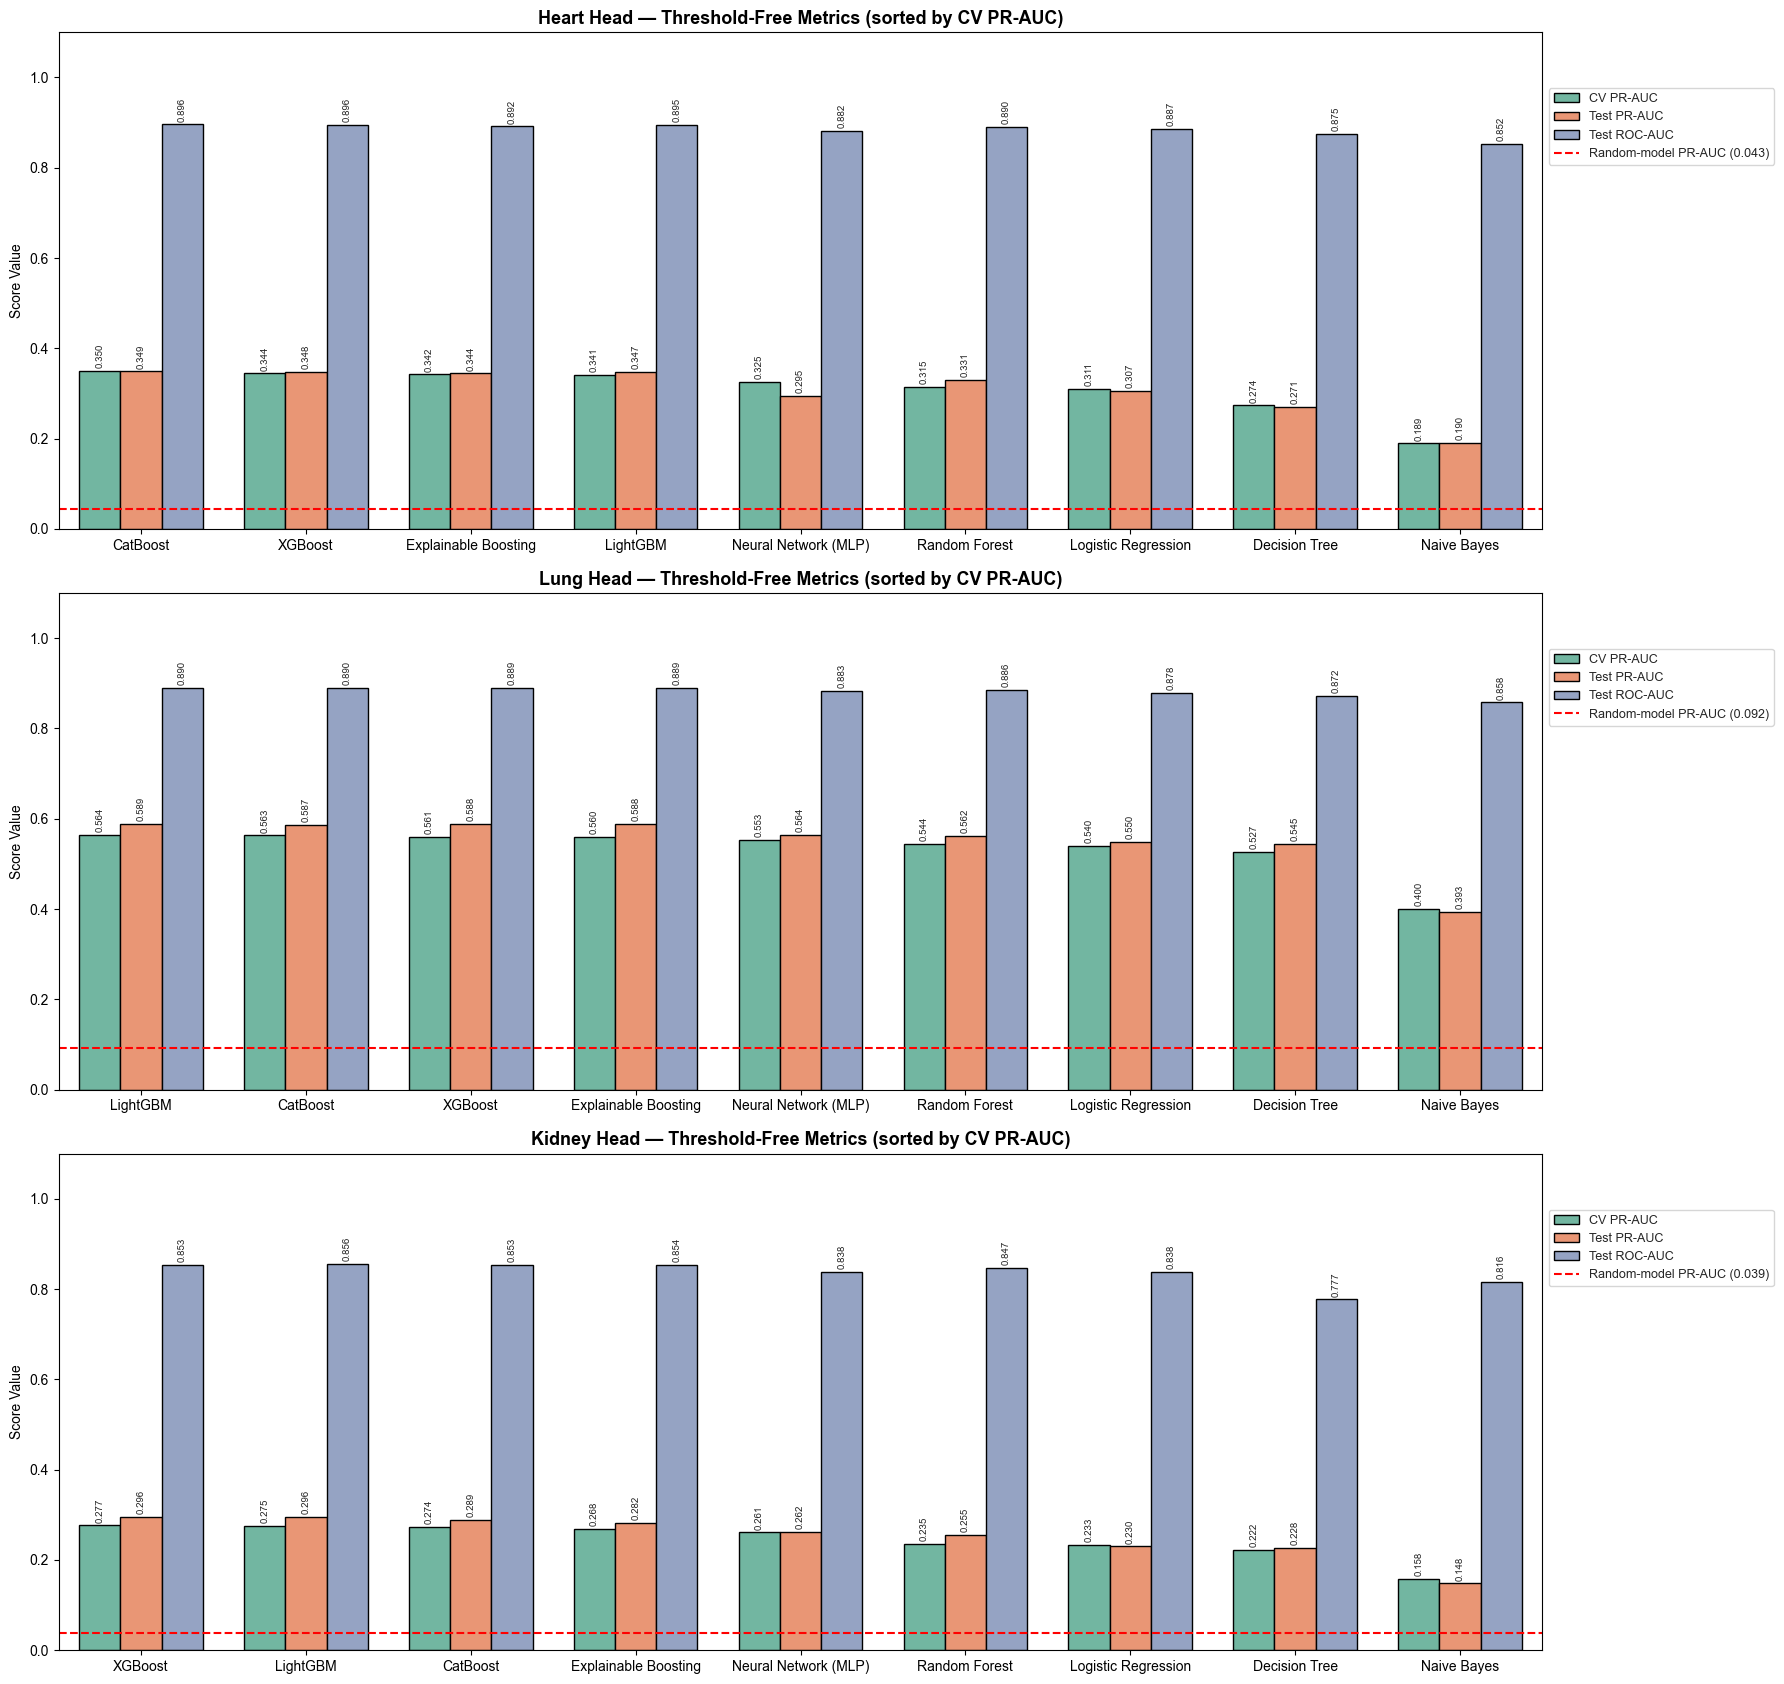

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(18, 17))
sns.set_theme(style="whitegrid")
for ax, organ in zip(axes, ORGANS):
    table = df_comparison.loc[organ].sort_values('CV PR-AUC', ascending=False)
    melted = table.reset_index()[['Model', 'CV PR-AUC', 'Test PR-AUC', 'Test ROC-AUC']].melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=melted, x='Model', y='Score', hue='Metric', palette='Set2', edgecolor='black', width=0.75, ax=ax)
    ax.axhline(Y_test[organ].mean(), color='red', linestyle='--', lw=1.5, label=f'Random-model PR-AUC ({Y_test[organ].mean():.3f})')
    ax.set_title(f'{ORGAN_LABELS[organ]} Head — Threshold-Free Metrics (sorted by CV PR-AUC)', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Score Value')
    ax.set_ylim(0, 1.1)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 0.9), fontsize=9)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=2, fontsize=7, rotation=90)
plt.tight_layout()
save_figure("model_comparison_barchart.png")
plt.show()

* **Gradient-boosted trees lead every head, and they are close:**
    * heart: CatBoost 0.350 CV PR-AUC (XGBoost 0.344, EBM 0.342, LightGBM 0.341)
    * lung: LightGBM 0.564 (CatBoost 0.563, XGBoost 0.561, EBM 0.560)
    * kidney: XGBoost 0.277 (LightGBM 0.275, CatBoost 0.274, EBM 0.268)

  The top four of each head are within about 0.01.
* **Every head is 6–8× better than chance:** the best test PR-AUC is 0.349 for the heart (prevalence 0.043), 0.589 for the lung (0.092) and 0.296 for the kidney (0.039). The best test ROC-AUC is 0.896, 0.890 and 0.856.
* **The lung head is the easiest and the kidney head the hardest.** Lung complaints (cough, wheezing, fever) are specific. Many kidney diagnoses (acute kidney failure, chronic kidney disease) come with no kidney complaint at all.
* **Weaker models:** the MLP trails the best by 0.01–0.03 CV PR-AUC, the Random Forest and logistic regression by 0.02–0.04, the single decision tree by 0.04–0.08 and Naive Bayes by 0.12–0.16. Symptoms interact (chest pain in a 70-year-old man is not chest pain in a 25-year-old woman), and tree ensembles capture that better than a linear model.

### Confusion Matrix

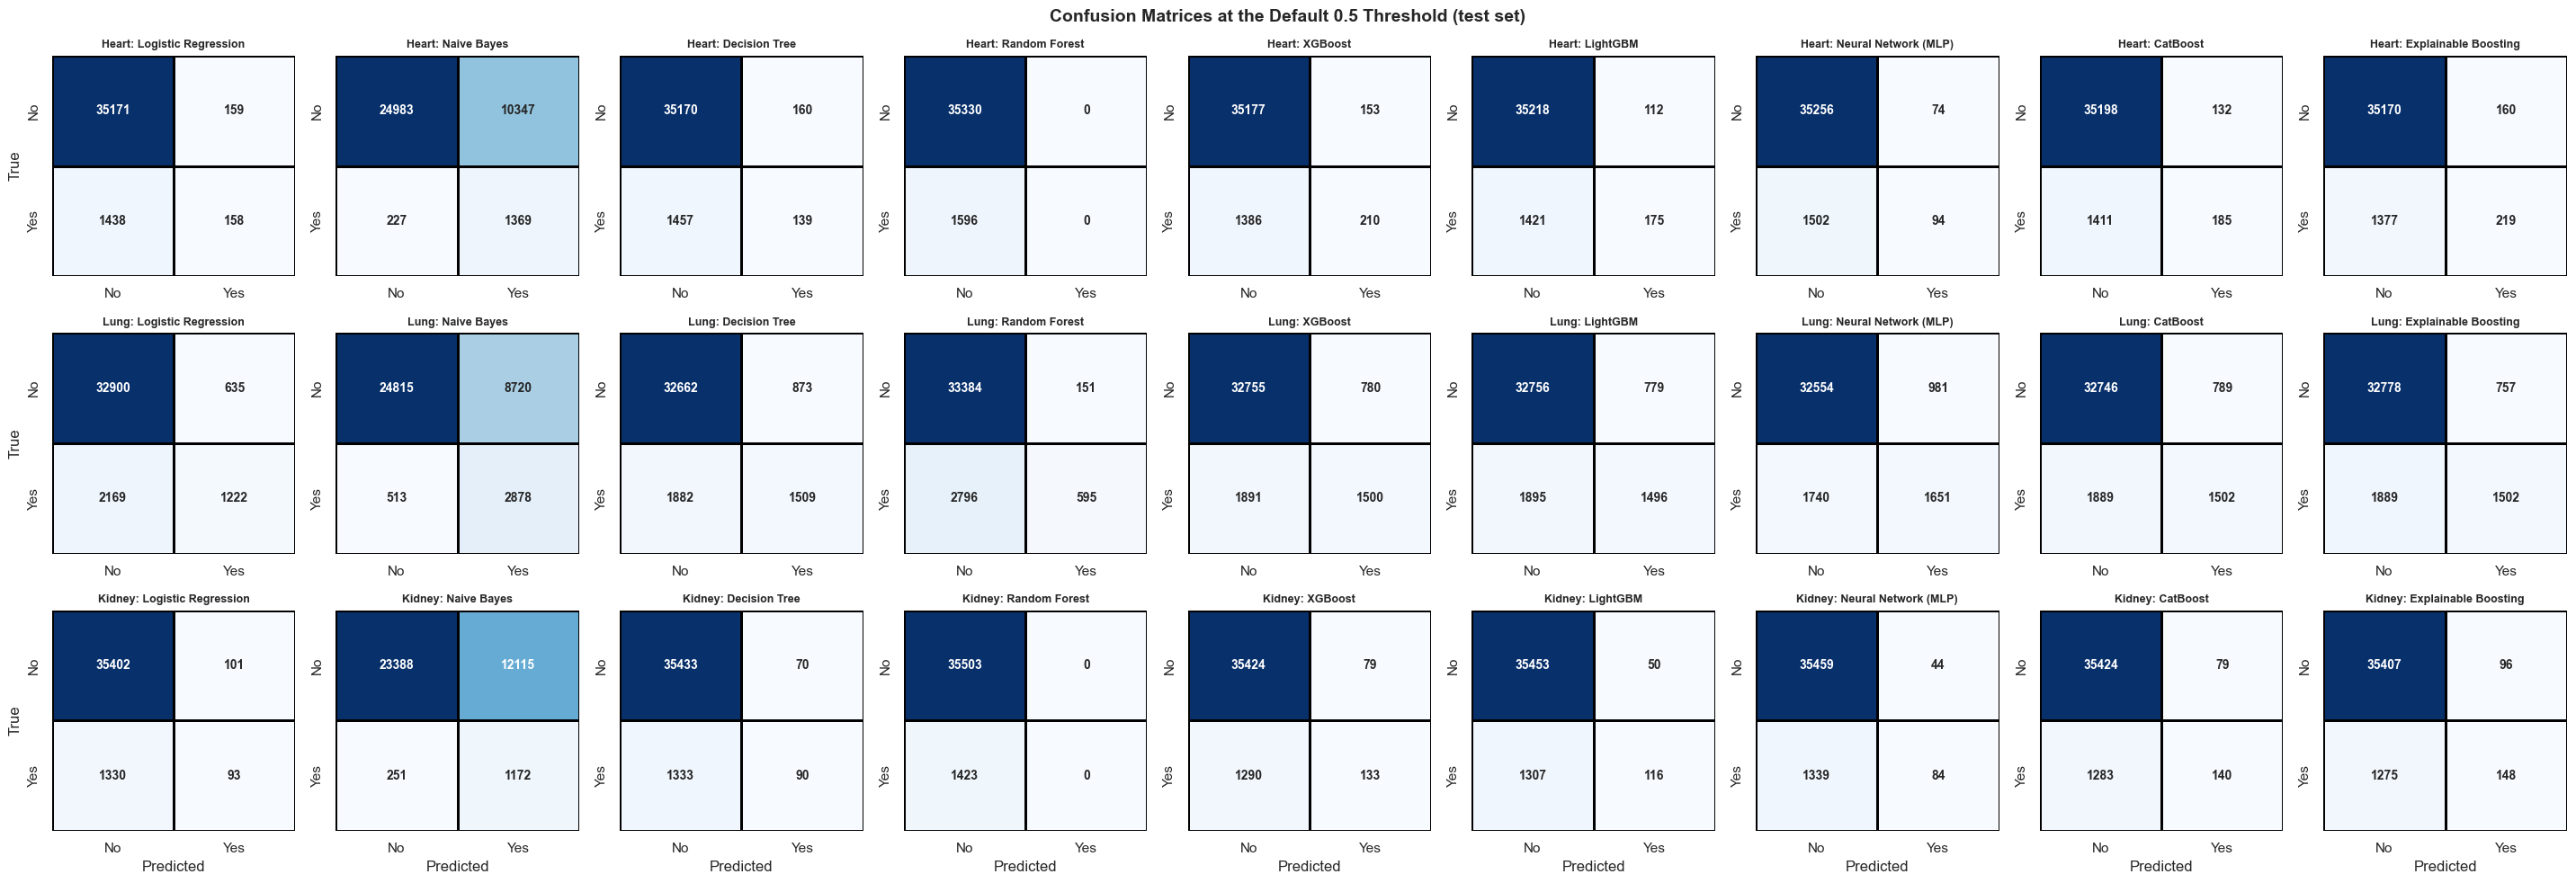

In [27]:
model_names = list(fitted_models[ORGANS[0]])
fig, axes = plt.subplots(len(ORGANS), len(model_names), figsize=(3.2 * len(model_names), 10))
for row, organ in enumerate(ORGANS):
    for col, name in enumerate(model_names):
        ax = axes[row, col]
        cm = confusion_matrix(Y_test[organ], (test_scores[organ][name] >= 0.5).astype(int))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
                    annot_kws={'size': 10, 'weight': 'bold'}, linewidths=1, linecolor='black', ax=ax)
        ax.set_title(f"{ORGAN_LABELS[organ]}: {name}", fontsize=9, fontweight='bold')
        ax.set_xlabel('Predicted' if row == len(ORGANS) - 1 else '')
        ax.set_ylabel('True' if col == 0 else '')
plt.suptitle('Confusion Matrices at the Default 0.5 Threshold (test set)', fontsize=14, fontweight='bold')
plt.tight_layout()
save_figure("models_confusion_matrix.png")
plt.show()

* **At 0.5 the heads rarely route anyone.** The four boosted heart models catch 175–219 of 1,596 heart visits (recall 11–14 %) and the kidney models 116–148 of 1,423 (8–10 %). The lung models, with more frequent and more specific complaints, reach 44 % recall at 0.5.
* **The Random Forest routes nobody** for the heart and kidney at 0.5 (its leaf averages never reach 50 %). **Naive Bayes routes almost everyone**, with 8,700–12,100 false alarms per head. The thresholds set below decide the router's behaviour, not the 0.5 default.

### ROC, PR Curve
AUC (area under the curve) measures a head's ability to tell its organ's visits from the rest: 0.5 is random guessing, 1.0 is perfect. For rare outcomes the PR curve is the more demanding view: its baseline is the prevalence, not 0.5.

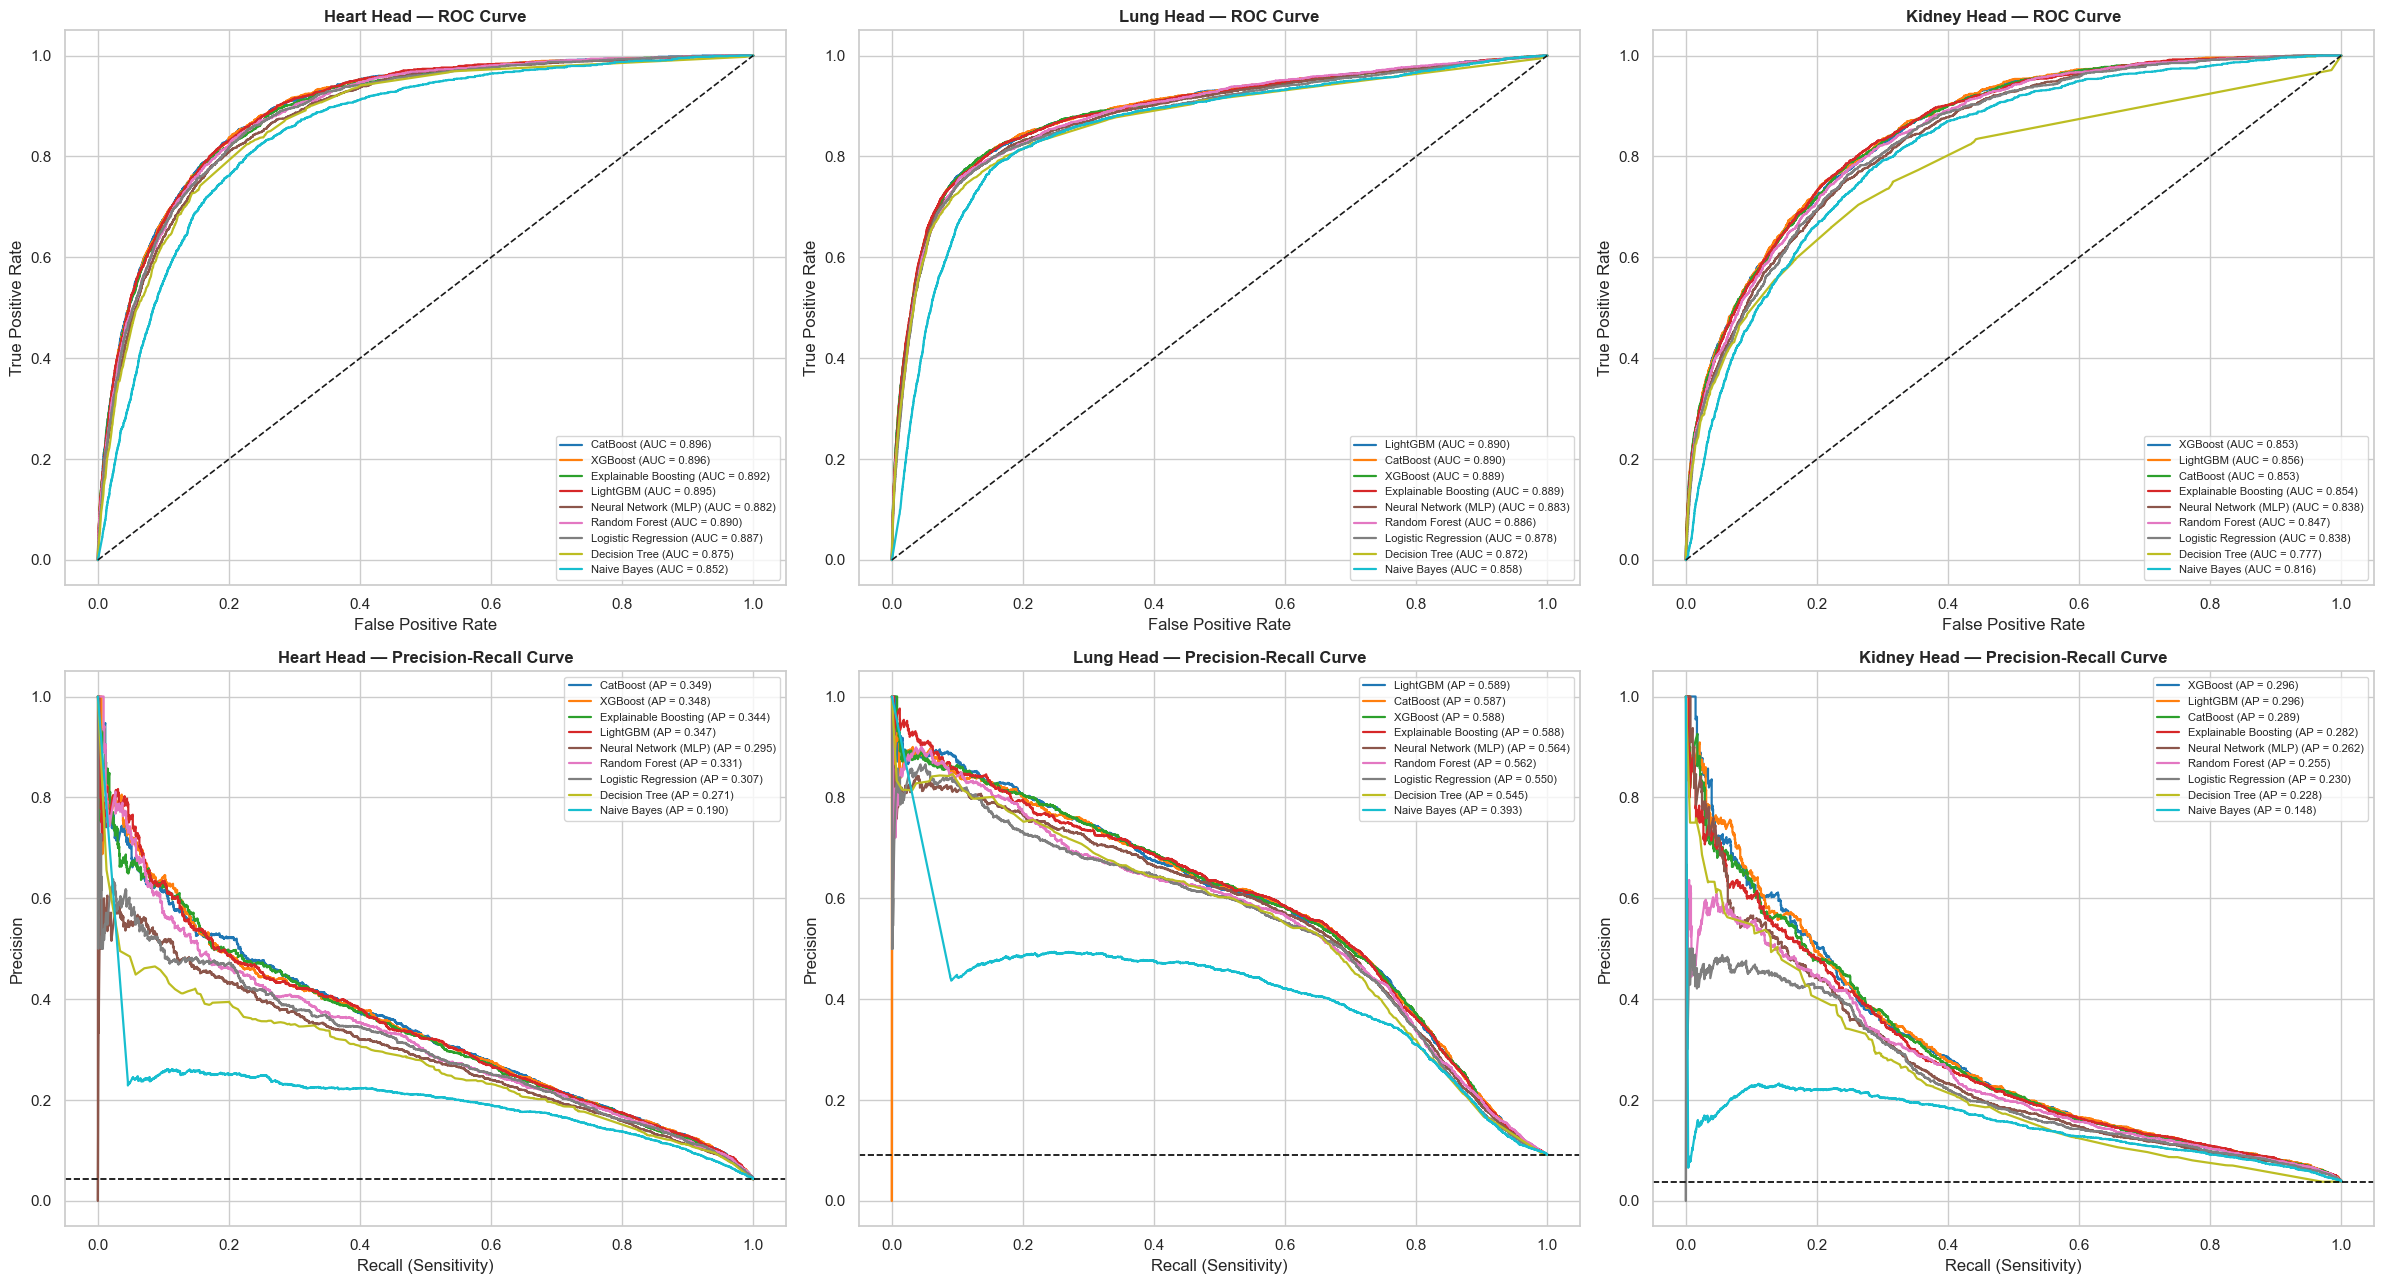

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(24, 13))
colors = plt.cm.tab10(np.linspace(0, 1, len(model_names)))
for col, organ in enumerate(ORGANS):
    table = df_comparison.loc[organ].sort_values('CV PR-AUC', ascending=False)
    ax_roc, ax_pr = axes[0, col], axes[1, col]
    for color, name in zip(colors, table.index):
        fpr, tpr, _ = roc_curve(Y_test[organ], test_scores[organ][name])
        precision_vals, recall_vals, _ = precision_recall_curve(Y_test[organ], test_scores[organ][name])
        ax_roc.plot(fpr, tpr, color=color, lw=1.6, label=f"{name} (AUC = {table.loc[name, 'Test ROC-AUC']:.3f})")
        ax_pr.plot(recall_vals, precision_vals, color=color, lw=1.6, label=f"{name} (AP = {table.loc[name, 'Test PR-AUC']:.3f})")
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.2)
    ax_roc.set_title(f'{ORGAN_LABELS[organ]} Head — ROC Curve', fontsize=12, fontweight='bold')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.legend(loc='lower right', fontsize=8)
    ax_pr.axhline(Y_test[organ].mean(), color='black', linestyle='--', lw=1.2)
    ax_pr.set_title(f'{ORGAN_LABELS[organ]} Head — Precision-Recall Curve', fontsize=12, fontweight='bold')
    ax_pr.set_xlabel('Recall (Sensitivity)')
    ax_pr.set_ylabel('Precision')
    ax_pr.legend(loc='upper right', fontsize=8)
plt.tight_layout()
save_figure("roc_pr_curve.png")
plt.show()

* **The ROC curves of the boosted models overlap** (heart 0.892–0.896, lung 0.889–0.890, kidney 0.853–0.856): they rank visits in almost the same order.
* **The PR curves show the real difficulty.** The lung head keeps about 65 % precision up to 45 % recall. By the time they find about half of their patients, the heart head is down to about 30 % precision and the kidney head to about 23 %. A router that catches most heart and kidney patients must also send many other patients to those modules.

# Best Supervised Model
**Selection rule: one standard error, per head.** Picking the single highest score over-reads noise when the top models differ by less than their own fold-to-fold variation. Following Breiman et al. (1984) and Hastie et al. (2009), each head takes the best CV PR-AUC, subtracts one standard error, and chooses the **simplest** model that clears that bar: glass-box models first, then tree ensembles, then the neural network. Only training-set cross-validation is used, never the test set. The three heads may pick different models.

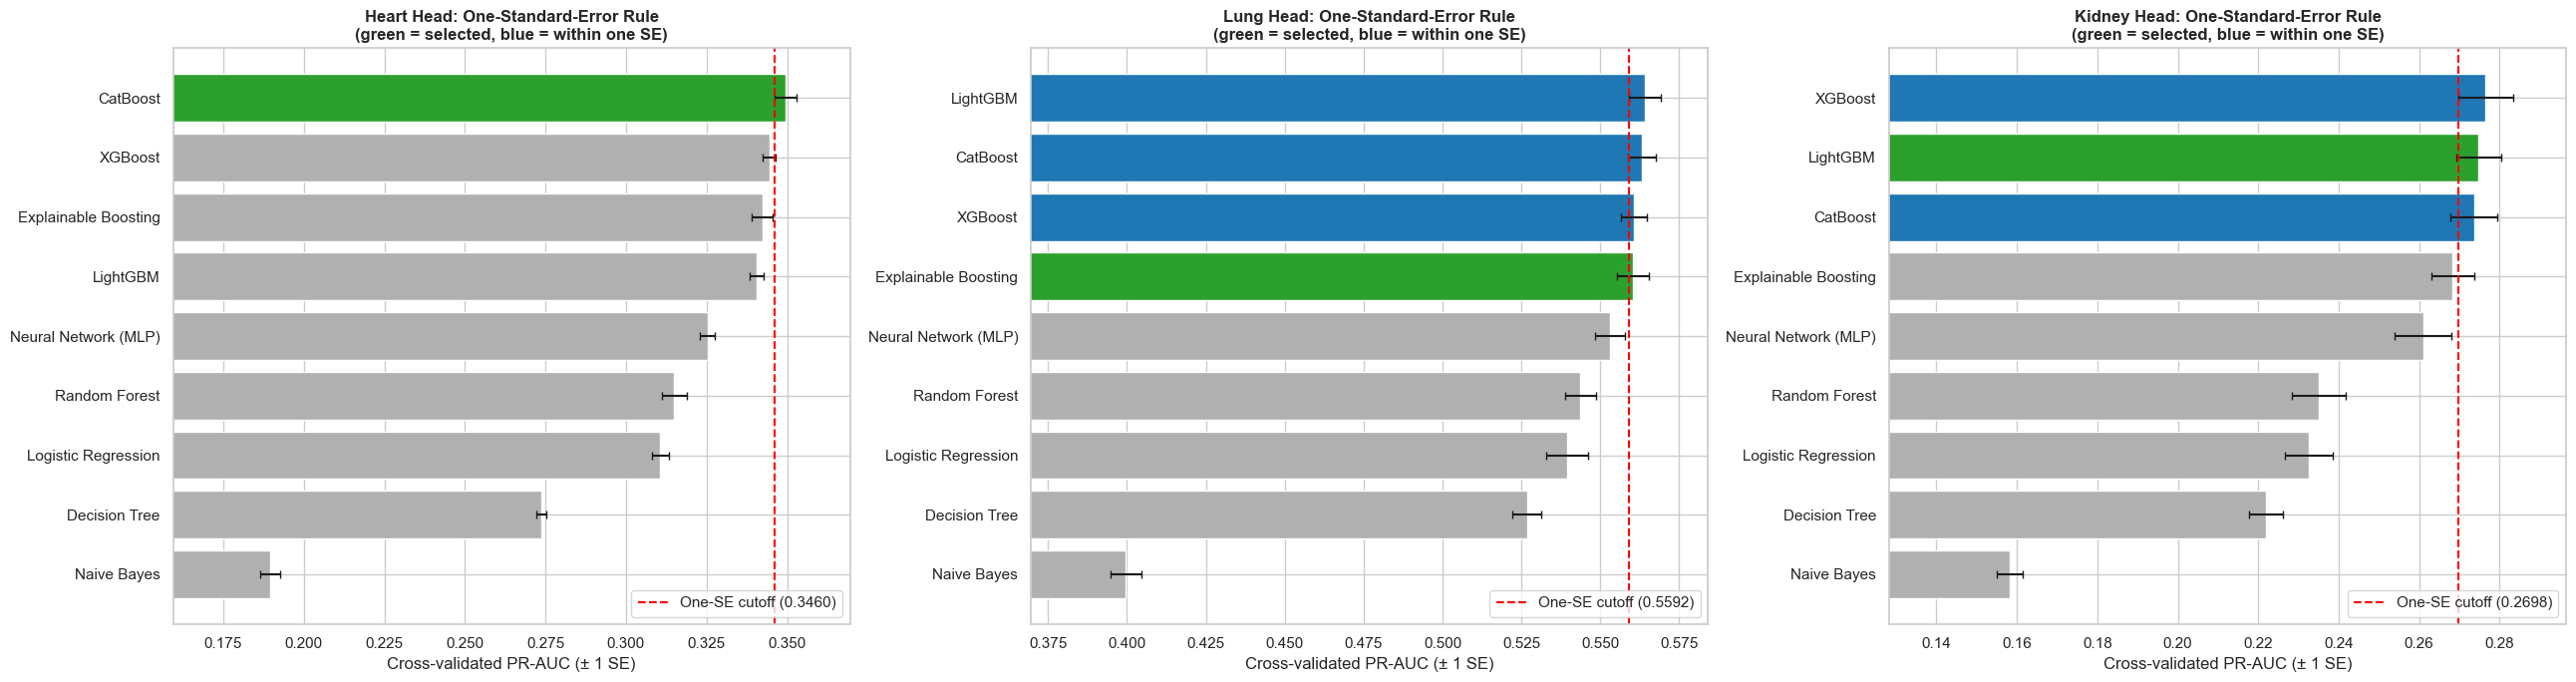

--- Heart head ---
Highest CV PR-AUC   : CatBoost (0.3495 ± 0.0035 SE)
One-SE cutoff       : 0.3460
Within one SE       : ['CatBoost']
🏆 Selected         : CatBoost | CV PR-AUC 0.3495 | test PR-AUC 0.3491 | test ROC-AUC 0.8959

--- Lung head ---
Highest CV PR-AUC   : LightGBM (0.5641 ± 0.0050 SE)
One-SE cutoff       : 0.5592
Within one SE       : ['Explainable Boosting', 'LightGBM', 'XGBoost', 'CatBoost']
🏆 Selected         : Explainable Boosting | CV PR-AUC 0.5602 | test PR-AUC 0.5883 | test ROC-AUC 0.8895

--- Kidney head ---
Highest CV PR-AUC   : XGBoost (0.2765 ± 0.0068 SE)
One-SE cutoff       : 0.2698
Within one SE       : ['LightGBM', 'XGBoost', 'CatBoost']
🏆 Selected         : LightGBM | CV PR-AUC 0.2748 | test PR-AUC 0.2963 | test ROC-AUC 0.8559



In [29]:
# Simplest -> most complex (interpretability and deployment cost)
complexity_order = ['Logistic Regression', 'Naive Bayes', 'Decision Tree', 'Explainable Boosting', 'Random Forest',
                    'LightGBM', 'XGBoost', 'CatBoost', 'Neural Network (MLP)']

best_model_name, within_one_se, one_se_cutoff = {}, {}, {}
fig, axes = plt.subplots(1, 3, figsize=(26, 7))
for ax, organ in zip(axes, ORGANS):
    table = df_comparison.loc[organ]
    top_model = table['CV PR-AUC'].idxmax()
    one_se_cutoff[organ] = table.loc[top_model, 'CV PR-AUC'] - table.loc[top_model, 'CV SE']
    within_one_se[organ] = [m for m in complexity_order if m in table.index and table.loc[m, 'CV PR-AUC'] >= one_se_cutoff[organ]]
    best_model_name[organ] = within_one_se[organ][0]

    ranked = table.sort_values('CV PR-AUC')
    bar_colors = ['#2ca02c' if m == best_model_name[organ] else '#1f77b4' if m in within_one_se[organ] else '#b0b0b0'
                  for m in ranked.index]
    ax.barh(ranked.index, ranked['CV PR-AUC'], xerr=ranked['CV SE'], color=bar_colors, capsize=3)
    ax.axvline(one_se_cutoff[organ], color='red', linestyle='--', lw=1.5, label=f'One-SE cutoff ({one_se_cutoff[organ]:.4f})')
    ax.set_xlim(ranked['CV PR-AUC'].min() - 0.03, ranked['CV PR-AUC'].max() + 0.02)
    ax.set_xlabel('Cross-validated PR-AUC (± 1 SE)')
    ax.set_title(f'{ORGAN_LABELS[organ]} Head: One-Standard-Error Rule\n(green = selected, blue = within one SE)', fontweight='bold')
    ax.legend(loc='lower right')
plt.tight_layout()
save_figure("model_selection_one_se.png")
plt.show()

for organ in ORGANS:
    table = df_comparison.loc[organ]
    top_model = table['CV PR-AUC'].idxmax()
    best = best_model_name[organ]
    print(f"--- {ORGAN_LABELS[organ]} head ---")
    print(f"Highest CV PR-AUC   : {top_model} ({table.loc[top_model, 'CV PR-AUC']:.4f} ± {table.loc[top_model, 'CV SE']:.4f} SE)")
    print(f"One-SE cutoff       : {one_se_cutoff[organ]:.4f}")
    print(f"Within one SE       : {within_one_se[organ]}")
    print(f"🏆 Selected         : {best} | CV PR-AUC {table.loc[best, 'CV PR-AUC']:.4f} | "
          f"test PR-AUC {table.loc[best, 'Test PR-AUC']:.4f} | test ROC-AUC {table.loc[best, 'Test ROC-AUC']:.4f}\n")

* **Heart: CatBoost.** It is the only model within one standard error of the best (0.3495 ± 0.0035); XGBoost (0.3445) misses the 0.3460 cutoff.
* **Lung: the Explainable Boosting Machine.** LightGBM scores highest (0.5641 ± 0.0050), and four models clear the 0.5592 cutoff. EBM (0.5602) is the simplest of them: a glass-box sum of per-feature shape functions. On the test set it equals the best (PR-AUC 0.588 vs 0.589).
* **Kidney: LightGBM** (0.2748), the simplest of the three models within one standard error of XGBoost (0.2765 ± 0.0068). EBM (0.2683) just misses the 0.2698 cutoff.
* The three heads therefore use three model families. That costs nothing at prediction time, because each head is a separate calibrated pipeline.

### Model Calibration
The router compares each head's probability with a threshold, and the explanations quote probabilities ("a 30 % chance of a lung diagnosis"), so they have to mean what they say. `CalibratedClassifierCV` fits isotonic regression on held-out folds of the (dropout) training data. The reliability diagrams show each head before calibration, after calibration, and after calibration for visits scored **without vital signs**.

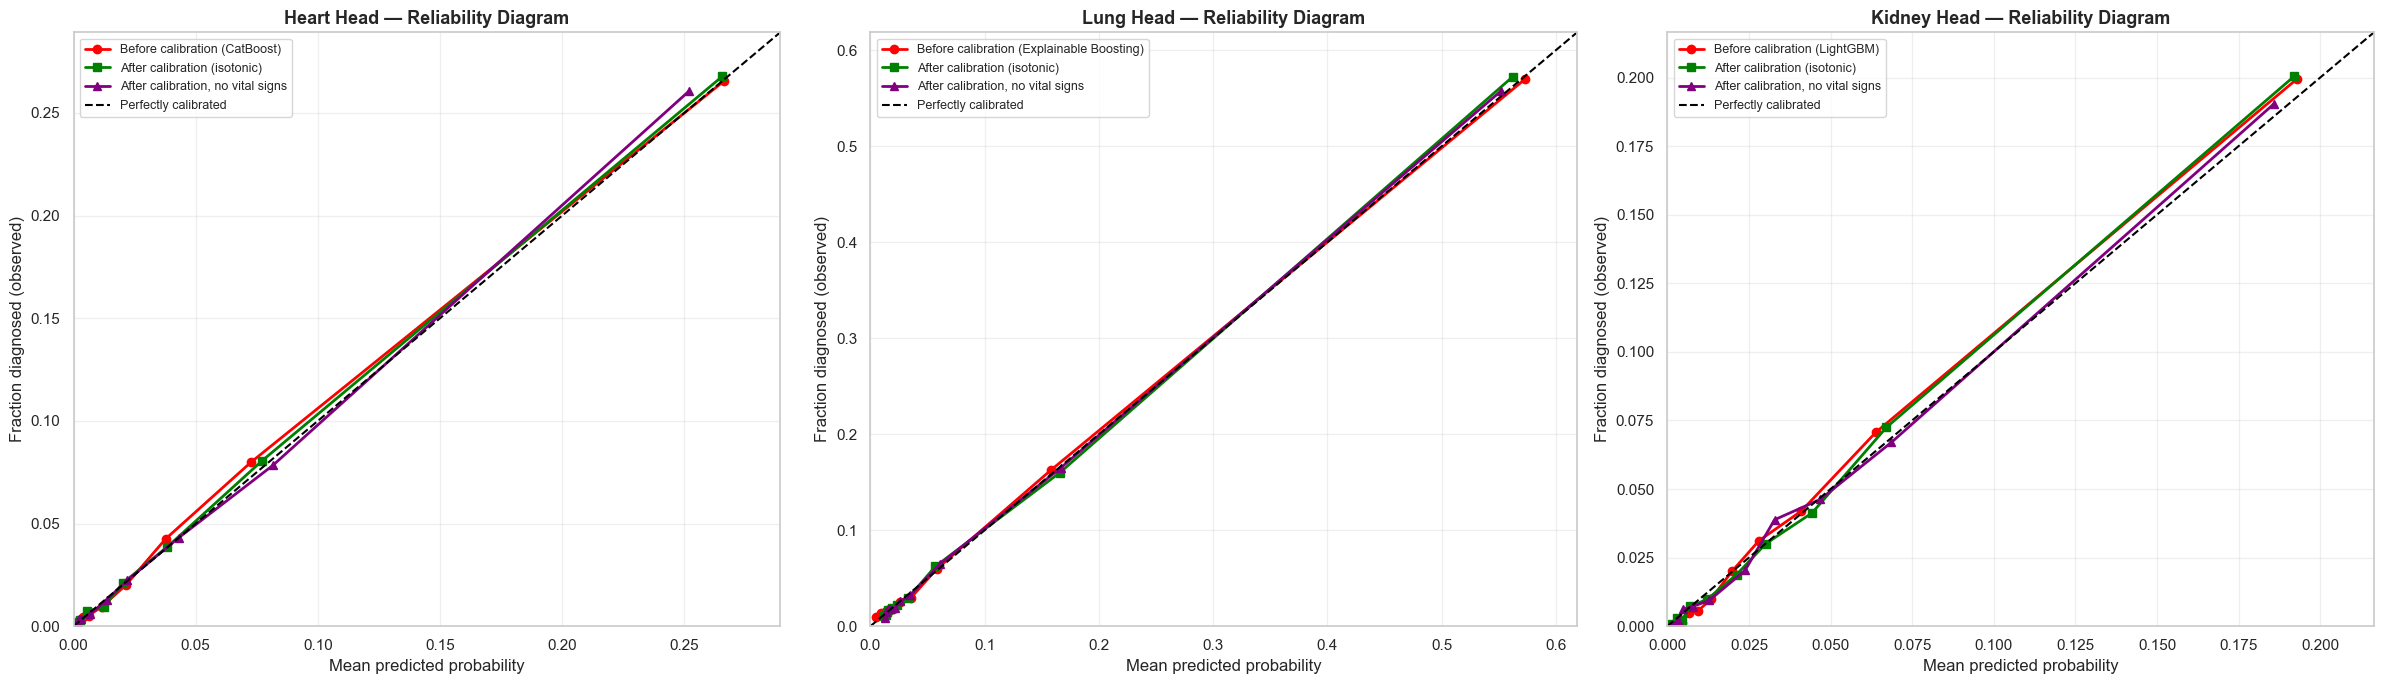

In [30]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

calibrated_models, raw_probas, calib_probas, calib_probas_no_vitals = {}, {}, {}, {}
for organ in ORGANS:
    winner = fitted_models[organ][best_model_name[organ]]
    # Fitted in this process on purpose: pipelines fitted in parallel workers come back holding a copy of
    # add_custom_features, and joblib.dump can only save the notebook's own function (by name)
    calibrated_models[organ] = CalibratedClassifierCV(estimator=winner, method='isotonic', cv=3).fit(X_train_aug, Y_train[organ])
    raw_probas[organ] = winner.predict_proba(X_test)[:, 1]
    calib_probas[organ] = calibrated_models[organ].predict_proba(X_test)[:, 1]
    calib_probas_no_vitals[organ] = calibrated_models[organ].predict_proba(X_test_no_vitals)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
for ax, organ in zip(axes, ORGANS):
    curves = []
    for probas, label, style in [(raw_probas[organ], f'Before calibration ({best_model_name[organ]})', ('o', 'red')),
                                 (calib_probas[organ], 'After calibration (isotonic)', ('s', 'green')),
                                 (calib_probas_no_vitals[organ], 'After calibration, no vital signs', ('^', 'purple'))]:
        prob_true, prob_pred = calibration_curve(Y_test[organ], probas, n_bins=10, strategy='quantile')
        ax.plot(prob_pred, prob_true, marker=style[0], color=style[1], lw=2, label=label)
        curves.extend([prob_true.max(), prob_pred.max()])
    top = max(curves) * 1.08                                # zoom on the range the probabilities actually use
    ax.plot([0, top], [0, top], linestyle='--', color='black', label='Perfectly calibrated')
    ax.set_xlim(0, top)
    ax.set_ylim(0, top)
    ax.set_title(f'{ORGAN_LABELS[organ]} Head — Reliability Diagram', fontsize=13, fontweight='bold')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction diagnosed (observed)')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
save_figure("reliability_diagram.png")
plt.show()

* **All three heads are well calibrated, before and after isotonic calibration.** The curves follow the diagonal from the lowest decile to the highest (top-decile mean prediction about 27 % heart, 57 % lung, 19 % kidney). Boosted trees trained without oversampling are close to calibrated already, and isotonic regression only makes small corrections (see the Brier scores below).
* **Without vital signs the curves stay on the diagonal too.** This is the payoff of the vital-sign dropout: a probability of 20 % means about 20 %, whether or not the patient gave measurements.

### Threshold Analysis
Each head's threshold is chosen on **out-of-fold predictions from the training set**: every training visit is scored by a calibrated model that never saw it. Tuning it on the test set would make the reported test metrics optimistic. The table below shows what several fixed thresholds would do on the test set.

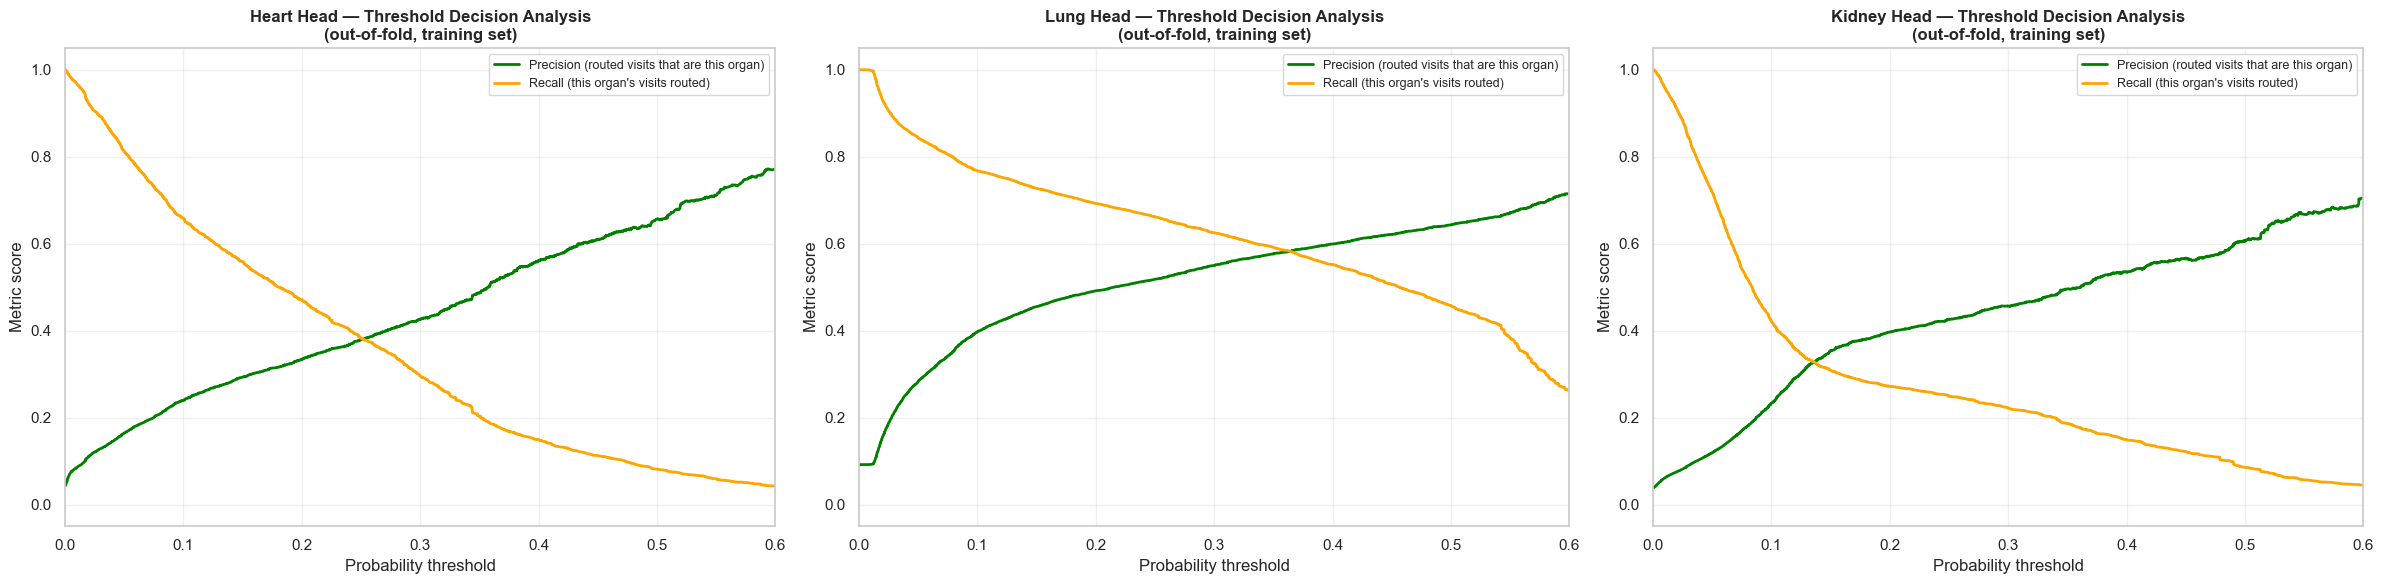


========================= OPERATIONAL IMPACT TABLE (test set, with vital signs) =========================


Routed correctly (TP)  Missed (FN)  \
Head   Threshold                                       
heart  0.02                        1471          125   
       0.05                        1296          300   
       0.10                        1039          557   
       0.15                         884          712   
       0.20                         746          850   
       0.30                         485         1111   
       0.50                         149         1447   
lung   0.02                        3137          254   
       0.05                        2872          519   
       0.10                        2632          759   
       0.15                        2507          884   
       0.20                        2387         1004   
       0.30                        2172         1219   
       0.50                        1535         1856   
kidney 0.02                        1321          102   
       0.05                        1043          380   
       0.10                         638          785   
       0.15                         465          958   
       0.20                         391         1032   
       0.30                         315         1108   
       0.50                         143         1280   

                  Routed unnecessarily (FP) Recall  \
Head   Threshold                                     
heart  0.02                           11398  92.2%   
       0.05                            6301  81.2%   
       0.10                            3115  65.1%   
       0.15                            2075  55.4%   
       0.20                            1418  46.7%   
       0.30                             606  30.4%   
       0.50                              82   9.3%   
lung   0.02                           15765  92.5%   
       0.05                            6866  84.7%   
       0.10                            4000  77.6%   
       0.15                            2947  73.9%   
       0.20                            2380  70.4%   
       0.30                            1699  64.1%   
       0.50                             798  45.3%   
kidney 0.02                           15668  92.8%   
       0.05                            7101  73.3%   
       0.10                            2042  44.8%   
       0.15                             925  32.7%   
       0.20                             638  27.5%   
       0.30                             353  22.1%   
       0.50                              78  10.0%   

                 Share of other visits routed  
Head   Threshold                               
heart  0.02                             32.3%  
       0.05                             17.8%  
       0.10                              8.8%  
       0.15                              5.9%  
       0.20                              4.0%  
       0.30                              1.7%  
       0.50                              0.2%  
lung   0.02                             47.0%  
       0.05                             20.5%  
       0.10                             11.9%  
       0.15                              8.8%  
       0.20                              7.1%  
       0.30                              5.1%  
       0.50                              2.4%  
kidney 0.02                             44.1%  
       0.05                             20.0%  
       0.10                              5.8%  
       0.15                              2.6%  
       0.20                              1.8%  
       0.30                              1.0%  
       0.50                              0.2%

In [31]:
oof_probas = {}
for organ in ORGANS:
    oof_jobs = 1 if best_model_name[organ] == 'Explainable Boosting' else min(5, N_JOBS)
    oof_probas[organ] = cross_val_predict(
        CalibratedClassifierCV(estimator=clone(fitted_models[organ][best_model_name[organ]]), method='isotonic', cv=3),
        X_train_aug, Y_train[organ], cv=cv_strategy, method='predict_proba', n_jobs=oof_jobs
    )[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(24, 6))
for ax, organ in zip(axes, ORGANS):
    precisions, recalls, thresholds = precision_recall_curve(Y_train[organ], oof_probas[organ])
    ax.plot(thresholds, precisions[:-1], label='Precision (routed visits that are this organ)', color='green', lw=2)
    ax.plot(thresholds, recalls[:-1], label="Recall (this organ's visits routed)", color='orange', lw=2)
    ax.set_title(f'{ORGAN_LABELS[organ]} Head — Threshold Decision Analysis\n(out-of-fold, training set)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Probability threshold')
    ax.set_ylabel('Metric score')
    ax.set_xlim(0, 0.6)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

simulation = []
for organ in ORGANS:
    y_true = Y_test[organ].values
    for t in [0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50]:
        preds = calib_probas[organ] >= t
        tp, fn = int((preds & (y_true == 1)).sum()), int((~preds & (y_true == 1)).sum())
        fp, tn = int((preds & (y_true == 0)).sum()), int((~preds & (y_true == 0)).sum())
        simulation.append({'Head': organ, 'Threshold': t, 'Routed correctly (TP)': tp, 'Missed (FN)': fn,
                           'Routed unnecessarily (FP)': fp, 'Recall': f"{tp / (tp + fn):.1%}",
                           'Share of other visits routed': f"{fp / (tn + fp):.1%}"})
print("\n========================= OPERATIONAL IMPACT TABLE (test set, with vital signs) =========================")
display(pd.DataFrame(simulation).set_index(['Head', 'Threshold']))

* **Recall is cheap for the lung and expensive for the kidney.**
    * Lung: routing 8.8 % of the other visits to the lung module (threshold 0.15) catches 73.9 % of lung visits.
    * Heart: the same 8.8 % catches 65.1 % of heart visits (threshold 0.10).
    * Kidney: 44.8 % recall costs 5.8 % of other visits (threshold 0.10), and 73.3 % recall costs 20.0 % (threshold 0.05).
* **Catching 9 in 10 patients of any organ needs a threshold near 0.02.** That sends a third to almost a half of all other visits to that organ's module.

### Automated Cost-Based Threshold Optimization
A missed organ (False Negative: the patient is never shown to that organ's model) is penalised 5 and an unnecessary routing (False Positive: one extra organ model runs) 1, the same 5:1 ratio as the heart, kidney and lung modules. The cost is summed over **visit counts** (5·FN + 1·FP). For perfectly calibrated probabilities, decision theory puts the optimum at *p* = 1 / (1 + 5) ≈ 0.167, a useful cross-check.

Bayes-optimal threshold for perfectly calibrated probabilities: 0.1667

Heart   head: cost-optimal threshold (out-of-fold, training set) = 0.1509
Lung    head: cost-optimal threshold (out-of-fold, training set) = 0.1617
Kidney  head: cost-optimal threshold (out-of-fold, training set) = 0.1544

=== Metrics at the cost-optimal thresholds (test set) ===


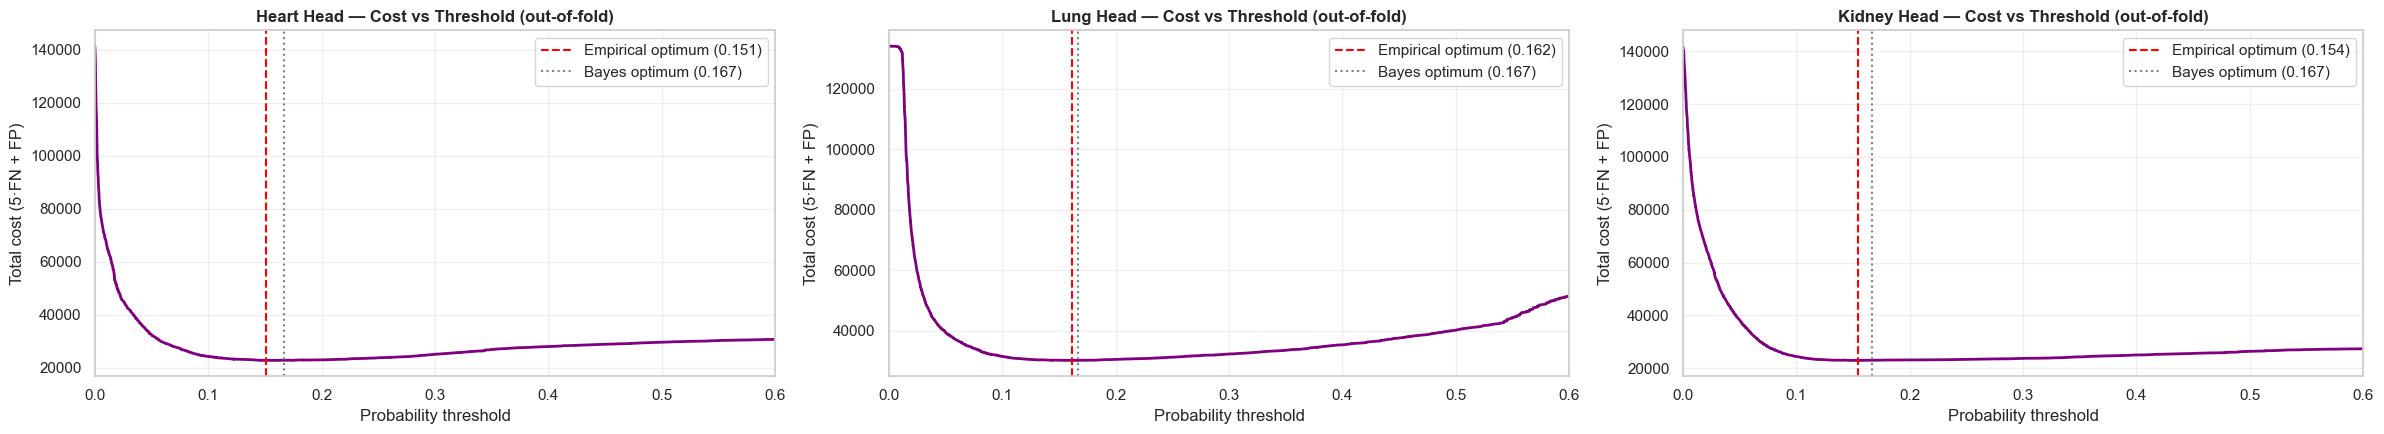

In [32]:
FN_COST, FP_COST = 5, 1

def threshold_costs(y_true, probas, candidates):
    # 5·FN + 1·FP at every candidate threshold (predict positive when p >= t)
    positives = np.sort(probas[y_true == 1])
    negatives = np.sort(probas[y_true == 0])
    missed = np.searchsorted(positives, candidates, side='left')
    false_alarms = len(negatives) - np.searchsorted(negatives, candidates, side='left')
    return FN_COST * missed + FP_COST * false_alarms

best_threshold, cost_curves = {}, {}
bayes_threshold = FP_COST / (FP_COST + FN_COST)
for organ in ORGANS:
    candidates = np.unique(oof_probas[organ])
    costs = threshold_costs(Y_train[organ].values, oof_probas[organ], candidates)
    best_threshold[organ] = float(candidates[np.argmin(costs)])
    cost_curves[organ] = (candidates, costs)

def operating_metrics(y_true, probas, threshold):
    preds = (probas >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return {'Threshold': threshold, 'Recall': recall_score(y_true, preds, zero_division=0),
            'Precision': precision_score(y_true, preds, zero_division=0), 'Specificity': tn / (tn + fp),
            'F1-Score': f1_score(y_true, preds, zero_division=0), 'ROC-AUC': roc_auc_score(y_true, probas),
            'PR-AUC': average_precision_score(y_true, probas), 'Missed (FN)': int(fn), 'Routed unnecessarily (FP)': int(fp)}

print(f"Bayes-optimal threshold for perfectly calibrated probabilities: {bayes_threshold:.4f}\n")
threshold_rows = []
for organ in ORGANS:
    print(f"{ORGAN_LABELS[organ]:7s} head: cost-optimal threshold (out-of-fold, training set) = {best_threshold[organ]:.4f}")
    for inputs, probas in [('with vital signs', calib_probas[organ]), ('without vital signs', calib_probas_no_vitals[organ])]:
        threshold_rows.append({'Head': organ, 'Test inputs': inputs, **operating_metrics(Y_test[organ], probas, best_threshold[organ])})
df_thresholds = pd.DataFrame(threshold_rows).set_index(['Head', 'Test inputs'])
print("\n=== Metrics at the cost-optimal thresholds (test set) ===")
display(df_thresholds.style.format({c: '{:.4f}' for c in ['Threshold', 'Recall', 'Precision', 'Specificity', 'F1-Score', 'ROC-AUC', 'PR-AUC']}))

fig, axes = plt.subplots(1, 3, figsize=(24, 4.5))
for ax, organ in zip(axes, ORGANS):
    candidates, costs = cost_curves[organ]
    ax.plot(candidates, costs, color='purple', lw=2)
    ax.axvline(best_threshold[organ], color='red', linestyle='--', label=f'Empirical optimum ({best_threshold[organ]:.3f})')
    ax.axvline(bayes_threshold, color='gray', linestyle=':', label=f'Bayes optimum ({bayes_threshold:.3f})')
    ax.set_xlim(0, 0.6)
    ax.set_xlabel('Probability threshold')
    ax.set_ylabel('Total cost (5·FN + FP)')
    ax.set_title(f'{ORGAN_LABELS[organ]} Head — Cost vs Threshold (out-of-fold)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

* **The three cost-optimal thresholds are close to each other and to the Bayes optimum:** heart 0.151, lung 0.162 and kidney 0.154, against 1/6 = 0.167 for perfectly calibrated probabilities. The calibration holds out of fold.
* **On the test set, with vital signs:**

  | Head | Recall | Precision | Specificity |
  |---|---|---|---|
  | Heart | 55.3 % | 29.9 % | 94.2 % |
  | Lung | 73.1 % | 47.0 % | 91.7 % |
  | Kidney | 32.0 % | 33.6 % | 97.5 % |

  Without vital signs, recall drops by 1–3 points (54.0, 71.5 and 29.3 %).
* **The 5:1 cost is a policy choice.** For a router, an unnecessary routing only means one more organ module runs, so a higher cost for a missed organ is defensible. At 20:1 (Bayes threshold ≈ 0.048), the operating table above gives about 81 % heart, 85 % lung and 73 % kidney recall. The price is sending about a fifth of the other visits to each module. The 5:1 ratio is kept for consistency with the heart, kidney and lung modules; each threshold is a single number in `models/metadata.json`.

### Best Threshold In Confusion Matrix

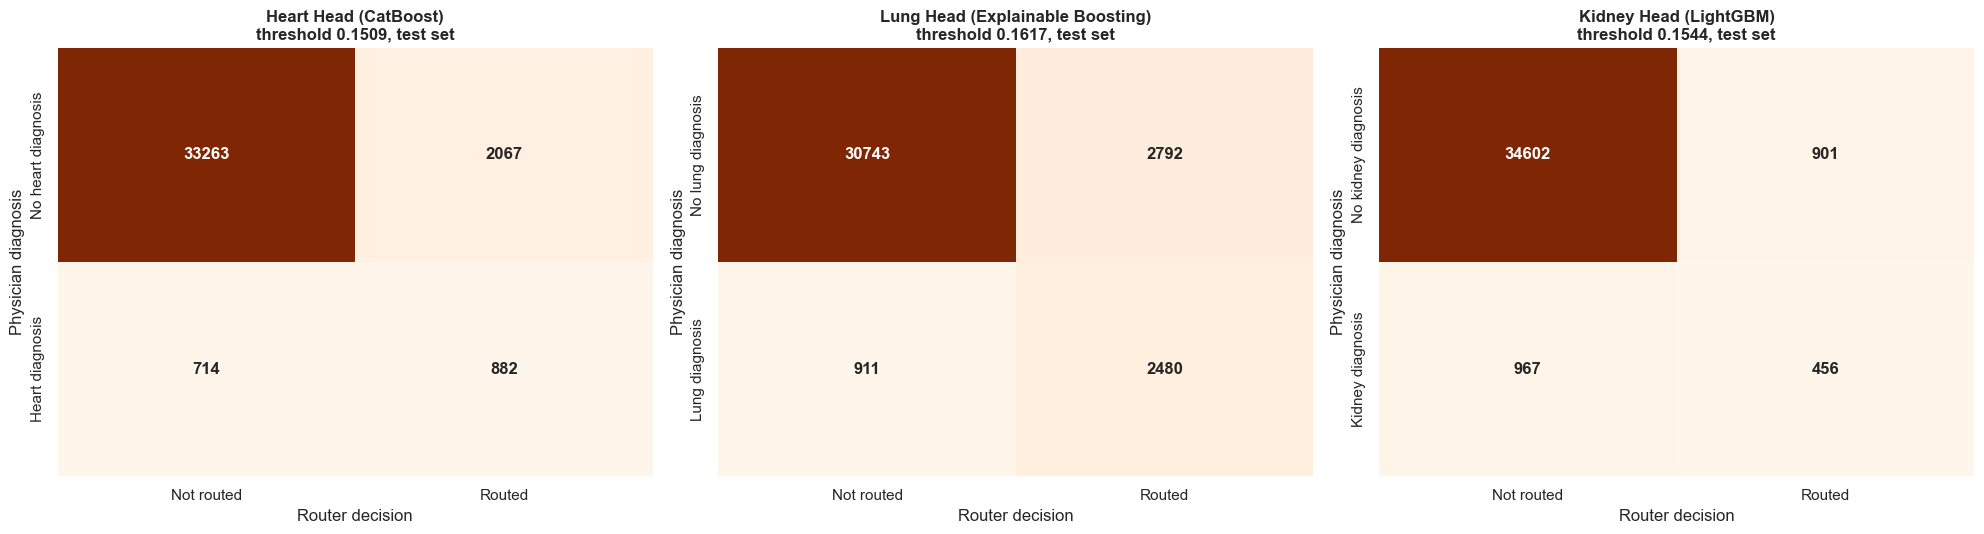

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
for ax, organ in zip(axes, ORGANS):
    cm = confusion_matrix(Y_test[organ], (calib_probas[organ] >= best_threshold[organ]).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False, xticklabels=['Not routed', 'Routed'],
                yticklabels=[f'No {organ} diagnosis', f'{ORGAN_LABELS[organ]} diagnosis'], annot_kws={'size': 12, 'weight': 'bold'}, ax=ax)
    ax.set_title(f'{ORGAN_LABELS[organ]} Head ({best_model_name[organ]})\nthreshold {best_threshold[organ]:.4f}, test set', fontsize=12, fontweight='bold')
    ax.set_xlabel('Router decision')
    ax.set_ylabel('Physician diagnosis')
plt.tight_layout()
save_figure("optimal_threshold_confusion_matrix.png")
plt.show()

### Routing: The Three Heads Together
A patient is routed to **every organ whose head reaches its threshold**, and to "other" if none does. When several organs are routed, the first one shown is the organ whose probability is furthest above its own threshold (the ratio *p* / threshold), because the thresholds differ between heads. The tables below measure the router as a whole on the test set, as recorded and without vital signs:

* **Organ recall:** of the visits diagnosed in an organ group, the share routed to that organ.
* **All organs caught / at least one caught:** among visits with any organ diagnosis.
* **Other left alone:** among visits with no organ diagnosis, the share routed to no organ.
* **Organ models run per visit:** the average number of organ modules a patient is sent to.

=== Router performance (test set) ===


,with vital signs,without vital signs
Heart recall,0.553,0.540
Lung recall,0.731,0.715
Kidney recall,0.320,0.293
Heart precision,0.299,0.290
Lung precision,0.470,0.461
Kidney precision,0.336,0.360
All diagnosed organs routed,0.585,0.569
At least one diagnosed organ routed,0.617,0.599
Other visits left alone,0.868,0.871
Visits routed to any organ,0.220,0.215


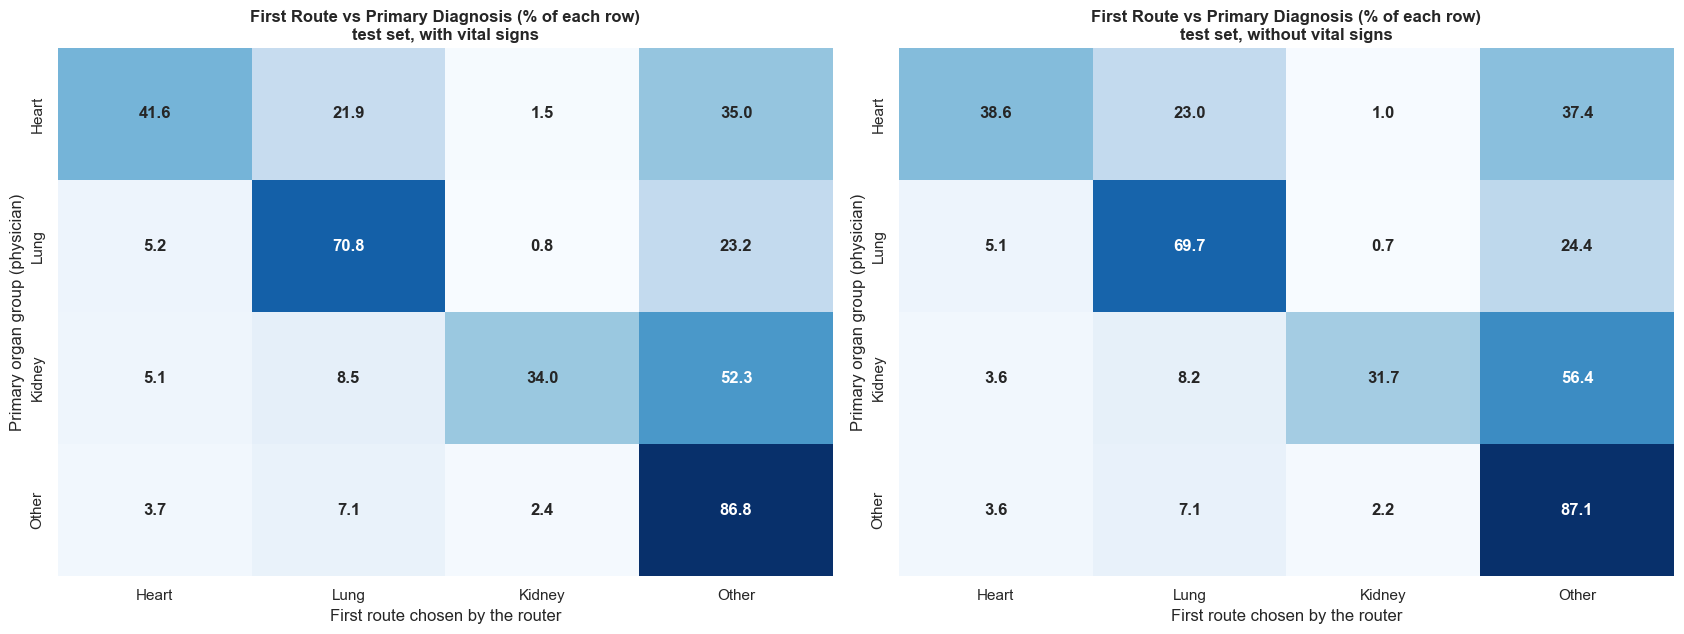

In [34]:
def route_visits(probabilities, thresholds):
    # Every organ at or above its threshold; the first route is the organ furthest above its own threshold
    probs = pd.DataFrame(probabilities)[ORGANS]
    cutoffs = pd.Series(thresholds)[ORGANS]
    flags = probs.ge(cutoffs)
    strength = probs.div(cutoffs).where(flags)
    primary = pd.Series('other', index=probs.index)
    routed = flags.any(axis=1)
    primary[routed] = strength[routed].idxmax(axis=1)
    return flags, primary

def routing_metrics(Y_true, flags):
    Y_true = Y_true.astype(bool)
    has_organ = Y_true.any(axis=1)
    metrics = {f'{ORGAN_LABELS[o]} recall': (flags[o] & Y_true[o]).sum() / Y_true[o].sum() for o in ORGANS}
    metrics.update({f'{ORGAN_LABELS[o]} precision': (flags[o] & Y_true[o]).sum() / max(flags[o].sum(), 1) for o in ORGANS})
    metrics['All diagnosed organs routed'] = ((flags | ~Y_true).all(axis=1) & has_organ).sum() / has_organ.sum()
    metrics['At least one diagnosed organ routed'] = ((flags & Y_true).any(axis=1)).sum() / has_organ.sum()
    metrics['Other visits left alone'] = (~flags.any(axis=1) & ~has_organ).sum() / (~has_organ).sum()
    metrics['Visits routed to any organ'] = flags.any(axis=1).mean()
    metrics['Organ models run per visit'] = flags.sum(axis=1).mean()
    return metrics

test_primary = triage_data.loc[X_test.index, 'primary_organ']
routing = {}
route_confusion = {}
for inputs, probas in [('with vital signs', calib_probas), ('without vital signs', calib_probas_no_vitals)]:
    flags, primary = route_visits(pd.DataFrame(probas, index=X_test.index), best_threshold)
    routing[inputs] = routing_metrics(Y_test, flags)
    route_confusion[inputs] = pd.crosstab(test_primary, primary, normalize='index').reindex(index=ROUTES, columns=ROUTES, fill_value=0)

df_routing = pd.DataFrame(routing)
print("=== Router performance (test set) ===")
display(df_routing.style.format('{:.3f}'))

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
for ax, (inputs, matrix) in zip(axes, route_confusion.items()):
    sns.heatmap(matrix * 100, annot=True, fmt='.1f', cmap='Blues', cbar=False, ax=ax,
                xticklabels=[ORGAN_LABELS[r] for r in ROUTES], yticklabels=[ORGAN_LABELS[r] for r in ROUTES],
                annot_kws={'size': 12, 'weight': 'bold'})
    ax.set_title(f'First Route vs Primary Diagnosis (% of each row)\ntest set, {inputs}', fontsize=12, fontweight='bold')
    ax.set_xlabel('First route chosen by the router')
    ax.set_ylabel('Primary organ group (physician)')
plt.tight_layout()
save_figure("routing_confusion_matrix.png")
plt.show()

* **The router sends 22 % of visits to at least one organ module and runs 0.26 organ modules per visit on average.** 86.8 % of the visits with no organ diagnosis are left alone ("other").
* **Of the visits with an organ diagnosis, 61.7 % are routed to at least one of their organs and 58.5 % to all of them.** The lung is caught best (73.1 %), then the heart (55.3 %) and the kidney (32.0 %).
* **The kidney misses are the silent diagnoses.** 58 % of the test visits with kidney stones or renal colic reach the kidney module, but only 6 % of those with acute kidney failure and 10 % of those with chronic kidney disease, end-stage disease or dialysis. These patients come in with weakness, breathlessness or an unrelated complaint. Symptoms alone cannot find them; that is the CKD risk model's job, on laboratory values.
* **The first route is usually right for the lung and split for the heart.**
    * 70.8 % of primary-lung visits go to the lung first.
    * 41.6 % of primary-heart visits go to the heart first, 21.9 % to the lung first and 35.0 % to no module. The lung-first heart visits are 59 % heart failure, whose breathlessness looks like lung disease, and the heart is often their second route.
    * 52.3 % of primary-kidney visits are not routed.
* **Without vital signs the router loses little:** 1–3 points of recall per organ, and "other" visits are left alone slightly more often (87.1 %).

### Patients Without Vital Signs
The router's main users describe symptoms without measurements. The same heads, thresholds and test visits, scored as recorded and with every vital sign removed:

In [35]:
no_vitals_rows = []
for organ in ORGANS:
    for inputs, probas in [('with vital signs', calib_probas[organ]), ('without vital signs', calib_probas_no_vitals[organ])]:
        m = operating_metrics(Y_test[organ], probas, best_threshold[organ])
        no_vitals_rows.append({'Head': organ, 'Test inputs': inputs, 'PR-AUC': m['PR-AUC'], 'ROC-AUC': m['ROC-AUC'],
                               'Brier': brier_score_loss(Y_test[organ], probas), 'Recall': m['Recall'], 'Precision': m['Precision'],
                               'Mean predicted (%)': probas.mean() * 100, 'Prevalence (%)': Y_test[organ].mean() * 100})
df_no_vitals = pd.DataFrame(no_vitals_rows).set_index(['Head', 'Test inputs'])
display(df_no_vitals.style.format('{:.4f}').format({'Mean predicted (%)': '{:.2f}', 'Prevalence (%)': '{:.2f}'}))

* **Every head keeps most of its accuracy without vital signs.** PR-AUC goes from 0.352 to 0.314 (heart), 0.588 to 0.549 (lung) and 0.296 to 0.278 (kidney), and ROC-AUC drops by 0.007–0.013.
* **Calibration survives:** the mean predicted probability matches the prevalence within 0.07 points in both situations (without vital signs: heart 4.25 vs 4.32 %, lung 9.17 vs 9.18 %, kidney 3.87 vs 3.85 %). For patients at home, these are the numbers to expect.

### Bootstrapped Confidence Intervals (Model Reliability)
In medical literature, point estimates (like Recall = 0.80) are rarely reported alone. Because the test set is one sample of visits, we need to know how much each metric would move on another sample. Bootstrapping (resampling the test set with replacement) simulates 1,000 test sets and evaluates each calibrated head at its threshold on each. The 2.5th–97.5th percentiles give the 95 % confidence interval.

In [36]:
from sklearn.utils import resample

n_iterations = 1000

def bootstrap_ci(y_true, probas, threshold, n_iterations=n_iterations):
    y_true = np.asarray(y_true)
    preds = (probas >= threshold).astype(int)
    samples = {'Recall': [], 'Precision': [], 'ROC-AUC': [], 'PR-AUC': []}
    for i in range(n_iterations):
        idx = resample(np.arange(len(y_true)), replace=True, n_samples=len(y_true), random_state=i)
        if len(np.unique(y_true[idx])) < 2:
            continue
        samples['Recall'].append(recall_score(y_true[idx], preds[idx], zero_division=0))
        samples['Precision'].append(precision_score(y_true[idx], preds[idx], zero_division=0))
        samples['ROC-AUC'].append(roc_auc_score(y_true[idx], probas[idx]))
        samples['PR-AUC'].append(average_precision_score(y_true[idx], probas[idx]))
    return {metric: {'mean': float(np.mean(v)), 'ci_lower': float(np.percentile(v, 2.5)), 'ci_upper': float(np.percentile(v, 97.5))}
            for metric, v in samples.items()}

confidence_intervals = {organ: {} for organ in ORGANS}
ci_rows = []
for organ in ORGANS:
    for inputs, probas in [('with vital signs', calib_probas[organ]), ('without vital signs', calib_probas_no_vitals[organ])]:
        intervals = bootstrap_ci(Y_test[organ], probas, best_threshold[organ])
        confidence_intervals[organ][inputs] = intervals
        for metric, ci in intervals.items():
            ci_rows.append({'Head': organ, 'Test inputs': inputs, 'Metric': metric,
                            'Estimate (95% CI)': f"{ci['mean']:.3f} ({ci['ci_lower']:.3f} - {ci['ci_upper']:.3f})"})
print(f"=== 95% Bootstrapped Confidence Intervals ({n_iterations} iterations, at each head's threshold) ===")
display(pd.DataFrame(ci_rows).pivot_table(index=['Head', 'Metric'], columns='Test inputs', values='Estimate (95% CI)', aggfunc='first'))

=== 95% Bootstrapped Confidence Intervals (1000 iterations, at each head's threshold) ===


Test inputs            with vital signs    without vital signs
Head   Metric                                                 
heart  PR-AUC     0.352 (0.330 - 0.377)  0.315 (0.292 - 0.337)
       Precision  0.299 (0.283 - 0.316)  0.290 (0.275 - 0.305)
       ROC-AUC    0.896 (0.889 - 0.903)  0.889 (0.881 - 0.896)
       Recall     0.552 (0.529 - 0.577)  0.540 (0.516 - 0.563)
kidney PR-AUC     0.297 (0.272 - 0.322)  0.277 (0.254 - 0.302)
       Precision  0.336 (0.312 - 0.361)  0.360 (0.333 - 0.386)
       ROC-AUC    0.856 (0.847 - 0.866)  0.843 (0.834 - 0.853)
       Recall     0.320 (0.297 - 0.345)  0.293 (0.270 - 0.316)
lung   PR-AUC     0.588 (0.570 - 0.606)  0.550 (0.531 - 0.568)
       Precision  0.471 (0.457 - 0.484)  0.461 (0.448 - 0.474)
       ROC-AUC    0.890 (0.883 - 0.896)  0.883 (0.876 - 0.889)
       Recall     0.732 (0.717 - 0.746)  0.715 (0.700 - 0.730)

* **The intervals are narrow thanks to 36,926 test visits.**
    * Recall: heart 0.552 (95 % CI 0.529–0.577), lung 0.732 (0.717–0.746), kidney 0.320 (0.297–0.345).
    * ROC-AUC: 0.896 (0.889–0.903), 0.890 (0.883–0.896) and 0.856 (0.847–0.866).
* **Without vital signs the recall intervals overlap those with vital signs for every head:** heart 0.540 (0.516–0.563), lung 0.715 (0.700–0.730), kidney 0.293 (0.270–0.316). PR-AUC drops most for the lung head, from 0.588 to 0.550, with non-overlapping intervals.

### Brier Score
The Brier score is the mean squared difference between the predicted probability and the outcome (0 or 1). Lower is better: it measures calibration and sharpness together. Always predicting a head's prevalence is the bar to beat.

In [37]:
brier_rows = []
for organ in ORGANS:
    y_true = Y_test[organ]
    brier_rows.append({'Head': organ,
                       'Always predict prevalence': brier_score_loss(y_true, np.full(len(y_true), Y_train[organ].mean())),
                       f'Raw model': brier_score_loss(y_true, raw_probas[organ]),
                       'Calibrated': brier_score_loss(y_true, calib_probas[organ]),
                       'Calibrated, no vital signs': brier_score_loss(y_true, calib_probas_no_vitals[organ])})
df_brier = pd.DataFrame(brier_rows).set_index('Head')
df_brier['Improvement vs prevalence'] = 1 - df_brier['Calibrated'] / df_brier['Always predict prevalence']
display(df_brier.style.format('{:.4f}').format({'Improvement vs prevalence': '{:.1%}'}))

,Always predict prevalence,Raw model,Calibrated,"Calibrated, no vital signs",Improvement vs prevalence
Head,,,,,
heart,0.041353,0.033529,0.033395,0.034235,19.2%
lung,0.083399,0.053245,0.053164,0.055195,36.3%
kidney,0.037051,0.031542,0.031499,0.031916,15.0%


* **Every head beats always predicting the prevalence:** Brier 0.0334 vs 0.0414 for the heart (19 % better), 0.0532 vs 0.0834 for the lung (36 %) and 0.0315 vs 0.0371 for the kidney (15 %).
* **Isotonic calibration changes little** (raw models 0.0335, 0.0532 and 0.0315): the boosted models were close to calibrated already. Without vital signs the Brier scores rise only slightly (0.0342, 0.0552 and 0.0319).

# Feature Importance

### SHAP
To understand what drives each head we use SHAP (SHapley Additive exPlanations) on its selected model before calibration (isotonic calibration is a monotone re-mapping, so it doesn't change which inputs push a visit up or down). The explainer matches the model type: exact `TreeExplainer` for tree ensembles, `LinearExplainer` for logistic regression, and a model-agnostic permutation explainer otherwise. Values are in log-odds for tree and linear models and in probability for the permutation explainer.

**Plots are grouped by clinical input.** Each vital sign is summed with the features built from it (temperature with the fever flag; blood pressure with pulse pressure and the shock index), each yes/no answer with its one-hot columns, and every symptom is its own input. Colour shows the input's value (for a symptom: red = given).

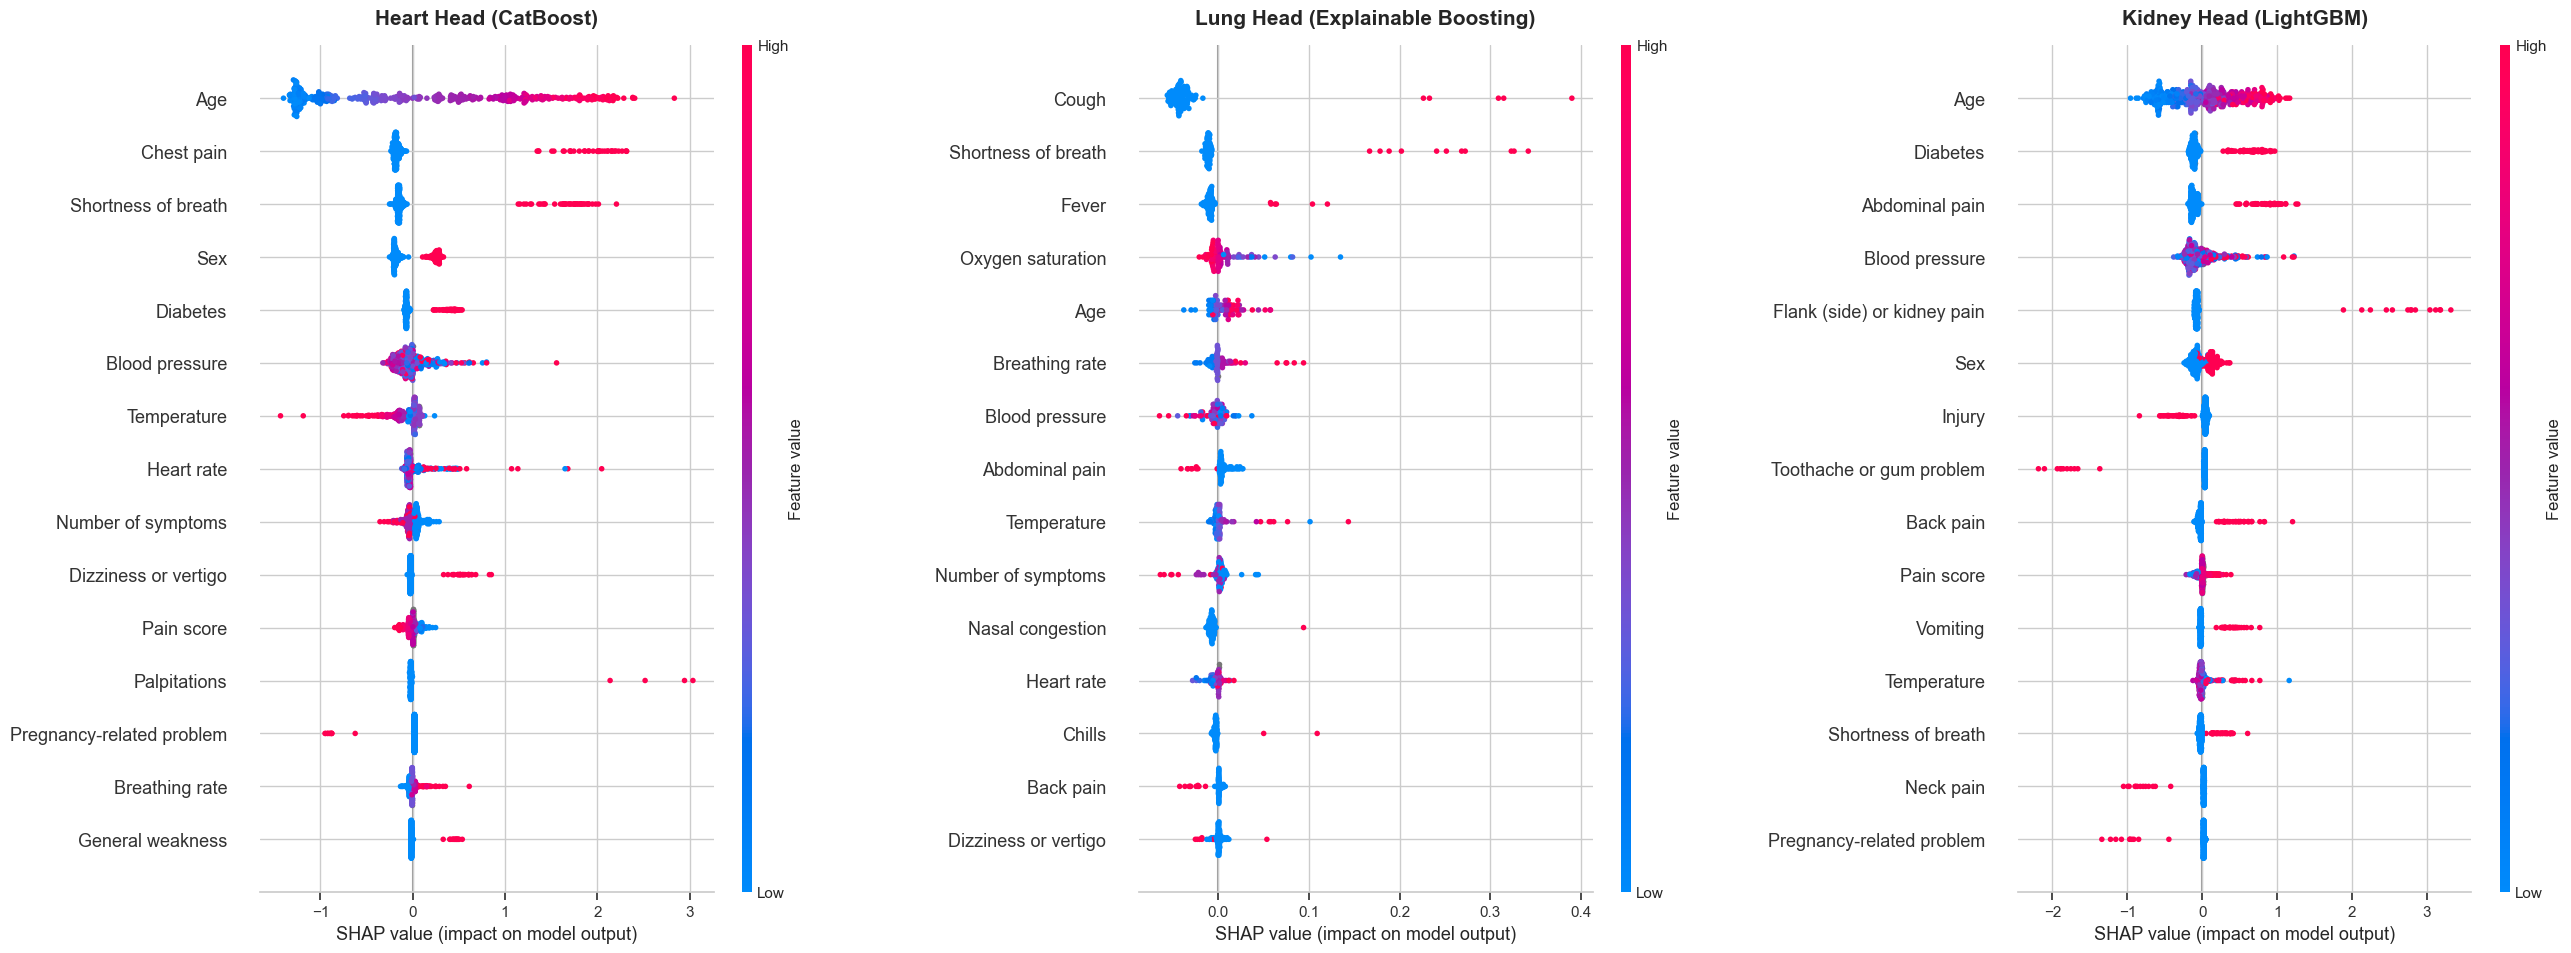

Top 10 inputs by mean |SHAP| per head:


,Heart,Lung,Kidney
0,Age,Cough,Age
1,Chest pain,Shortness of breath,Diabetes
2,Shortness of breath,Fever,Abdominal pain
3,Sex,Oxygen saturation,Blood pressure
4,Diabetes,Age,Flank (side) or kidney pain
5,Blood pressure,Breathing rate,Sex
6,Temperature,Blood pressure,Injury
7,Heart rate,Abdominal pain,Toothache or gum problem
8,Number of symptoms,Temperature,Back pain
9,Dizziness or vertigo,Number of symptoms,Pain score


In [38]:
import shap
import matplotlib.gridspec as gridspec

tree_models = (XGBClassifier, LGBMClassifier, CatBoostClassifier, RandomForestClassifier, DecisionTreeClassifier)
feature_groups = {
    'Temperature': ['temperature_f', 'fever'], 'Heart rate': ['heart_rate', 'fast_heart_rate'],
    'Breathing rate': ['respiratory_rate', 'fast_breathing'], 'Oxygen saturation': ['oxygen_saturation', 'low_oxygen'],
    'Blood pressure': ['systolic_bp', 'diastolic_bp', 'pulse_pressure', 'shock_index'], 'Pain score': ['pain_score'],
    'Age': ['age'], 'Number of symptoms': ['symptom_count'],
}
group_colour_source = {'Temperature': 'temperature_f', 'Heart rate': 'heart_rate', 'Breathing rate': 'respiratory_rate',
                       'Oxygen saturation': 'oxygen_saturation', 'Blood pressure': 'systolic_bp', 'Pain score': 'pain_score',
                       'Age': 'age', 'Number of symptoms': 'symptom_count'}
answer_labels = {'sex': 'Sex', 'injury_reason': 'Injury', 'diabetes': 'Diabetes'}
answer_rank = {'sex': {'Female': 0, 'Male': 1}, 'injury_reason': {'No': 0, 'Yes': 1}, 'diabetes': {'No': 0, 'Yes': 1}}

def source_column(feature):
    for group, members in feature_groups.items():
        if feature in members:
            return group
    for column, label in answer_labels.items():
        if feature.startswith(column + '_'):
            return label
    return SYMPTOM_LABELS.get(feature, feature)

def shap_components(organ):
    pipeline = fitted_models[organ][best_model_name[organ]]
    model_object = pipeline.named_steps['classifier']
    preprocessor = pipeline[:-1]
    feature_names = list(pipeline.named_steps['preprocess'].get_feature_names_out())
    return pipeline, model_object, preprocessor, feature_names

def build_shap_explainer(model_object, background, feature_names):
    if isinstance(model_object, tree_models):
        return shap.TreeExplainer(model_object)
    if isinstance(model_object, LogisticRegression):
        return shap.LinearExplainer(model_object, background)
    masker = shap.maskers.Independent(background, max_samples=len(background))
    return shap.Explainer(lambda data: model_object.predict_proba(data)[:, 1], masker, feature_names=feature_names)

def compute_shap_values(explainer, data):
    if isinstance(explainer, shap.explainers.PermutationExplainer):
        return explainer(data, max_evals=2 * data.shape[1] + 1)     # one forward + backward pass per visit
    return explainer(data)

def group_shap(values, feature_names):
    # (visits x encoded features) -> (visits x clinical inputs)
    return pd.DataFrame(values, columns=feature_names).T.groupby(source_column).sum().T

def group_colour_values(raw, columns):
    colours = {}
    for column in columns:
        if column in group_colour_source:
            colours[column] = raw[group_colour_source[column]]
        elif column in answer_labels.values():
            answer = next(c for c, label in answer_labels.items() if label == column)
            colours[column] = raw[answer].map(answer_rank[answer])
        else:
            colours[column] = raw[symptom_feature(column)]
    return pd.DataFrame(colours).astype(float)

shap_explainers, grouped_shap_by_head, grouped_colours_by_head = {}, {}, {}
for organ in ORGANS:
    pipeline, model_object, preprocessor, feature_names = shap_components(organ)
    fast = isinstance(model_object, tree_models + (LogisticRegression,))
    background = preprocessor.transform(X_train_aug.sample(100 if fast else 25, random_state=RANDOM_STATE))
    shap_explainers[organ] = build_shap_explainer(model_object, background, feature_names)
    n_explain = 500 if fast else 100
    X_explain = X_test.iloc[:n_explain]
    values = compute_shap_values(shap_explainers[organ], preprocessor.transform(X_explain)).values
    if values.ndim == 3:
        values = values[..., 1]
    grouped = group_shap(values, feature_names)
    grouped_shap_by_head[organ] = grouped
    grouped_colours_by_head[organ] = group_colour_values(add_custom_features(X_explain).reset_index(drop=True), grouped.columns)

fig = plt.figure(figsize=(30, 11), dpi=100)
gs = gridspec.GridSpec(1, 3, wspace=0.55)
for i, organ in enumerate(ORGANS):
    plt.sca(plt.subplot(gs[0, i]))
    grouped = grouped_shap_by_head[organ]
    shap.summary_plot(grouped.values, grouped_colours_by_head[organ].values, feature_names=list(grouped.columns),
                      max_display=15, show=False, plot_size=None)
    plt.title(f'{ORGAN_LABELS[organ]} Head ({best_model_name[organ]})', fontsize=15, fontweight='bold', pad=15)
save_figure("shap_analysis_macro_feature_importance.png")
plt.show()

shap_ranking = pd.DataFrame({ORGAN_LABELS[o]: grouped_shap_by_head[o].abs().mean().sort_values(ascending=False).head(10).index
                             for o in ORGANS})
print("Top 10 inputs by mean |SHAP| per head:")
display(shap_ranking)

* **Heart (CatBoost): age first, then chest pain and shortness of breath**, then male sex, diabetes and blood pressure. Palpitations push hardest when present (up to +3 log-odds), but they are rare, so they rank lower on average. A fever and a high pain score push *away* from the heart: febrile illness and severe pain usually have another cause.
* **Lung (EBM): cough and shortness of breath dominate**, then fever and low oxygen saturation. Abdominal and back pain push away. The EBM's values are in probability, so its SHAP scale differs from the other two heads.
* **Kidney (LightGBM) mixes two kinds of patient.** Flank or kidney pain has by far the largest effect when given (+2 to +3 log-odds: stones and infections). But age, diabetes and blood pressure rank above it on average, because they act on every visit (kidney failure and chronic kidney disease in older, diabetic patients). An injury, a toothache or neck pain push away.

### Permutation Importance
Global, model-agnostic importance. The **raw input columns** are shuffled one at a time and pushed through each full calibrated head, so shuffling `temperature_f` also scrambles the fever flag built from it. The score drop is measured in PR-AUC. Note that `symptom_1`, `symptom_2` and `symptom_3` are the first, second and third symptom *given*: shuffling `symptom_1` replaces every visit's main complaint with another visit's.

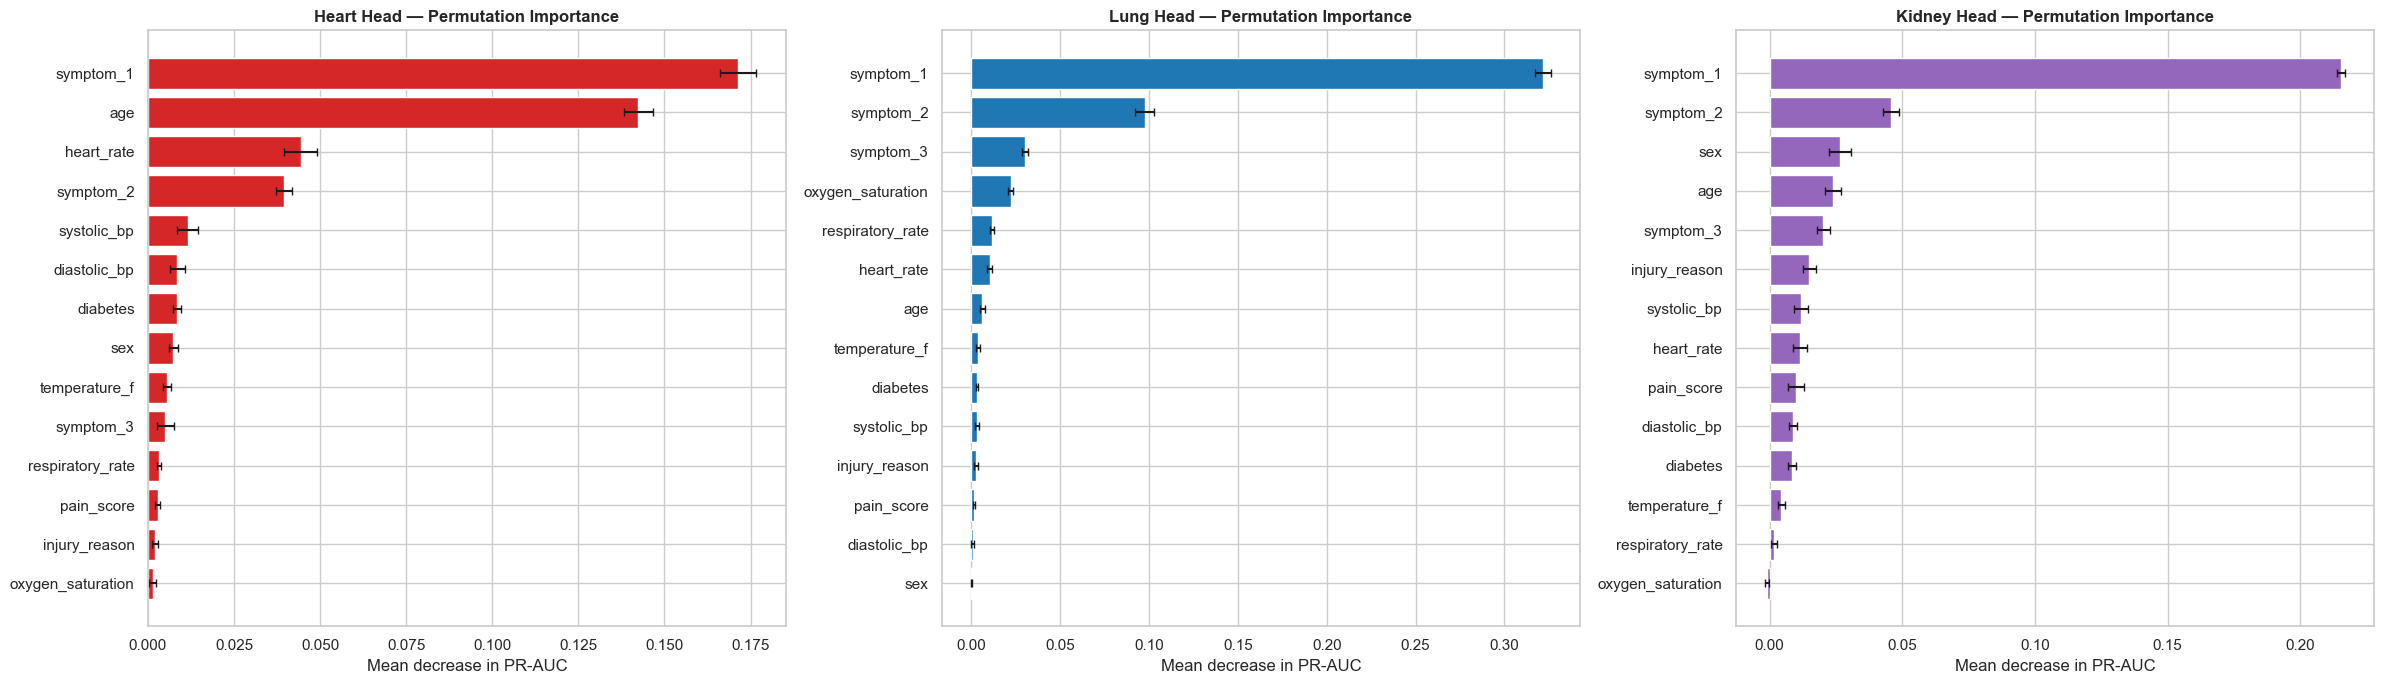

--- Permutation importance (drop in test PR-AUC when the column is shuffled), top 6 per head ---


Importance_Mean  Importance_Std
Head   Feature                                           
heart  symptom_1                   0.1712          0.0052
       age                         0.1424          0.0041
       heart_rate                  0.0444          0.0048
       symptom_2                   0.0396          0.0023
       systolic_bp                 0.0115          0.0030
       diastolic_bp                0.0086          0.0022
kidney symptom_1                   0.2153          0.0016
       symptom_2                   0.0457          0.0031
       sex                         0.0265          0.0040
       age                         0.0239          0.0030
       symptom_3                   0.0201          0.0025
       injury_reason               0.0149          0.0025
lung   symptom_1                   0.3216          0.0046
       symptom_2                   0.0977          0.0054
       symptom_3                   0.0302          0.0018
       oxygen_saturation           0.0222          0.0014
       respiratory_rate            0.0116          0.0013
       heart_rate                  0.0104          0.0015

In [39]:
from sklearn.inspection import permutation_importance

perm_rows = []
for organ in ORGANS:
    result = permutation_importance(calibrated_models[organ], X_test, Y_test[organ], scoring='average_precision',
                                    n_repeats=10, random_state=RANDOM_STATE, n_jobs=N_JOBS)
    for feature, mean, std in zip(X_test.columns, result.importances_mean, result.importances_std):
        perm_rows.append({'Head': organ, 'Feature': feature, 'Importance_Mean': mean, 'Importance_Std': std})
df_perm_importance = pd.DataFrame(perm_rows).sort_values(['Head', 'Importance_Mean'], ascending=[True, False])
df_perm_importance.to_csv(os.path.join(results_dir, 'permutational_feature_importance.csv'), index=False)

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
for ax, organ in zip(axes, ORGANS):
    table = df_perm_importance[df_perm_importance['Head'] == organ].iloc[::-1]
    ax.barh(table['Feature'], table['Importance_Mean'], xerr=table['Importance_Std'], color=ORGAN_COLORS[organ], capsize=3)
    ax.set_xlabel('Mean decrease in PR-AUC')
    ax.set_title(f'{ORGAN_LABELS[organ]} Head — Permutation Importance', fontweight='bold')
plt.tight_layout()
save_figure("permutation_importance.png")
plt.show()

print("--- Permutation importance (drop in test PR-AUC when the column is shuffled), top 6 per head ---")
display(df_perm_importance.groupby('Head').head(6).set_index(['Head', 'Feature']).round(4))

* **The first symptom is the most important input for every head.** Shuffling it costs 0.32 PR-AUC for the lung head, 0.22 for the kidney head and 0.17 for the heart head. Shuffling the second symptom costs 0.04–0.10, the third up to 0.03.
* **Age matters most for the heart (0.14)**, far more than for the kidney (0.02). Among the vital signs, heart rate helps the heart head (0.04), and oxygen saturation and breathing rate help the lung head (0.02 and 0.01). No measurement comes close to the first symptom, which is why the router works without them.

# Unsupervised Learning

### Dimensionality Reduction (PCA & t-SNE)

First, we prepare the data and reduce its dimensions to see whether visits group naturally before any clustering. Every visit goes through the same preprocessing as the models (median imputation, robust scaling, one-hot answers and the 128 symptom columns), fitted on everyone. PCA keeps the ten strongest directions; the clustering below runs on those ten components, because distances in 150 mostly-binary dimensions are close to uniform. t-SNE, DBSCAN and the silhouette scores are O(n²), so they use a stratified sample of 6,000 visits. PCA, GMM and K-Means use everyone.

* **PCA (Principal Component Analysis):** a linear projection that keeps the directions of largest variance.
* **t-SNE (T-distributed Stochastic Neighbor Embedding):** preserves local neighbourhoods, so visits with similar complaints sit together even when the structure is non-linear.

Unsupervised matrix: (184629, 149) | variance kept by 10 components: 83.2% (first two: 36.4%)


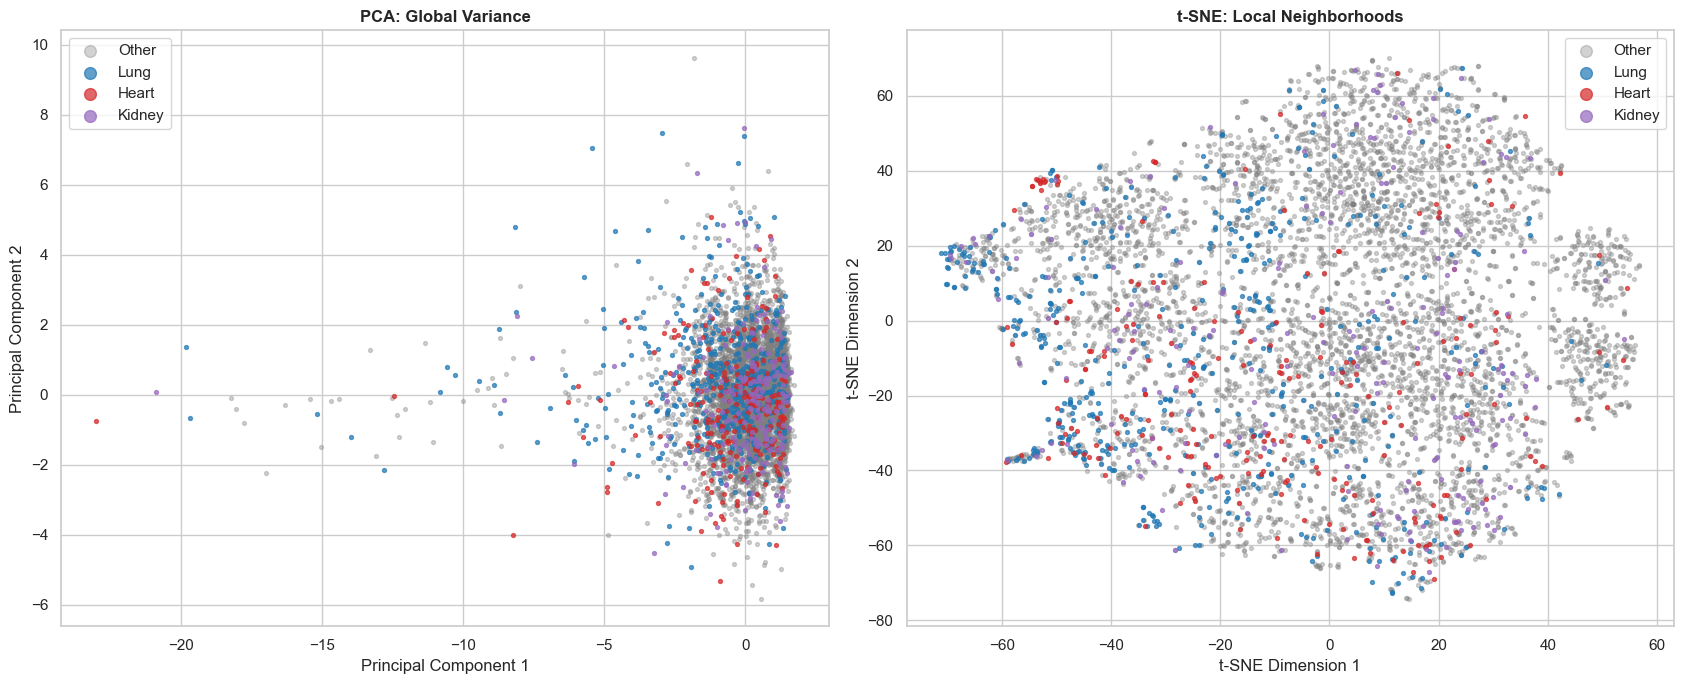

In [40]:
unsup_preprocessor = build_preprocessor()
X_unsup = unsup_preprocessor.fit_transform(add_custom_features(triage_data[RAW_INPUT_COLUMNS]))
labels_all = triage_data['primary_organ'].values

pca10 = PCA(n_components=10, random_state=RANDOM_STATE)
X_pca10 = pca10.fit_transform(X_unsup)
print(f"Unsupervised matrix: {X_unsup.shape} | variance kept by 10 components: {pca10.explained_variance_ratio_.sum():.1%} "
      f"(first two: {pca10.explained_variance_ratio_[:2].sum():.1%})")

sample_size = min(6000, int(0.8 * len(X_unsup)))
sample_idx, _ = train_test_split(np.arange(len(X_unsup)), train_size=sample_size, stratify=labels_all, random_state=RANDOM_STATE)
X_sample_unsup = X_pca10[sample_idx]
labels = labels_all[sample_idx]

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init='pca', learning_rate='auto')
tsne_result = tsne.fit_transform(X_unsup[sample_idx])
pca_result = X_pca10[sample_idx, :2]

fig, ax = plt.subplots(1, 2, figsize=(17, 7))
for axis, points, title in [(ax[0], pca_result, 'PCA: Global Variance'), (ax[1], tsne_result, 't-SNE: Local Neighborhoods')]:
    for route in ['other', 'lung', 'heart', 'kidney']:
        mask = labels == route
        axis.scatter(points[mask, 0], points[mask, 1], s=8, alpha=0.35 if route == 'other' else 0.7,
                     color=ORGAN_COLORS[route], label=ORGAN_LABELS[route])
    axis.set_title(title, fontweight='bold')
    axis.legend(markerscale=3)
ax[0].set_xlabel('Principal Component 1')
ax[0].set_ylabel('Principal Component 2')
ax[1].set_xlabel('t-SNE Dimension 1')
ax[1].set_ylabel('t-SNE Dimension 2')
plt.tight_layout()
save_figure("pca_tsne_analysis.png")
plt.show()

* **PCA is dominated by one measurement.** The ten components keep 83 % of the variance, and the first is almost entirely oxygen saturation (loading 0.98). Robust scaling divides by the interquartile range, and oxygen saturation's is only 2 points (97–99 %), so a saturation of 85 % sits far from everyone. The long tail to the left is the hypoxic visits, where lung and heart diagnoses concentrate.
* **t-SNE shows local pockets but no organ clusters.** Groups of lung visits (cough, wheezing) and small islands of heart visits form at the edges, while most kidney and heart visits sit inside the general cloud. The organ groups overlap in symptom space, which is why supervised heads are needed.

### Density and Probabilistic Clustering (DBSCAN & GMM)
DBSCAN (density-based) and a Gaussian Mixture Model (probabilistic) show how the visits separate under assumptions other than distance to a centre. DBSCAN's radius is set from the data: the 90th percentile of each sampled visit's distance to its 10th nearest neighbour. The GMM has four components, one per route (heart, lung, kidney, other), to see whether they appear on their own.

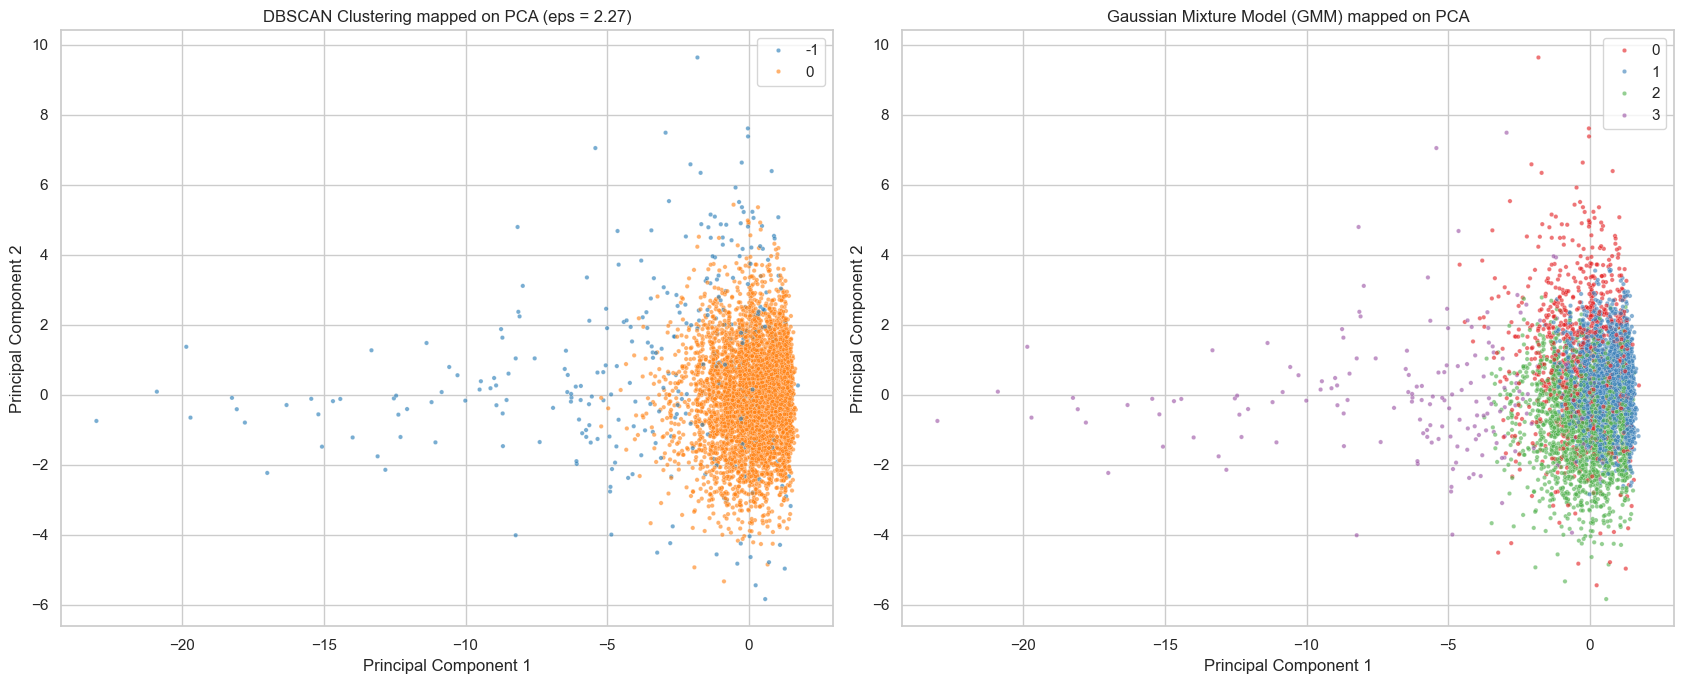

DBSCAN: 1 clusters, 5.1% of the sample labelled noise
--- Unsupervised Model Silhouette Scores (6,000-visit sample, 10 PCA components) ---
DBSCAN Silhouette Score: N/A (fewer than two clusters)


GMM Silhouette Score: 0.0734

Route mix of each GMM component (% of its visits):


primary_organ,heart,lung,kidney,other
row_0,,,,
0,7.2,18.8,4.8,69.2
1,0.8,5.1,2.5,91.6
2,6.4,7.9,4.4,81.4
3,10.4,31.4,3.8,54.4


In [41]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

neighbour_distances = NearestNeighbors(n_neighbors=10).fit(X_sample_unsup).kneighbors(X_sample_unsup)[0][:, -1]
dbscan_eps = float(np.percentile(neighbour_distances, 90))
dbscan = DBSCAN(eps=dbscan_eps, min_samples=10)
dbscan_clusters = dbscan.fit_predict(X_sample_unsup)

gmm = GaussianMixture(n_components=4, random_state=RANDOM_STATE)
gmm_all = gmm.fit(X_pca10).predict(X_pca10)
gmm_clusters = gmm_all[sample_idx]

fig, ax = plt.subplots(1, 2, figsize=(17, 7))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=dbscan_clusters, palette='tab10', ax=ax[0], alpha=0.6, s=10, legend='brief')
ax[0].set_title(f'DBSCAN Clustering mapped on PCA (eps = {dbscan_eps:.2f})')
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=gmm_clusters, palette='Set1', ax=ax[1], alpha=0.6, s=10)
ax[1].set_title('Gaussian Mixture Model (GMM) mapped on PCA')
for axis in ax:
    axis.set_xlabel('Principal Component 1')
    axis.set_ylabel('Principal Component 2')
plt.tight_layout()
save_figure("dbscan_gmm_analysis.png")
plt.show()

print(f"DBSCAN: {len(set(dbscan_clusters) - {-1})} clusters, {np.mean(dbscan_clusters == -1):.1%} of the sample labelled noise")
print("--- Unsupervised Model Silhouette Scores (6,000-visit sample, 10 PCA components) ---")
core = dbscan_clusters != -1
if len(set(dbscan_clusters[core])) > 1:
    print(f"DBSCAN Silhouette Score (clustered points): {silhouette_score(X_sample_unsup[core], dbscan_clusters[core]):.4f}")
else:
    print("DBSCAN Silhouette Score: N/A (fewer than two clusters)")
print(f"GMM Silhouette Score: {silhouette_score(X_sample_unsup, gmm_clusters):.4f}")
print("\nRoute mix of each GMM component (% of its visits):")
display((pd.crosstab(gmm_all, triage_data['primary_organ'], normalize='index') * 100).reindex(columns=ROUTES).round(1))

* **DBSCAN finds no density structure:** one cluster, and 5.1 % of the sample labelled noise.
* **The GMM finds a respiratory group without labels.** One of its four components is 31.4 % lung and 10.4 % heart (against 9.2 % and 4.3 % overall); another is 91.6 % other. The separation is weak (silhouette 0.073).

# KMeans Clustering

### Find Best Cluster Point

Finished k=2 | Score: 0.6062


Finished k=3 | Score: 0.1245


Finished k=4 | Score: 0.1310


Finished k=5 | Score: 0.1333


Finished k=6 | Score: 0.1222


Finished k=7 | Score: 0.1012


Finished k=8 | Score: 0.0886


Finished k=9 | Score: 0.0838


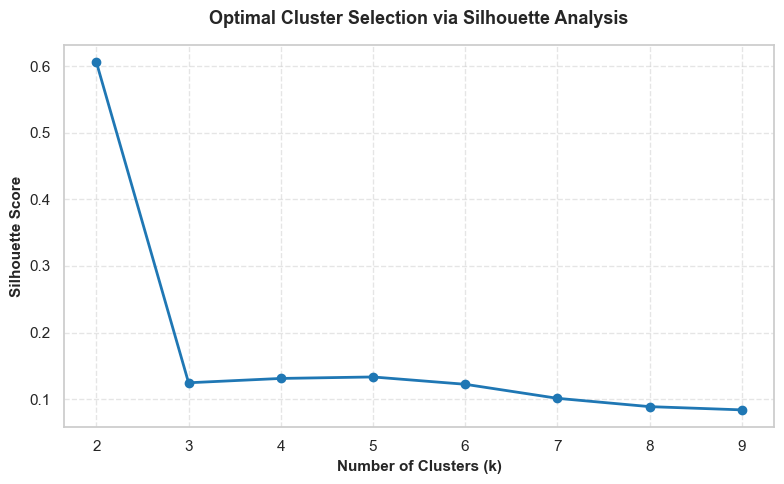

Best k by silhouette: 2


In [42]:
scores = []
cluster_range = range(2, 10)
for n in cluster_range:
    km = KMeans(n_clusters=n, random_state=RANDOM_STATE, n_init=10)
    cluster_labels = km.fit_predict(X_sample_unsup)
    score = silhouette_score(X_sample_unsup, cluster_labels)
    scores.append(score)
    print(f"Finished k={n} | Score: {score:.4f}")
best_k = list(cluster_range)[int(np.argmax(scores))]

plt.figure(figsize=(8, 5))
plt.plot(list(cluster_range), scores, marker='o', linewidth=2, color='#1f77b4', markersize=6)
plt.xlabel("Number of Clusters (k)", fontsize=11, fontweight='bold')
plt.ylabel("Silhouette Score", fontsize=11, fontweight='bold')
plt.title("Optimal Cluster Selection via Silhouette Analysis", fontsize=13, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print(f"Best k by silhouette: {best_k}")

### KMeans Clustering

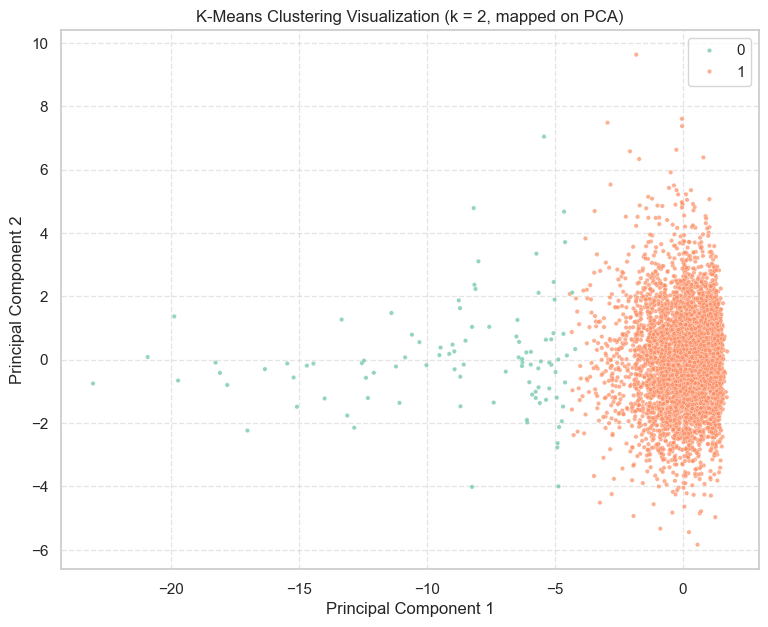

In [43]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
kmeans_clusters = kmeans.fit_predict(X_pca10)

plt.figure(figsize=(9, 7))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=kmeans_clusters[sample_idx], palette="Set2", alpha=0.7, s=10)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(f"K-Means Clustering Visualization (k = {best_k}, mapped on PCA)")
plt.grid(True, linestyle="--", alpha=0.5)
save_figure("kmeans_clustering.png")
plt.show()

### Cluster Profile

In [44]:
# Each cluster's size, organ-group rates, age and its most common symptoms
clustered = triage_data.assign(Cluster=kmeans_clusters)
profile = clustered.groupby('Cluster').agg(visits=('age', 'size'), age=('age', 'mean'),
                                           men=('sex', lambda s: (s == 'Male').mean() * 100),
                                           heart=('heart', lambda s: s.mean() * 100), lung=('lung', lambda s: s.mean() * 100),
                                           kidney=('kidney', lambda s: s.mean() * 100))
top_symptoms = {}
for cluster, group in clustered.groupby('Cluster'):
    counts = group[SYMPTOM_COLUMNS].stack().dropna().value_counts()
    top_symptoms[cluster] = ', '.join(f"{s} ({c / len(group):.0%})" for s, c in counts.head(4).items())
profile['top symptoms (share of visits)'] = pd.Series(top_symptoms)
print("--- Profile of Each Cluster (organ columns = % of the cluster's visits) ---")
display(profile.round(1))

--- Profile of Each Cluster (organ columns = % of the cluster's visits) ---


,visits,age,men,heart,lung,kidney,top symptoms (share of visits)
Cluster,,,,,,,
0,3263,57.8,45.0,11.6,32.1,5.1,"Shortness of breath (33%), Cough (10%), Chest ..."
1,181366,46.8,41.8,4.2,8.8,3.8,"Abdominal pain (12%), Chest pain (9%), Shortne..."


* **The best split (k = 2, silhouette 0.61) separates the low-oxygen visits.** Cluster 0 has 3,263 visits (1.8 %), every one with an oxygen saturation below 94 % (median 83 %). Their median age is 60 and a third breathe faster than 20 /min. The cluster is 32.1 % lung and 11.6 % heart, against 8.8 % and 4.2 % in the other 181,366 visits.
* **The high silhouette reflects the scaling of oxygen saturation (see PCA), not a natural division of patients.** For k = 3–9 the silhouette is only 0.08–0.13. Symptoms, not measurements, separate the organs, and they don't form clusters on their own.

# Anomaly Detection
DBSCAN finds noisy points only as a side effect; anomaly detectors are built to find extreme measurement profiles. They run on the measurements the router's gate will see (age, the seven vital signs, pulse pressure and the shock index) for a random sample of 20,000 visits: the One-Class SVM is O(n²).

* **One-Class SVM:** Learns a soft boundary around the majority of the data without assuming a specific distribution.
* **Elliptic Envelope:** Assumes the data is roughly Gaussian and draws an elliptical boundary from the data's variance.
* **Isolation Forest:** Isolates points by randomly selecting and splitting features; anomalies need fewer splits to isolate.
* **ECOD:** Flags outliers from the empirical cumulative distribution of each dimension, with no parameters to tune.
* **COPOD:** Models the joint distribution with copulas and flags points in the low-probability tails.
* **Autoencoder:** A neural network that learns to compress and reconstruct normal data; anomalies have high reconstruction errors.

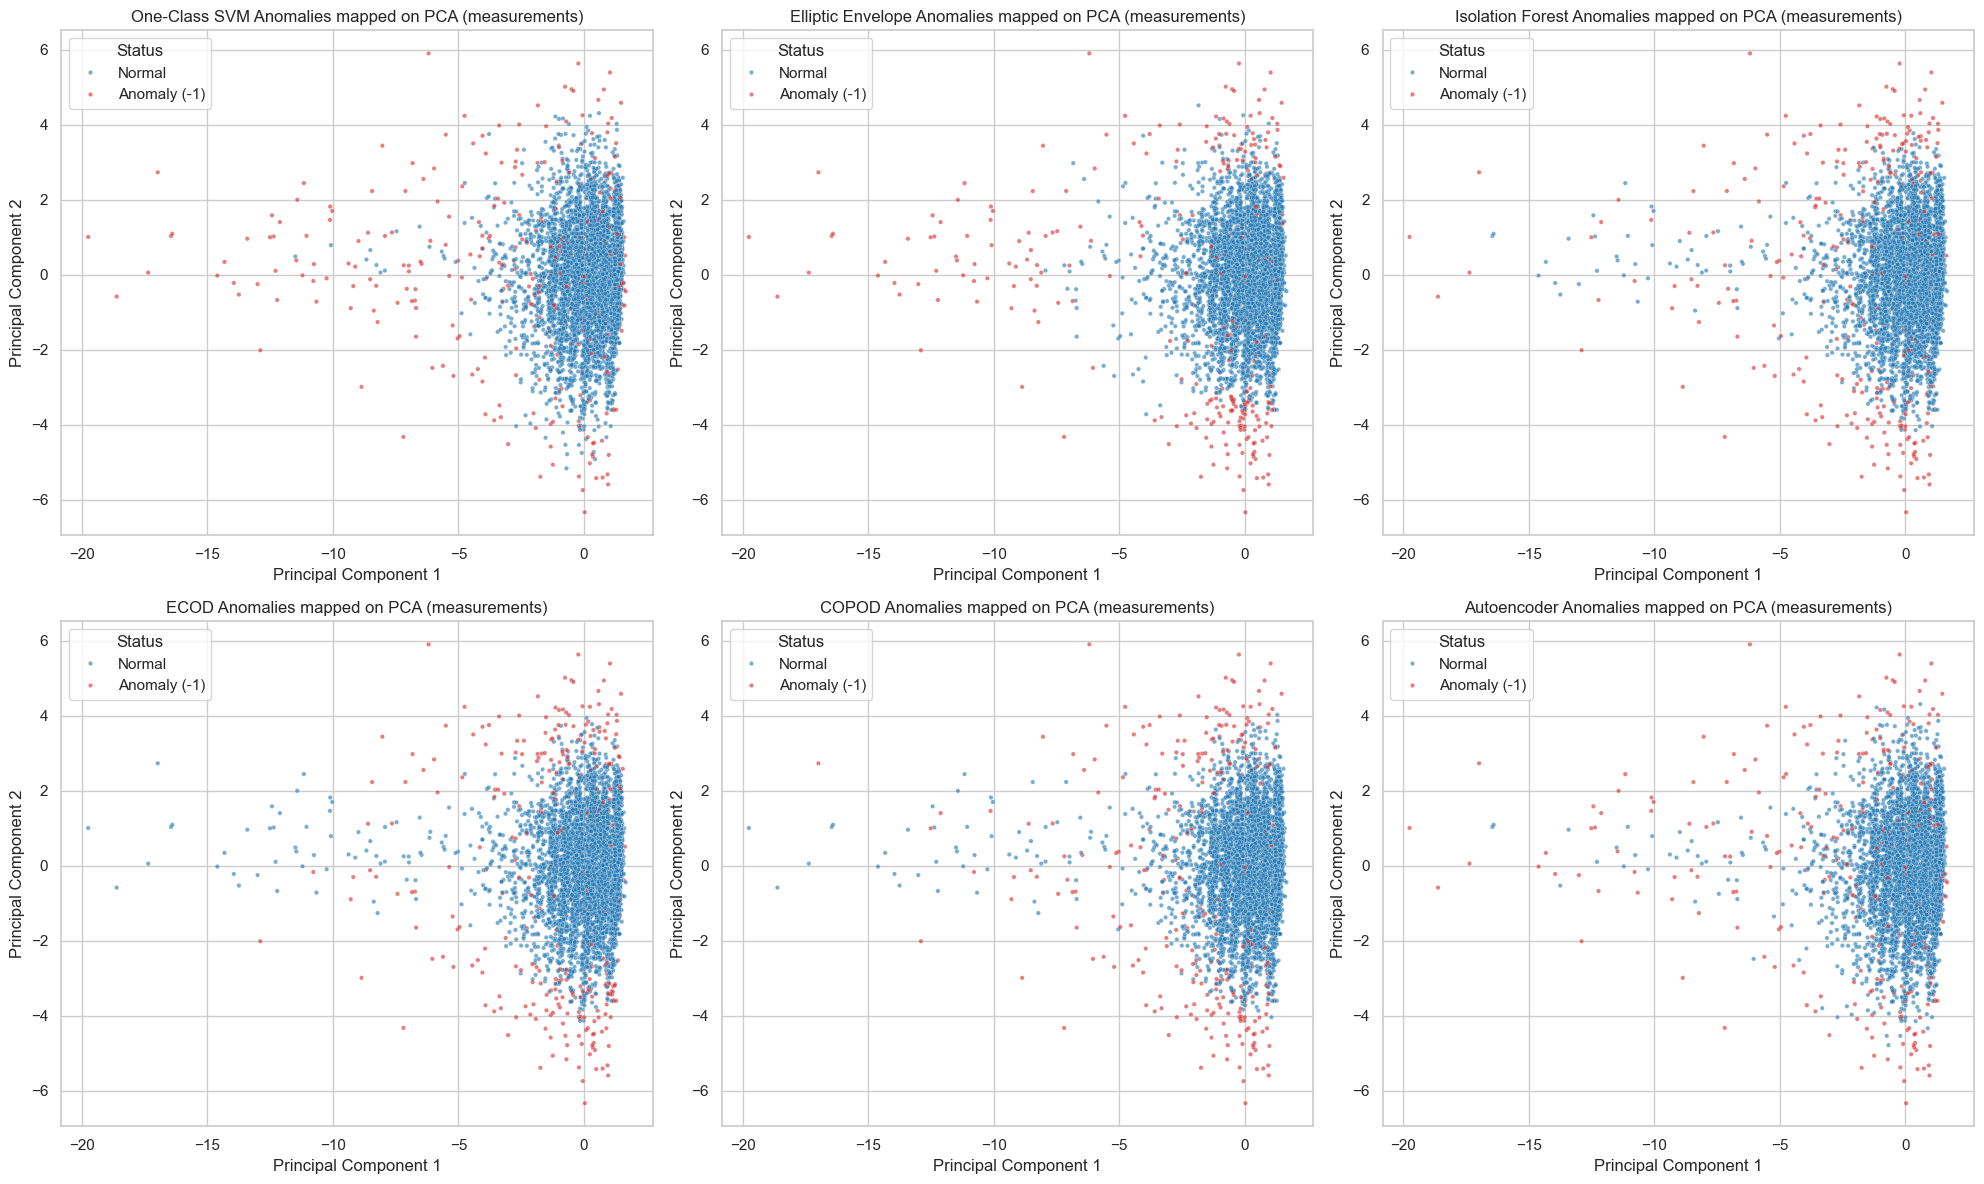

In [45]:
# On Colab: !pip install -q pyod
import io
import contextlib
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD
from pyod.models.auto_encoder import AutoEncoder

def silenced():
    # Swallow console output from libraries that print every epoch
    stack = contextlib.ExitStack()
    stack.enter_context(contextlib.redirect_stdout(io.StringIO()))
    stack.enter_context(contextlib.redirect_stderr(io.StringIO()))
    return stack

GATE_FEATURES = RAW_NUMERICAL_FEATURES + ['pulse_pressure', 'shock_index']
anomaly_idx = np.random.default_rng(RANDOM_STATE).choice(len(triage_data), size=min(20000, len(triage_data)), replace=False)
measurements = add_custom_features(triage_data[RAW_INPUT_COLUMNS].iloc[anomaly_idx])[GATE_FEATURES]
X_anomaly = RobustScaler().fit_transform(SimpleImputer(strategy='median').fit_transform(measurements))

anomaly_fraction = 0.05
with silenced():
    detectors = [
        ('One-Class SVM', OneClassSVM(nu=anomaly_fraction, kernel='rbf', gamma='scale').fit_predict(X_anomaly)),
        ('Elliptic Envelope', EllipticEnvelope(contamination=anomaly_fraction, random_state=RANDOM_STATE).fit_predict(X_anomaly)),
        ('Isolation Forest', IsolationForest(contamination=anomaly_fraction, random_state=RANDOM_STATE).fit_predict(X_anomaly)),
    ]
    for name, detector in [('ECOD', ECOD(contamination=anomaly_fraction)), ('COPOD', COPOD(contamination=anomaly_fraction)),
                           ('Autoencoder', AutoEncoder(contamination=anomaly_fraction, random_state=RANDOM_STATE, verbose=0))]:
        detector.fit(X_anomaly)
        detectors.append((name, np.where(detector.labels_ == 1, -1, 1)))    # PyOD: 1 = anomaly -> -1 like scikit-learn
keep_workers_light()      # the autoencoder imported torch

anomaly_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_anomaly)
plot_idx = np.random.default_rng(0).choice(len(X_anomaly), size=min(6000, len(X_anomaly)), replace=False)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for ax, (title, flags) in zip(axes.flat, detectors):
    sns.scatterplot(x=anomaly_pca[plot_idx, 0], y=anomaly_pca[plot_idx, 1], hue=flags[plot_idx], hue_order=[1, -1],
                    palette={1: '#1f77b4', -1: '#d62728'}, ax=ax, alpha=0.6, s=10)
    ax.set_title(f'{title} Anomalies mapped on PCA (measurements)')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=['Normal', 'Anomaly (-1)'], title='Status')
plt.tight_layout()
save_figure("anomaly_detection_models.png")
plt.show()

In [46]:
sample_labels = triage_data.iloc[anomaly_idx]
any_organ = sample_labels[ORGANS].any(axis=1).values
anomaly_counts = []
for title, flags in detectors:
    anomalous = flags == -1
    anomaly_counts.append({'Model': title, 'Anomalies Detected': int(anomalous.sum()), 'Anomaly %': f"{anomalous.mean():.2%}",
                           **{f'{ORGAN_LABELS[o]} rate among anomalies': f"{sample_labels[o].values[anomalous].mean():.1%}" for o in ORGANS},
                           'Any organ among anomalies': f"{any_organ[anomalous].mean():.1%}"})
print("=== Anomaly Detection Counts (20,000-visit sample) ===")
display(pd.DataFrame(anomaly_counts).set_index('Model'))

times_flagged = (np.vstack([flags for _, flags in detectors]) == -1).sum(axis=0)
print("\n=== Anomaly Consensus ===")
print(f"Visits flagged by at least 1 model: {(times_flagged >= 1).sum()}")
print(f"Visits flagged by majority (>= 3 models): {(times_flagged >= 3).sum()}")
print(f"Visits flagged by ALL 6 models (Strict Consensus): {(times_flagged == 6).sum()}")
print(f"\nAny-organ rate overall: {any_organ.mean():.1%} | among strict-consensus anomalies: {any_organ[times_flagged == 6].mean():.1%}")
print("\nMedian measurements, strict-consensus anomalies vs everyone:")
display(pd.DataFrame({'Everyone': measurements.median(), 'Strict consensus': measurements[times_flagged == 6].median()}).round(1))

=== Anomaly Detection Counts (20,000-visit sample) ===


,Anomalies Detected,Anomaly %,Heart rate among anomalies,Lung rate among anomalies,Kidney rate among anomalies,Any organ among anomalies
Model,,,,,,
One-Class SVM,1005,5.03%,13.4%,22.7%,6.2%,38.4%
Elliptic Envelope,1000,5.00%,10.2%,17.4%,5.5%,30.2%
Isolation Forest,1000,5.00%,14.7%,25.1%,6.7%,42.0%
ECOD,1000,5.00%,14.1%,19.8%,7.5%,37.1%
COPOD,1000,5.00%,16.3%,28.1%,7.5%,46.8%
Autoencoder,1000,5.00%,13.7%,19.9%,7.0%,36.0%



=== Anomaly Consensus ===
Visits flagged by at least 1 model: 1993
Visits flagged by majority (>= 3 models): 1063
Visits flagged by ALL 6 models (Strict Consensus): 258

Any-organ rate overall: 16.7% | among strict-consensus anomalies: 46.5%

Median measurements, strict-consensus anomalies vs everyone:


,Everyone,Strict consensus
age,45.0,64.0
temperature_f,98.1,98.1
heart_rate,85.0,101.0
respiratory_rate,18.0,20.0
systolic_bp,134.0,141.5
diastolic_bp,79.0,76.5
oxygen_saturation,98.0,96.0
pain_score,6.0,4.0
pulse_pressure,54.0,59.0
shock_index,0.6,0.8


* **The measurement anomalies are sick patients, not errors.** 30–47 % of each detector's anomalies have a heart, lung or kidney diagnosis (16.7 % overall), and so do 46.5 % of the 258 visits flagged by all six detectors. Those are older (median 64 vs 45), with faster pulses (101 vs 85), lower oxygen (96 vs 98 %) and a higher shock index (0.8 vs 0.6). The impossible readings were already removed at build time.
* **Consequence for the gate:** an anomaly gate on vital signs withholds sick patients more often than healthy ones. The next section measures how much, and the router's message for a withheld patient is to check the values and, if they are real, to seek urgent care.

# Cascade Architecture

### Symptom Triage Cascade Architecture
The router is the first layer of the whole system, and it is itself a two-stage cascade:

1. **Stage 1 (Anomaly Gate):** an **Isolation Forest** on age and the vital signs, fitted on the training visits as recorded (1 % contamination), flags impossible or extreme measurements (typing errors, or readings that need urgent care rather than an app). Those visits are withheld for review instead of being routed. A patient who gives no vital signs is scored with typical values and passes.
2. **Stage 2 (Routing):** the three **calibrated heads** give P(heart), P(lung) and P(kidney). The patient is routed to every organ at or above its cost-optimal threshold, first to the organ furthest above its threshold; below all three means **other**. Each routed organ gets a SHAP explanation of what drove it.

**Next layer:** a routed patient goes to that organ's tabular model (heart disease, COPD or CKD risk) and, with a scan or printout, its image model (ECG, chest X-ray, kidney CT). These use different datasets, so the combined accuracy of the layers cannot be measured end to end here.

In [47]:
# Stage 1 gate: age and vital signs only, fitted on the TRAINING set as recorded (no dropout)
anomaly_gate = Pipeline(steps=[
    ('engineering', FunctionTransformer(add_custom_features)),
    ('select', ColumnTransformer([('numeric', 'passthrough', GATE_FEATURES)])),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('detector', IsolationForest(n_estimators=200, contamination=0.01, random_state=RANDOM_STATE))
])
anomaly_gate.fit(X_train)

gate_flags = anomaly_gate.predict(X_test) == -1
gate_flags_no_vitals = anomaly_gate.predict(X_test_no_vitals) == -1
print(f"Test visits withheld by the gate: {gate_flags.sum()} ({gate_flags.mean():.2%})")
for organ in ORGANS:
    print(f"  among {organ} visits : {gate_flags[Y_test[organ].values == 1].mean():.2%}")
print(f"  among other visits : {gate_flags[Y_test.sum(axis=1).values == 0].mean():.2%}")
print(f"Withheld when scored without vital signs: {gate_flags_no_vitals.sum()} ({gate_flags_no_vitals.mean():.2%})")

Test visits withheld by the gate: 398 (1.08%)
  among heart visits : 4.45%
  among lung visits : 3.77%
  among kidney visits : 2.74%
  among other visits : 0.61%
Withheld when scored without vital signs: 0 (0.00%)


In [48]:
NEXT_STEP = {'heart': 'heart disease risk model -> ECG model', 'lung': 'COPD risk model -> chest X-ray model',
             'kidney': 'CKD risk model -> kidney CT model'}

def describe_input(column, row):
    # The patient's own value for a clinical input, in clinical units
    if column == 'Blood pressure':
        return 'unknown' if pd.isna(row['systolic_bp']) else f"{row['systolic_bp']:.0f}/{row['diastolic_bp']:.0f} mmHg"
    if column in group_colour_source:
        value = row[group_colour_source[column]]
        return 'unknown (typical used)' if pd.isna(value) else f"{value:.4g}"
    if column in answer_labels.values():
        answer = next(c for c, label in answer_labels.items() if label == column)
        return str(row[answer])
    return 'given' if row[symptom_feature(column)] == 1 else 'not given'

def triage_evaluation(visits, models=None, gate=None, thresholds=None, visit_names=None, explain=True):
    models = models or calibrated_models
    gate = gate if gate is not None else anomaly_gate
    thresholds = thresholds or best_threshold

    # --- STAGE 1: Anomaly Detection ---
    withheld = gate.predict(visits) == -1

    # --- STAGE 2: Calibrated probabilities for the three heads, then routing ---
    probas = pd.DataFrame({organ: models[organ].predict_proba(visits)[:, 1] for organ in ORGANS}, index=visits.index)
    flags, primary = route_visits(probas, thresholds)
    engineered = add_custom_features(visits).reset_index(drop=True)

    for i in range(len(visits)):
        name = visit_names[i] if visit_names else f"Visit {i + 1}"
        row = visits.iloc[i]
        given = [s for s in row[SYMPTOM_COLUMNS] if isinstance(s, str)]
        print(f"=== Triage for {name} ===")
        print(f"Age {row['age']:.0f}, {row['sex']} | symptoms: {', '.join(given)}")

        if withheld[i]:
            print("🚨 STAGE 1 CASCADE REJECTION: vital signs outside the usual range.")
            print("Action: not routed. Check the values; if they are real, the patient needs urgent care, not an app.\n")
            continue

        for organ in ORGANS:
            mark = '→ ROUTE' if flags.iloc[i][organ] else ''
            print(f"  {ORGAN_LABELS[organ]:7s} {probas.iloc[i][organ] * 100:6.2f}%  (threshold {thresholds[organ] * 100:5.2f}%) {mark}")
        routes = [o for o in sorted(ORGANS, key=lambda o: -probas.iloc[i][o] / thresholds[o]) if flags.iloc[i][o]]
        if routes:
            print("Decision: " + " + ".join(ORGAN_LABELS[o] for o in routes))
            for organ in routes:
                print(f"  next: {NEXT_STEP[organ]}")
        else:
            print("Decision: Other — no heart, lung or kidney signal; general care (see a doctor if symptoms persist)")

        if explain:
            explained = routes or [max(ORGANS, key=lambda o: probas.iloc[i][o] / thresholds[o])]
            for organ in explained:
                _, _, preprocessor, feature_names = shap_components(organ)
                values = compute_shap_values(shap_explainers[organ], preprocessor.transform(visits.iloc[[i]]))
                contributions = group_shap(np.atleast_2d(values.values if values.values.ndim == 2 else values.values[..., 1]), feature_names).iloc[0]
                ranked = contributions.loc[contributions.abs().sort_values(ascending=False).index]
                print(f"  {ORGAN_LABELS[organ]} — top contributing inputs:")
                for rank, (column, value) in enumerate(ranked.head(4).items(), start=1):
                    print(f"    {rank}. {column} = {describe_input(column, engineered.iloc[i])} ({value:+.2f})")
            organ = explained[0]
            _, _, preprocessor, feature_names = shap_components(organ)
            values = compute_shap_values(shap_explainers[organ], preprocessor.transform(visits.iloc[[i]]))
            contributions = group_shap(values.values if values.values.ndim == 2 else values.values[..., 1], feature_names).iloc[0]
            ranked = contributions.loc[contributions.abs().sort_values(ascending=False).index]
            base = np.ravel(values.base_values)[0] if np.ndim(values.base_values) else values.base_values
            explanation = shap.Explanation(values=ranked.values, base_values=base,
                                           feature_names=[f"{c} = {describe_input(c, engineered.iloc[i])}" for c in ranked.index])
            plt.figure(figsize=(8, 5), dpi=100)
            shap.plots.waterfall(explanation, max_display=8, show=False)
            plt.title(f'SHAP Waterfall — {ORGAN_LABELS[organ]} head, {name}', fontsize=12, fontweight='bold')
            plt.tight_layout()
            plt.show()
        print("\n" + "=" * 60 + "\n")

The evaluation function embeds SHAP into the routing decision: for every routed organ (or the closest organ when the answer is "other") it prints the inputs that pushed that head's probability most, in clinical units, and draws a waterfall plot for the first route.

# AI Prediction Test

=== Triage for Visit A (index 11101; diagnosis: Other [569.71]) ===
Age 25, Male | symptoms: Abdominal pain, Diarrhea
  Heart     0.23%  (threshold 15.09%) 
  Lung      1.48%  (threshold 16.17%) 
  Kidney    4.71%  (threshold 15.44%) 
Decision: Other — no heart, lung or kidney signal; general care (see a doctor if symptoms persist)
  Kidney — top contributing inputs:
    1. Abdominal pain = given (+1.06)
    2. Age = 25 (-0.56)
    3. Breathing rate = 24 (+0.26)
    4. Sex = Male (+0.11)


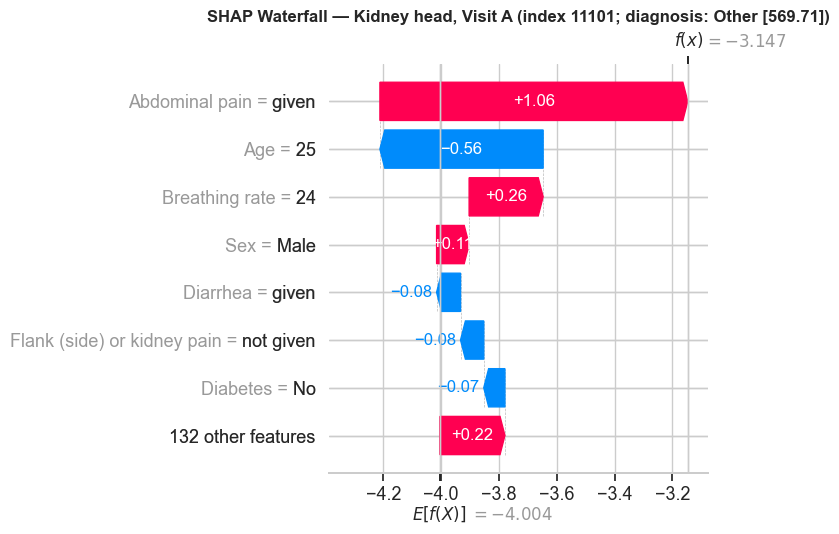



=== Triage for Visit B (index 141453; diagnosis: Lung [R06.0, J45.3, H81]) ===
Age 38, Female | symptoms: Shortness of breath, Chest pressure or tightness, Tiredness or exhaustion
  Heart     5.10%  (threshold 15.09%) 
  Lung     34.24%  (threshold 16.17%) → ROUTE
  Kidney    0.85%  (threshold 15.44%) 
Decision: Lung
  next: COPD risk model -> chest X-ray model
  Lung — top contributing inputs:
    1. Shortness of breath = given (+0.20)
    2. Breathing rate = 25 (+0.07)
    3. Number of symptoms = 3 (-0.06)
    4. Cough = not given (-0.04)


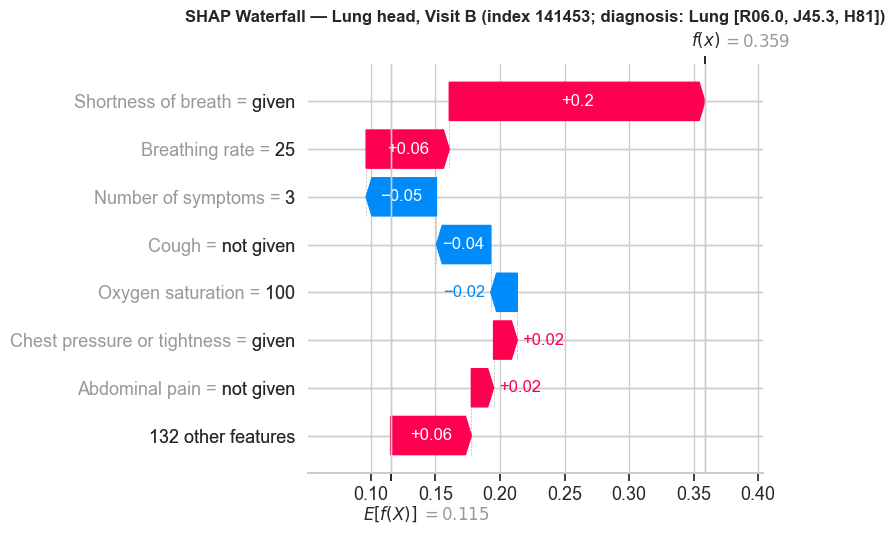



=== Triage for Visit C (index 49606; diagnosis: Other [844.9]) ===
Age 20, Female | symptoms: Knee pain or swelling
  Heart     0.05%  (threshold 15.09%) 
  Lung      1.30%  (threshold 16.17%) 
  Kidney    0.13%  (threshold 15.44%) 
Decision: Other — no heart, lung or kidney signal; general care (see a doctor if symptoms persist)
  Lung — top contributing inputs:
    1. Knee pain or swelling = given (-0.04)
    2. Cough = not given (-0.03)
    3. Shortness of breath = not given (-0.01)
    4. Age = 20 (-0.01)


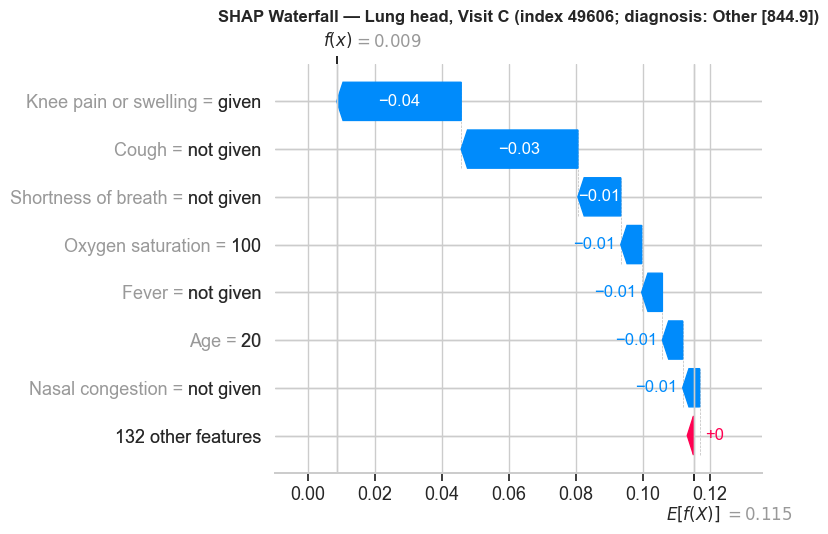

In [49]:
# The first three visits of the test set
sample_visits = X_test.head(3)
sample_names = []
for i, idx in enumerate(sample_visits.index):
    truth = [ORGAN_LABELS[o] for o in ORGANS if Y_test.loc[idx, o]] or ['Other']
    codes = ', '.join(c for c in triage_data.loc[idx, ['diagnosis_1', 'diagnosis_2', 'diagnosis_3']] if isinstance(c, str))
    sample_names.append(f"Visit {chr(65 + i)} (index {idx}; diagnosis: {' + '.join(truth)} [{codes}])")

triage_evaluation(sample_visits, visit_names=sample_names, explain=True)

# Save and Test Final Model (Joblib)
We save the three calibrated heads, the Stage 1 anomaly gate, a `metadata.json` (thresholds, models, feature lists, the symptom vocabulary, test metrics with and without vital signs) and `reference_profile.json` (the typical patient the explanations of `src.predict` compare with) to `models/`, then reload them and test with mock patients.

*Note:* the pipelines reference `add_custom_features`, defined in this notebook. `common/artifacts.py` points that name at `src.data.add_custom_features` while loading, so `src.predict` loads these files as they are, and `python -m src.train` rebuilds the same artifacts from the command line.

In [50]:
model_filenames = {organ: os.path.join(models_dir, f"triage_{organ}_calibrated_model.joblib") for organ in ORGANS}
gate_filename = os.path.join(models_dir, "triage_anomaly_gate.joblib")
metadata_filename = os.path.join(models_dir, "metadata.json")
reference_filename = os.path.join(models_dir, "reference_profile.json")

for organ in ORGANS:
    joblib.dump(calibrated_models[organ], model_filenames[organ])
joblib.dump(anomaly_gate, gate_filename)

def head_test_metrics(organ, probas):
    m = operating_metrics(Y_test[organ], probas, best_threshold[organ])
    return {'roc_auc': m['ROC-AUC'], 'pr_auc': m['PR-AUC'], 'brier_score': brier_score_loss(Y_test[organ], probas),
            'recall_at_threshold': m['Recall'], 'precision_at_threshold': m['Precision'], 'specificity_at_threshold': m['Specificity']}

metadata = {
    'dataset': 'TRIAGE_NHAMCS.csv (CDC NHAMCS emergency-department visits 2010-2022, adults 18+ with a symptom and a diagnosis)',
    'task': 'layer 1 router: which organ modules (heart, lung, kidney) should see a patient, from symptoms',
    'targets': {'heart': 'ischemic heart disease, arrhythmia, heart failure, other heart disease (first three ED diagnoses)',
                'lung': 'influenza, pneumonia, lower respiratory infection, COPD, asthma, other lung disease, lung cancer, TB, COVID-19',
                'kidney': 'kidney failure / CKD, kidney infection, stones and renal colic, other kidney disorders, kidney cancer, dialysis'},
    'selection_rule': 'one-standard-error rule on 5-fold CV PR-AUC, per head',
    'routing_rule': 'route to every organ with probability >= its threshold; first route = highest probability / threshold; none = other',
    'vital_dropout': VITAL_DROPOUT,
    'cost_weights': {'false_negative': FN_COST, 'false_positive': FP_COST},
    'heads': {organ: {
        'best_model': best_model_name[organ],
        'optimal_threshold': best_threshold[organ],
        'cv_pr_auc': {m: {'mean': cv_summary[organ][m]['CV PR-AUC'], 'se': cv_summary[organ][m]['CV SE']} for m in cv_summary[organ]},
        'within_one_se': within_one_se[organ],
        'prevalence': float(Y[organ].mean()),
        'test_metrics': head_test_metrics(organ, calib_probas[organ]),
        'test_metrics_no_vital_signs': head_test_metrics(organ, calib_probas_no_vitals[organ]),
        'bootstrap_confidence_intervals': confidence_intervals[organ],
    } for organ in ORGANS},
    'routing_test_metrics': {inputs: {k: float(v) for k, v in m.items()} for inputs, m in routing.items()},
    'raw_input_columns': RAW_INPUT_COLUMNS,
    'numerical_features': NUMERICAL_FEATURES,
    'categorical_features': ONE_HOT_FEATURES + SYMPTOM_COLUMNS,
    'gate_features': GATE_FEATURES,
    'symptoms': SYMPTOMS,
    'training_rows': len(X_train), 'test_rows': len(X_test),
}
with open(metadata_filename, 'w') as f:
    json.dump(metadata, f, indent=2, default=float)

# The typical patient the explanations compare with: median measurements, most common answers, no symptom
reference = {c: float(X_train[c].median()) for c in RAW_NUMERICAL_FEATURES}
reference.update({c: X_train[c].mode().iloc[0] for c in ONE_HOT_FEATURES})
reference.update({c: None for c in SYMPTOM_COLUMNS})
with open(reference_filename, 'w') as f:
    json.dump({'source': 'training split (80 %) of data/TRIAGE_NHAMCS.csv, as recorded; symptoms: none', 'values': reference}, f, indent=2)

for organ in ORGANS:
    print(f"[SAVED] {ORGAN_LABELS[organ]:6s} head   -> {model_filenames[organ]}")
print(f"[SAVED] Anomaly Gate  -> {gate_filename}")
print(f"[SAVED] Metadata      -> {metadata_filename}")
print(f"[SAVED] Reference     -> {reference_filename}")

[SAVED] Heart  head   -> E:\Disease-Risk-Prediction\triage\tabular\models\triage_heart_calibrated_model.joblib
[SAVED] Lung   head   -> E:\Disease-Risk-Prediction\triage\tabular\models\triage_lung_calibrated_model.joblib
[SAVED] Kidney head   -> E:\Disease-Risk-Prediction\triage\tabular\models\triage_kidney_calibrated_model.joblib
[SAVED] Anomaly Gate  -> E:\Disease-Risk-Prediction\triage\tabular\models\triage_anomaly_gate.joblib
[SAVED] Metadata      -> E:\Disease-Risk-Prediction\triage\tabular\models\metadata.json
[SAVED] Reference     -> E:\Disease-Risk-Prediction\triage\tabular\models\reference_profile.json


[LOADED] Successfully loaded the three heads and the gate

=== Loaded Joblib Model Test ===
=== Triage for Patient A (heart-like mock) ===
Age 64, Male | symptoms: Chest pain, Shortness of breath, Excessive sweating
  Heart    44.55%  (threshold 15.09%) → ROUTE
  Lung     18.61%  (threshold 16.17%) → ROUTE
  Kidney    5.47%  (threshold 15.44%) 
Decision: Heart + Lung
  next: heart disease risk model -> ECG model
  next: COPD risk model -> chest X-ray model
  Heart — top contributing inputs:
    1. Chest pain = given (+1.37)
    2. Shortness of breath = given (+1.12)
    3. Excessive sweating = given (+0.97)
    4. Age = 64 (+0.90)
  Lung — top contributing inputs:
    1. Shortness of breath = given (+0.17)
    2. Number of symptoms = 3 (-0.06)
    3. Oxygen saturation = 95 (+0.05)
    4. Cough = not given (-0.04)


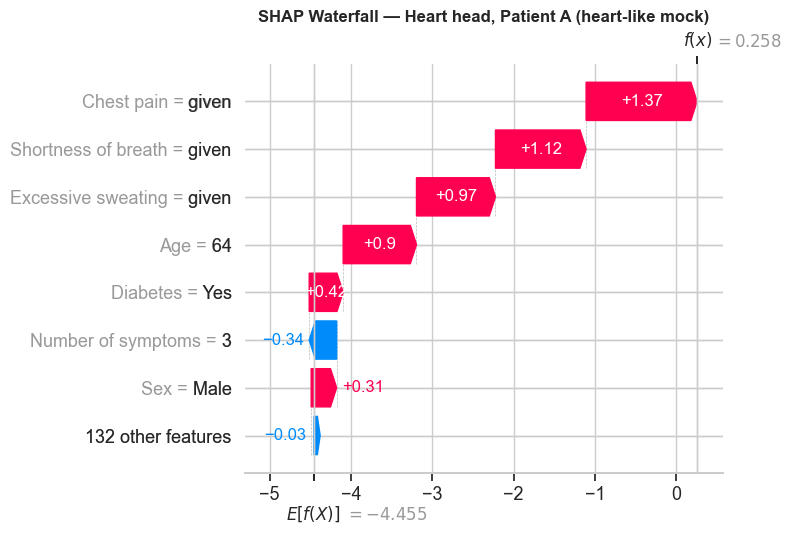



=== Triage for Patient B (lung-like mock) ===
Age 71, Female | symptoms: Cough, Fever, Shortness of breath
  Heart     9.28%  (threshold 15.09%) 
  Lung     78.09%  (threshold 16.17%) → ROUTE
  Kidney    3.61%  (threshold 15.44%) 
Decision: Lung
  next: COPD risk model -> chest X-ray model
  Lung — top contributing inputs:
    1. Shortness of breath = given (+0.25)
    2. Cough = given (+0.25)
    3. Fever = given (+0.12)
    4. Age = 71 (+0.07)


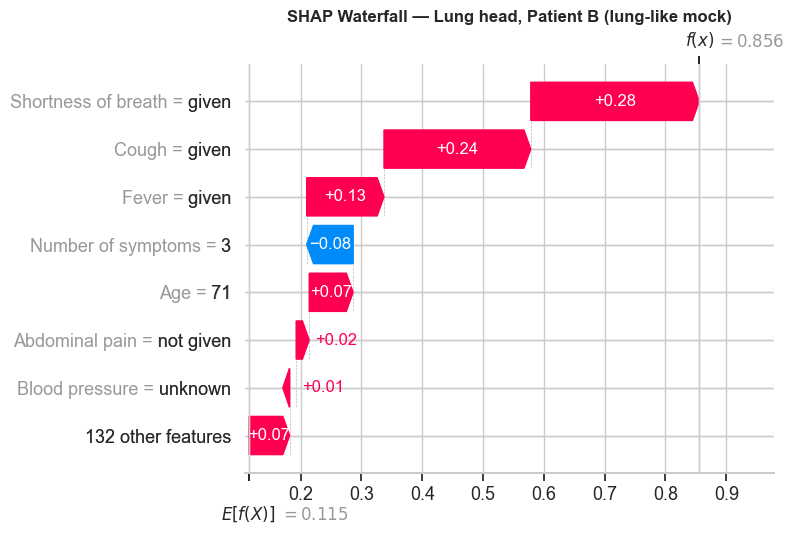



=== Triage for Patient C (kidney-like mock) ===
Age 45, Male | symptoms: Flank (side) or kidney pain, Blood in urine, Vomiting
  Heart     0.50%  (threshold 15.09%) 
  Lung      1.34%  (threshold 16.17%) 
  Kidney   60.79%  (threshold 15.44%) → ROUTE
Decision: Kidney
  next: CKD risk model -> kidney CT model
  Kidney — top contributing inputs:
    1. Flank (side) or kidney pain = given (+2.28)
    2. Blood in urine = given (+1.12)
    3. Vomiting = given (+0.34)
    4. Sex = Male (+0.21)


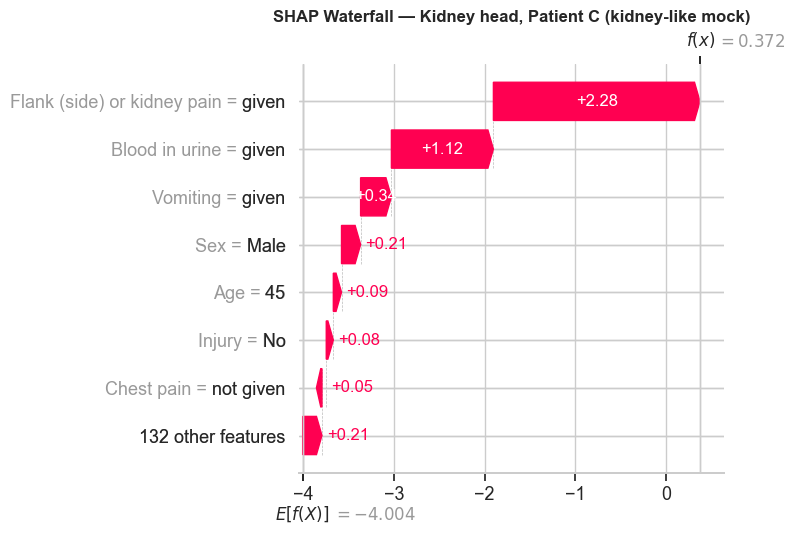



=== Triage for Patient D (other mock) ===
Age 29, Female | symptoms: Headache, Nausea
  Heart     0.18%  (threshold 15.09%) 
  Lung      2.39%  (threshold 16.17%) 
  Kidney    0.49%  (threshold 15.44%) 
Decision: Other — no heart, lung or kidney signal; general care (see a doctor if symptoms persist)
  Lung — top contributing inputs:
    1. Cough = not given (-0.04)
    2. Headache = given (-0.01)
    3. Nausea = given (-0.01)
    4. Shortness of breath = not given (-0.01)


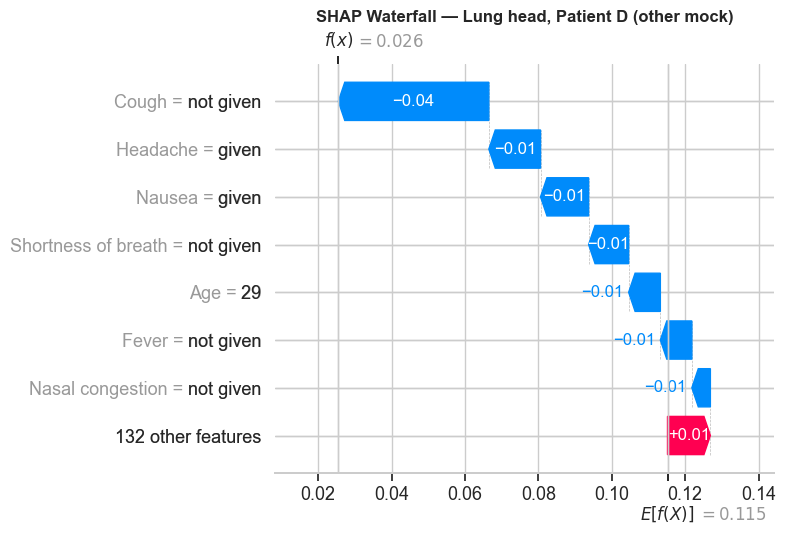



=== Triage for Patient E (impossible vital signs) ===
Age 35, Male | symptoms: Chest pain
🚨 STAGE 1 CASCADE REJECTION: vital signs outside the usual range.
Action: not routed. Check the values; if they are real, the patient needs urgent care, not an app.



In [51]:
# Test with mock patients
loaded_models = {organ: joblib.load(model_filenames[organ]) for organ in ORGANS}
loaded_gate = joblib.load(gate_filename)
print("[LOADED] Successfully loaded the three heads and the gate\n")

no_vitals = {c: np.nan for c in VITAL_SIGNS}
mock_visits = pd.DataFrame([
    # A: 64-year-old man with chest pain, breathlessness and sweating, measured at a pharmacy
    {'age': 64, 'sex': 'Male', 'symptom_1': 'Chest pain', 'symptom_2': 'Shortness of breath', 'symptom_3': 'Excessive sweating',
     'injury_reason': 'No', 'diabetes': 'Yes', 'temperature_f': 98.4, 'heart_rate': 104, 'respiratory_rate': 22,
     'systolic_bp': 158, 'diastolic_bp': 92, 'oxygen_saturation': 95, 'pain_score': 8},
    # B: 71-year-old woman with cough, fever and breathlessness, no measurements
    {'age': 71, 'sex': 'Female', 'symptom_1': 'Cough', 'symptom_2': 'Fever', 'symptom_3': 'Shortness of breath',
     'injury_reason': 'No', 'diabetes': 'No', **no_vitals},
    # C: 45-year-old man with flank pain, blood in the urine and vomiting, no measurements
    {'age': 45, 'sex': 'Male', 'symptom_1': 'Flank (side) or kidney pain', 'symptom_2': 'Blood in urine', 'symptom_3': 'Vomiting',
     'injury_reason': 'No', 'diabetes': 'No', **no_vitals},
    # D: 29-year-old woman with a headache and nausea, no measurements
    {'age': 29, 'sex': 'Female', 'symptom_1': 'Headache', 'symptom_2': 'Nausea', 'symptom_3': np.nan,
     'injury_reason': 'No', 'diabetes': 'No', **no_vitals},
    # E: impossible readings (typing errors) to trigger the Stage 1 gate
    {'age': 35, 'sex': 'Male', 'symptom_1': 'Chest pain', 'symptom_2': np.nan, 'symptom_3': np.nan,
     'injury_reason': 'No', 'diabetes': 'No', 'temperature_f': 115.0, 'heart_rate': 280, 'respiratory_rate': 90,
     'systolic_bp': 300, 'diastolic_bp': 20, 'oxygen_saturation': 40, 'pain_score': 10},
])[RAW_INPUT_COLUMNS]

print("=== Loaded Joblib Model Test ===")
triage_evaluation(mock_visits, models=loaded_models, gate=loaded_gate,
                  visit_names=["Patient A (heart-like mock)", "Patient B (lung-like mock)", "Patient C (kidney-like mock)",
                               "Patient D (other mock)", "Patient E (impossible vital signs)"])

# Conclusion
This notebook built the first layer of the disease-risk system: a router that hears a patient's age, sex and one to three symptoms (plus vital signs, if known) and decides which organ modules should look at them next. It was trained on **184,629 real emergency-department visits** from thirteen CDC NHAMCS surveys, with the emergency physician's diagnoses as labels.

**Key Achievements & Methodologies:**
* **A large, patient-level dataset, built reproducibly:** thirteen survey years in one script. Patients' reasons for visiting are grouped into 128 plain-language symptoms, and diagnoses are mapped to heart, lung and kidney groups with equivalent ICD-9 and ICD-10 ranges. The label audit shows each group is what the next layer expects: heart failure, arrhythmia and coronary disease; pneumonia, bronchitis, asthma, COPD and COVID-19; kidney stones, infections and kidney failure.
* **Three heads, one routing rule:** each organ has its own tuned, calibrated model and cost-optimal threshold, and a patient is routed to every organ they reach. Multi-organ patients (6.8 % of the organ visits) are handled naturally.
* **Built for patients without measurements:** vital-sign dropout (half the training visits without vital signs) keeps every head calibrated with or without vital signs. The alternative, a model trained on complete records, underestimates patients without them by 10–24 %.
* **9 classifiers per head, honest selection:** gradient-boosted trees lead every head, within about 0.01 of each other. The one-SE rule picked **CatBoost** for the heart, the **Explainable Boosting Machine** for the lungs and **LightGBM** for the kidneys.
* **Performance (test set, with / without vital signs):**

  | Head | ROC-AUC | PR-AUC | Recall at threshold | Precision at threshold |
  |---|---|---|---|---|
  | Heart | 0.896 / 0.889 | 0.352 / 0.314 | 55.3 % / 54.0 % | 29.9 % / 29.0 % |
  | Lung | 0.890 / 0.883 | 0.588 / 0.549 | 73.1 % / 71.5 % | 47.0 % / 46.1 % |
  | Kidney | 0.856 / 0.843 | 0.296 / 0.278 | 32.0 % / 29.3 % | 33.6 % / 36.0 % |

  For comparison, chance PR-AUC is 0.043, 0.092 and 0.039.
* **The router as a whole:** 22 % of visits are sent to at least one organ module (0.26 modules per visit). 61.7 % of the visits with an organ diagnosis reach at least one of their organs, and 86.8 % of the other visits are left alone.
* **Explainability:** SHAP and permutation importance agree that the first symptom drives every head (shuffling it costs 0.17–0.32 PR-AUC), with age for the heart and oxygen saturation for the lungs. Every routing decision comes with the inputs that pushed each organ, in clinical units.
* **Two-stage cascade:** a 1 % Isolation Forest gate on the vital signs, then the three calibrated heads. The heads, the gate, `metadata.json` and `reference_profile.json` are saved to `models/`, reload cleanly, and serve `src.predict` and `common.registry.route()`.

**Limitations:**
* **Kidney disease without kidney complaints is invisible to a symptom router.** Stones and renal colic are routed 58 % of the time, but acute kidney failure only 6 % and chronic kidney disease or dialysis only 10 %. Those patients need the CKD risk model on laboratory values, not a symptom checker.
* **The labels are emergency diagnoses of emergency patients.** Probabilities are those of people ill enough to come to an ED, and chest pain with no cause found counts as "not heart". People with mild symptoms at home are not in the data, so the router has not been validated on them.
* **The gate withholds sick patients more often:** 4.5 % of heart visits and 3.8 % of lung visits, against 0.6 % of other visits. For a symptom app that is acceptable only because the withheld message sends the patient to urgent care.
* **Different patients from the next layer:** the organ models learn from NHANES participants and image datasets, so the accuracy of the full chain cannot be measured end to end.

**Future Work / Next Steps:**
* **Wire the router into the cascade and the front end** through `common.registry.route()`: ask for the three symptoms, then open the routed organs' input forms (and image upload).
* **Tune the cost ratio for the product.** At 20:1 instead of 5:1, recall rises to about 81 % heart, 85 % lung and 73 % kidney, at the price of routing about a fifth of the other visits to each module.
* **Route on risk factors as well as symptoms** (age, diabetes, blood pressure), so silent kidney and heart disease also reach the organ risk models; and validate on a second source (MIMIC-IV-ED) before trusting the thresholds elsewhere.